# Transcription Factor Project - KOLF2.1J Dataset Figures
**Robin Anwyl, UCSD Subramaniam Lab**

**Goal:** Analyze the KOLF2.1J Perturb-seq dataset from the Nourreddine et al. (2024) preprint to investigate the effects of transcription factor knockdowns (TF KDs)

**Guiding Questions:** What do TF KD effects reveal about:
* the transcriptional regulatory network of hiPSCs? 
* TF crosstalk and co-regulation?
* cell lineage?
* how TFs influence chromatin remodeling?

# Import statements

Using psp_env virtual env

In [2]:
import sys
import os
psp_root = "/home/ranwyl/KOLF2.1J_Perturbation_Cell_Atlas/"
if psp_root not in sys.path:
    sys.path.insert(0, psp_root)

import psp

In [3]:
import anndata as ad
import numpy as np
import pandas as pd
import decoupler as dc
import gseapy as gp
from tqdm_joblib import tqdm_joblib
from joblib import Parallel, delayed
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from matplotlib.patches import Patch
import seaborn as sns
from PyComplexHeatmap import ClusterMapPlotter, HeatmapAnnotation, anno_simple
sns.set_style("white")
from biothings_client import get_client
import warnings
from contextlib import contextmanager

In [4]:
def validate_3_DGE_results_dfs(DGE_results_dfs: list[pd.DataFrame]
                               ) -> list[pd.DataFrame]:
    """
    Check that 3 DGE analysis results DFs have same rows and cols.
    """
    if not len(DGE_results_dfs) == 3:
        raise ValueError("Input must be list of 3 DataFrames")
    DGE_results_1 = DGE_results_dfs[0].sort_index()
    DGE_results_2 = DGE_results_dfs[1].sort_index()
    DGE_results_3 = DGE_results_dfs[2].sort_index()
    if not (DGE_results_1.index.equals(DGE_results_2.index) and 
            DGE_results_2.index.equals(DGE_results_3.index)):
        raise ValueError("DGE results DataFrames must have same index (genes)")
    if not ((set(DGE_results_1.columns) == set(DGE_results_2.columns)) &
            (set(DGE_results_2.columns) == set(DGE_results_3.columns))):
        raise ValueError("DGE results DataFrames must have same columns (KDs)")
    # Return DFs with sorted index
    return [DGE_results_1, DGE_results_2, DGE_results_3]

def build_3_run_DEGs_dict(
        DGE_results_dfs: list[pd.DataFrame],
        p_threshold: float,
        p_threshold_type: str="pvalue",
        report_direction: bool=False,
        remove_self_DEGs: bool=False,
        target_type: str="gRNA",
        lfc_threshold: float = 0,
        lfc_col: str = "log2FoldChange",
        validate: bool=True
        ) -> dict[str, set[str]] | dict[str, dict[str, set[str]]]:
    """
    For each KD, find genes that are DEGs of that KD (pass significance and 
    LFC thresholds) with the same LFC sign in at least 2 DGE analysis runs.
    If direction = True, return dict {'KD': {'UP': up_DEGs, 'DOWN': down_DEGs}}.
    If direction = False, return dict {'KD': all_DEGs}
    """
    # Check for valid significance threshold
    if p_threshold_type not in ("pvalue", "padj"):
        raise ValueError("p_threshold_type must be 'pvalue' or 'padj'")
    # Check for valid target type
    if target_type not in ("gRNA", "gene_target"):
        raise ValueError("target_type must be 'gRNA' or 'gene_target'")
    # Check that 3 DGE analysis results DFs have same rows and cols
    if validate:
        DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)
    
    # Find genes that are DEGs of the same KD in at least 2 DGE runs
    DGE_results_1, DGE_results_2, DGE_results_3 = \
        DGE_results_dfs[0], DGE_results_dfs[1], DGE_results_dfs[2]
    if target_type == "gRNA":
        targets = {"_".join(col.split("_")[:2]) for col in DGE_results_1.columns}
    else:
        targets = {col.split("_")[0] for col in DGE_results_1.columns}
    targets = sorted(list(targets))
    DEGs_dict = dict()
    for target in targets:
        target_p_col = f"{target}_{p_threshold_type}"
        target_lfc_col = f"{target}_{lfc_col}"
        DEGs_run1_up = set(
            DGE_results_1.loc[(DGE_results_1[target_p_col] < p_threshold) & 
            (DGE_results_1[target_lfc_col] > lfc_threshold)].index)
        DEGs_run1_down = set(
            DGE_results_1.loc[(DGE_results_1[target_p_col] < p_threshold) & 
            (DGE_results_1[target_lfc_col] < (-1*lfc_threshold))].index)
        DEGs_run2_up = set(
            DGE_results_2.loc[(DGE_results_2[target_p_col] < p_threshold) & 
            (DGE_results_2[target_lfc_col] > lfc_threshold)].index)
        DEGs_run2_down = set(
            DGE_results_2.loc[(DGE_results_2[target_p_col] < p_threshold) & 
            (DGE_results_2[target_lfc_col] < (-1*lfc_threshold))].index)
        DEGs_run3_up = set(
            DGE_results_3.loc[(DGE_results_3[target_p_col] < p_threshold) & 
            (DGE_results_3[target_lfc_col] > lfc_threshold)].index)
        DEGs_run3_down = set(
            DGE_results_3.loc[(DGE_results_3[target_p_col] < p_threshold) & 
            (DGE_results_3[target_lfc_col] < (-1*lfc_threshold))].index)
        DEGs_up = ((DEGs_run1_up & DEGs_run2_up) | (DEGs_run2_up & DEGs_run3_up) |
                   (DEGs_run1_up & DEGs_run3_up))
        DEGs_down = ((DEGs_run1_down & DEGs_run2_down) | 
                     (DEGs_run2_down & DEGs_run3_down) |
                     (DEGs_run1_down & DEGs_run3_down))
        # Remove gene target from DEG list
        if remove_self_DEGs:
            self_gene = target if target_type == "gene_target" else target.split("_")[0]
            DEGs_up = DEGs_up - {self_gene}
            DEGs_down = DEGs_down - {self_gene}
        DEGs_dict[target] = {"UP": DEGs_up, "DOWN": DEGs_down} if report_direction \
            else (DEGs_up | DEGs_down)
    return DEGs_dict

def build_3_run_n_DEGs_df(
        DEGs_dict: dict[str, set[str]] | dict[str, dict[str, set[str]]]
        ) -> pd.DataFrame:
    """
    From a dict of DEGs for each KD, build a DataFrame reporting
    the number of DEGs per KD.
    """
    kds = list(DEGs_dict.keys())
    if isinstance(next(iter(DEGs_dict.values())), dict):
        n_DEGs = [len(degs["UP"] | degs["DOWN"]) for degs in DEGs_dict.values()]
    else:
        n_DEGs = [len(DEGs_dict[kd]) for kd in kds]
    n_DEGs_df = pd.DataFrame(n_DEGs, index=kds, columns=["n_DEGs"])
    n_DEGs_df = n_DEGs_df.sort_values(by="n_DEGs", ascending=False)
    return n_DEGs_df

def build_3_run_DEGs_df(
        DEGs_dict: dict[str, set[str]] | dict[str, dict[str, set[str]]],
        kd_col: str="KD") -> pd.DataFrame:
    """
    From a dict of DEGs for each KD, build a DataFrame of each KD,
    DEG count, and DEGs.
    """
    kds = list(DEGs_dict.keys())
    if isinstance(next(iter(DEGs_dict.values())), dict):
        up_DEGs = [", ".join(degs["UP"]) for degs in DEGs_dict.values()]
        n_up_DEGs = np.array([len(degs["UP"]) for degs in DEGs_dict.values()])
        down_DEGs = [", ".join(degs["DOWN"]) for degs in DEGs_dict.values()]
        n_down_DEGs = np.array([len(degs["DOWN"]) for degs in DEGs_dict.values()])
        n_total_DEGs = n_up_DEGs + n_down_DEGs
        DEGs_df = pd.DataFrame({kd_col: kds,
                                "n_total_DEGs": n_total_DEGs,
                                "n_up_DEGs": n_up_DEGs,
                                "n_down_DEGs": n_down_DEGs,
                                "up_DEGs": up_DEGs,
                                "down_DEGs": down_DEGs})
        DEGs_df = DEGs_df.sort_values(by="n_total_DEGs", ascending=False)
    else:
        n_DEGs = [len(DEGs_dict[kd]) for kd in kds]
        DEGs = [", ".join(DEGs_dict[kd]) for kd in kds]
        DEGs_df = pd.DataFrame({kd_col: kds, "n_DEGs": n_DEGs, "DEGs": DEGs})
        DEGs_df = DEGs_df.sort_values(by="n_DEGs", ascending=False)
    DEGs_df = DEGs_df.reset_index(drop=True)
    return DEGs_df

def build_3_run_wald_dict(DGE_results_dfs: list[pd.DataFrame],
                          wald_col: str="stat",
                          wald_abs_threshold: float = 1,
                          validate: bool = True,
                          kds: list[str] | set[str] | None = None,
                          remove_target_gene: bool=True,
                          ) -> dict[str, set[str]]:
    """
    For each KD, find genes that have |Wald| > wald_abs_threshold 
    in at least 2 DGE analysis runs.
    """
    # Check that 3 DGE analysis results DFs have same rows and cols
    if validate:
        DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)

    # For each KD, find genes with |Wald| > 1 in at least 2 runs
    DGE_results_1, DGE_results_2, DGE_results_3 = \
        DGE_results_dfs[0], DGE_results_dfs[1], DGE_results_dfs[2]
    if kds is None:
        kds = {col.split("_")[0] for col in DGE_results_1.columns}
    kds = sorted(list(kds))
    wald_dict = dict()
    for kd in kds:
        kd_wald_col = f"{kd}_{wald_col}"
        wald_genes_run1 = set(DGE_results_1.loc[
            abs(DGE_results_1[kd_wald_col]) > wald_abs_threshold].index)
        wald_genes_run2 = set(DGE_results_2.loc[
            abs(DGE_results_2[kd_wald_col]) > wald_abs_threshold].index)
        wald_genes_run3 = set(DGE_results_3.loc[
            abs(DGE_results_3[kd_wald_col]) > wald_abs_threshold].index)                                
        wald_genes_at_least_2 = ((wald_genes_run1 & wald_genes_run2) | 
                                 (wald_genes_run2 & wald_genes_run3) |
                                 (wald_genes_run1 & wald_genes_run3))
        # Remove target gene from gene list
        if remove_target_gene:
            wald_genes_at_least_2 = wald_genes_at_least_2 - {kd}
        wald_dict[kd] = wald_genes_at_least_2
    return wald_dict

def build_cluster_DEGs_dict(DEGs_dict: dict[str, set[str]],
                            cluster_df: pd.DataFrame
                            ) -> dict[int, set[str]]:
    """
    Build dict of DEGs per cluster.
    """
    cluster_kd_dict = {
        int(cl): list(cluster_df[cl][cluster_df[cl].notna()])
        for cl in cluster_df.columns
    }
    cluster_DEGs_dict = {
        cl: set().union(*[DEGs_dict[kd] for kd in cluster_kd_dict[cl]])
        for cl in cluster_kd_dict
    }
    return cluster_DEGs_dict

def plot_n_DEGs_per_cluster(cluster_DEGs_dict: dict[int, set[str]],
                            title: str, 
                            figsize: tuple[int, int] = (6,3), 
                            xlabel: str="Cluster", 
                            xtick_rotation: int=90,
                            ymax: int | None = None,
                            color: str = "tab:blue"):
    """
    Given a dict of DEGs per cluster, plot number of DEGs per cluster.
    """
    clusters = [f"CL{str(cl)}" for cl in cluster_DEGs_dict.keys()]
    n_DEGs = [len(cluster_DEGs_dict[cl]) for cl in cluster_DEGs_dict.keys()]
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=clusters, y=n_DEGs, ax=ax, color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("# DEGs per cluster")
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=2, fontsize=10, rotation=90)
    plt.xticks(fontsize=11, rotation=xtick_rotation)
    plt.yticks(fontsize=11)
    ax.yaxis.set_major_formatter('{x:.0f}')
    if ymax:
        ax.set_ylim(0, ymax)
    ax.set_title(title)

def build_strong_kds_per_cluster_df(DEGs_dict: dict[str, set[str]],
                                    cluster_df: pd.DataFrame,
                                    DEG_threshold_inclusive: int=10,
                                    kd_label: str="KD"):
    kds = list(DEGs_dict.keys())
    n_DEGs = [len(DEGs_dict[kd]) for kd in kds]
    n_DEGs_df = pd.DataFrame(n_DEGs, index=kds, columns=["n_DEGs"])
    n_DEGs_df = n_DEGs_df[n_DEGs_df["n_DEGs"] >= DEG_threshold_inclusive]
    cluster_kd_dict = {
        int(cl): list(cluster_df[cl][cluster_df[cl].notna()])
        for cl in cluster_df.columns
    }
    cluster_strong_kd_dict = {
        cl: [kd for kd in cluster_kd_dict[cl] if kd in n_DEGs_df.index]
        for cl in cluster_kd_dict
    }
    strong_kds_per_cluster_df = \
        pd.DataFrame({f"{kd_label}s w/ ≥{DEG_threshold_inclusive} DEGs per cluster": 
                      [len(cluster_strong_kd_dict[cl]) 
                       for cl in cluster_strong_kd_dict]},
                       index=[cl for cl in cluster_kd_dict])
    return strong_kds_per_cluster_df

def plot_n_kds_per_cluster(
        cluster_df: pd.DataFrame, 
        title: str,
        kd_label: str="KD",
        figsize: tuple[int, int] = (6,3), 
        xlabel: str="Cluster", 
        xtick_rotation: int=90,
        ymax: int | None = None,
        color: str = "tab:blue"):
    """
    Plot number of perturbations per cluster.
    """
    sns.set_style("whitegrid")
    n_kds_per_cluster = cluster_df.count()
    xvals = [f"CL{str(i)}" for i in range(len(n_kds_per_cluster))]
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(x=xvals, y=n_kds_per_cluster, ax=ax,
                color=color)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(f"# {kd_label}s in cluster")
    plt.xticks(fontsize=11, rotation=xtick_rotation)
    plt.yticks(fontsize=11)
    ax.yaxis.set_major_formatter('{x:.0f}')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=2, fontsize=10)
    if ymax:
        ax.set_ylim(0, ymax)
    ax.set_title(title)

# Read in data

In [5]:
filepath = "/home/ranwyl/data_tf_project/KOLF_Pan_Genome_Alpha_CPMnorm_KD_ETest_Gene_gRNA_Filtered.h5ad"
adata = psp.utils.read_anndata(filepath)
adata

AnnData object with n_obs × n_vars = 60132 × 16115
    obs: 'gRNA', 'n_gRNA', 'n_gRNA_UMIs', 'gene_target', 'celltype', 'perturbation_type', 'n_UMI_counts', 'n_genes', 'perturbed', 'channel', 'perturbation', 'gene_target_ensembl_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'gene_target_expression (CPM)', 'NTC_target_gene_expression (CPM)', 'target_knockdown', 'perturbation_edist', 'perturbation_pvalue', 'perturbation_significant'
    var: 'gene_ids', 'feature_types', 'n_UMI_counts', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'etest_results', 'etest_results_params'
    layers: 'counts'

In [6]:
filepath1 = "/home/ranwyl/results_tf_project/KOLF_DE_results_KD_shrunk_seed42_5-14-26_renamed.pkl"
de_results_kolf_1 = pd.read_pickle(filepath1)
filepath2 = "/home/ranwyl/results_tf_project/KOLF_DE_results_KD_shrunk_seed12_5-14-26_renamed.pkl"
de_results_kolf_2 = pd.read_pickle(filepath2)
filepath3 = "/home/ranwyl/results_tf_project/KOLF_DE_results_KD_shrunk_seed123_5-14-26_renamed.pkl"
de_results_kolf_3 = pd.read_pickle(filepath3)
de_results_kolf = [de_results_kolf_1, de_results_kolf_2, de_results_kolf_3]

In [7]:
kd_deg_dict_kolf = build_3_run_DEGs_dict(de_results_kolf, p_threshold=0.02,
                                    p_threshold_type="pvalue", target_type="gene_target",
                                    remove_self_DEGs=True)
n_degs_df_kolf = build_3_run_n_DEGs_df(kd_deg_dict_kolf)
n_degs_df_kolf.head(20)

,n_DEGs
POU5F1,417
DNMT1,121
ZNF521,81
THAP12,42
ZNF396,41
NANOG,40
ADNP2,30
PHF20,29
CHAMP1,23
POU5F1B,23


In [81]:
kd_deg_dict_kolf_self_degs = build_3_run_DEGs_dict(de_results_kolf, p_threshold=0.02,
                                    p_threshold_type="pvalue", target_type="gene_target",
                                    remove_self_DEGs=False)
kd_deg_dict_kolf_self_degs_direction = build_3_run_DEGs_dict(de_results_kolf, p_threshold=0.02,
                                    p_threshold_type="pvalue", target_type="gene_target",
                                    remove_self_DEGs=False, report_direction=True)

In [ ]:
kd_wald_dict_kolf = build_3_run_wald_dict(de_results_kolf, remove_target_gene=True)

In [82]:
leiden_filepath = \
    "/home/ranwyl/output_files_tf_project/KOLF_leiden_clusters_spectral25-mde7-knn6-repulsive5_6-2-26.csv"
leiden_clusters_kolf = pd.read_csv(leiden_filepath, header=0, index_col=0)
leiden_clusters_kolf.head()
tf_kd_to_leiden_cluster_kolf = {kd: int(cl) for cl in leiden_clusters_kolf.columns for kd in 
                                set(leiden_clusters_kolf[cl][leiden_clusters_kolf[cl].notna()])}

In [83]:
hdbscan_clusters_filepath = \
    "/home/ranwyl/output_files_tf_project/KOLF_hdbscan_clusters_6-2-26.csv"
hdbscan_clusters_kolf = pd.read_csv(hdbscan_clusters_filepath, header=0, index_col=0)
hdbscan_clusters_kolf
tf_kd_to_hdbscan_cluster_kolf = {kd: int(cl) for cl in hdbscan_clusters_kolf.columns for kd in 
                                set(hdbscan_clusters_kolf[cl][hdbscan_clusters_kolf[cl].notna()])}
non_hdbscan_tf_kds = set(tf_kd_to_leiden_cluster_kolf.keys()) - set(tf_kd_to_hdbscan_cluster_kolf.keys())
tf_kd_to_hdbscan_cluster_kolf.update({kd: -1 for kd in non_hdbscan_tf_kds})

In [ ]:
print(f"KOLF2.1J top 20 TF KDs with highest DEG count: {', '.join(n_degs_df_kolf.index[:20])}")

KOLF2.1J top 20 TF KDs with highest DEG count: POU5F1, DNMT1, ZNF521, THAP12, ZNF396, NANOG, ADNP2, PHF20, CHAMP1, POU5F1B, SETDB1, FOXH1, POU3F2, FOXD3, ZNF787, ZNF462, REST, PITX3, TCF7L1, HMX3


# Functions + references for GSEA, decoupler ULM TF + pathway activity inference, DEG heatmaps

In [84]:
@contextmanager
def handle_warnings(suppress):
    if suppress:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            yield
    else:
        yield

def prerank_gsea_all_kds(
        cluster_df: pd.DataFrame,
        DGE_results_dfs: list[pd.DataFrame],
        gene_set_name: str,
        cell_line: str,
        add_jitter: bool=True,
        wald_label: str="stat",
        min_term_size: int=15, 
        max_term_size: int=200,
        permutation_num: int=1000,
        n_cpus_per_job: int=4,
        n_jobs: int=8,
        random_seed: int=42,
        verbose: bool=False,
        kd_col: str="KD",
        cluster_col: str="Cluster",
        gene_set_col: str="Gene set",
        cell_line_col: str="Cell line",
        suppress_warnings: bool=False
        ) -> pd.DataFrame:
    """
    Run pre-ranked GSEA, using the given Enrichr library, on each 
    individual KD in a dataset. For each KD, compute mean Wald test
    statistic of each gene across 3 DGE analysis runs and rank genes by
    mean Wald. min_size controls minimum number of genes in the intersection
    of the dataset and each gene set term. max_size controls maximum number of
    genes in each gene set term.
    """
    # Get KDs
    kds = cluster_df.values.flatten().tolist()
    kds = [kd for kd in kds if isinstance(kd, str)] # Remove NaN column padding
    kd_to_cluster = {kd: int(col) for col in cluster_df.columns 
                     for kd in cluster_df[col].dropna()}
    # Check for duplicates
    assert len(kd_to_cluster) == len(kds), (
        f"{len(kds) - len(kd_to_cluster)} KD(s) appear in multiple clusters")

    # Get Enrichr library
    gene_set = gp.get_library(gene_set_name, organism="Human",
                              min_size=min_term_size, max_size=max_term_size)
    
    # Check that 3 DGE analysis results DFs have same rows and cols
    DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)
    # Subset DGE results to Wald columns only
    wald_cols = [col for col in DGE_results_dfs[0].columns if col.endswith(f"_{wald_label}")]
    DGE_results_dfs = [df[wald_cols] for df in DGE_results_dfs]
    
    # Helper function to run GSEA on single KD
    def process_kd(kd):
        # Compute mean Wald per gene
        wald_col = f"{kd}_{wald_label}"
        wald_df_1 = pd.DataFrame(DGE_results_dfs[0][wald_col].values,
                                 index=DGE_results_dfs[0].index, 
                                 columns=[wald_label])
        wald_df_2 = pd.DataFrame(DGE_results_dfs[1][wald_col].values,
                                 index=DGE_results_dfs[1].index, 
                                 columns=[wald_label])
        wald_df_3 = pd.DataFrame(DGE_results_dfs[2][wald_col].values,
                                 index=DGE_results_dfs[2].index, 
                                 columns=[wald_label])
        wald_df = (wald_df_1 + wald_df_2 + wald_df_3) / 3
        # Drop NaN genes and gene that was KD
        if kd in wald_df.index:
            wald_df.loc[kd] = np.nan
        wald_df.dropna(axis="index", inplace=True)
        # Sort and format Wald DF
        wald_df.sort_values(by=wald_label, ascending=False, inplace=True)
        wald_df.index.name = "gene"
        # Add negligible jitter to break ties
        if add_jitter:
            jitter = 1e-9 * np.arange(len(wald_df))
            wald_df[wald_label] = wald_df[wald_label].values - jitter

        # Run pre-ranked GSEA
        kd_gsea_result = \
            gp.prerank(rnk=wald_df,
                        gene_sets=gene_set,
                        threads=n_cpus_per_job,
                        min_size=min_term_size,
                        max_size=max_term_size,
                        permutation_num=permutation_num,
                        outdir=None,
                        seed=random_seed,
                        verbose=verbose,
                        )
        return kd_gsea_result
    
    # Run pre-ranked GSEA on all KDs
    with handle_warnings(suppress_warnings):
        with tqdm_joblib(desc="Running pre-ranked GSEA", 
                                total=len(kds)):
            kd_gsea_results = Parallel(n_jobs=n_jobs)(
                delayed(process_kd)(kd) for kd in kds)
    kd_gsea_results_dict = dict(zip(kds, kd_gsea_results))

    # Build results DF
    gsea_results_list = list()
    for kd in kd_gsea_results_dict: # Build results DF for KD
        kd_res_df = kd_gsea_results_dict[kd].res2d.copy()
        kd_res_df.insert(0, kd_col, [kd]*kd_res_df.shape[0]) # KD column
        kd_res_df.drop(columns=["Name"], inplace=True)
        gsea_results_list.append(kd_res_df)
    gsea_results_df = pd.concat(gsea_results_list)
    # Add gene set, cluster, and cell line info
    gsea_results_df.insert(1, gene_set_col, [gene_set_name]*len(gsea_results_df))
    gsea_results_df.insert(0, cluster_col, gsea_results_df[kd_col].map(kd_to_cluster))
    gsea_results_df.insert(0, cell_line_col, [cell_line]*len(gsea_results_df))

    # Check that all KDs are in DF
    gsea_kds = set(gsea_results_df[kd_col])
    missing_kds = set(kds) - gsea_kds
    if missing_kds:
        print(f"Warning: {len(missing_kds)} KDs missing from GSEA results ({', '.join(missing_kds)})")
    
    return gsea_results_df

In [85]:
def build_enriched_gsea_terms_df(
        gsea_results_df: pd.DataFrame,
        DGE_results_dfs: list[pd.DataFrame],
        fdr_threshold: float=0.05,
        fdr_col: str="FDR q-val",
        min_absolute_nes: None | float = None, 
        nes_col: str="NES",
        DGE_p_threshold: float = 0.05,
        DGE_p_threshold_type: str="pvalue",
        wald_label: str = "stat",
        wald_abs_threshold: int=1,
        leading_genes_col: str="Lead_genes",
        genes_sep_char: str=";",
        kd_DEG_dict: dict[str, set[str]] | None = None,
        kd_wald_dict: dict[str, set[str]] | None = None,
        cluster_col: str="Cluster",
        kd_col: str="KD",
    ) -> pd.DataFrame:
    """
    Subset the GSEA results DF to only enriched terms
    and add info on leading genes that are DEGs and
    that have |Wald| > 1 in at least 2 DGE analysis runs.
    """
    # Check that 3 DGE analysis results DFs have same rows and cols
    DGE_results_dfs = validate_3_DGE_results_dfs(DGE_results_dfs)

    # Subset to enriched terms (by FDR and NES)
    gsea_results_df = \
        gsea_results_df[gsea_results_df[fdr_col] < fdr_threshold]
    if min_absolute_nes:
        gsea_results_df = \
            gsea_results_df[gsea_results_df[nes_col] >= min_absolute_nes]
    enriched_results_df = gsea_results_df.copy()
    
    # Add info on leading genes that pass DE significance threshold
    #   and have |Wald| > threshold in at least 2 DGE runs
    # Build dict {KD: {DEGs}}
    kds = set(gsea_results_df[kd_col].values)
    if not kd_DEG_dict:
        kd_DEG_dict = build_3_run_DEGs_dict(DGE_results_dfs, 
                                            p_threshold=DGE_p_threshold,
                                            p_threshold_type=DGE_p_threshold_type,
                                            validate=False)
    kd_DEG_dict = {k:v for k,v in kd_DEG_dict.items() if k in kds}
    # Build dict {KD: {genes with |Wald| > threshold}}
    if not kd_wald_dict:
        kd_wald_dict = build_3_run_wald_dict(DGE_results_dfs, 
                                            wald_col=wald_label,
                                            wald_abs_threshold=wald_abs_threshold,
                                            validate=False)
    kd_wald_dict = {k:v for k,v in kd_wald_dict.items() if k in kds}
    
    # Get leading gene DE + Wald info
    kds_arr = enriched_results_df[kd_col].to_numpy()
    lead_genes_arr = enriched_results_df[leading_genes_col].to_numpy()
    n_de_leading, de_leading_str, n_wald_leading, wald_leading_str = [], [], [], []
    for kd, lead_genes in zip(kds_arr, lead_genes_arr):
        leading_genes = set(s for s in lead_genes.split(genes_sep_char) if s)
        de_leading = leading_genes & kd_DEG_dict.get(kd, set())
        wald_leading = leading_genes & kd_wald_dict.get(kd, set())
        n_de_leading.append(len(de_leading))
        de_leading_str.append(genes_sep_char.join(sorted(de_leading)))
        n_wald_leading.append(len(wald_leading))
        wald_leading_str.append(genes_sep_char.join(sorted(wald_leading)))
    
    # Add leading gene DE + Wald info to DF
    enriched_results_df.insert(10, "# DE lead genes", n_de_leading)
    enriched_results_df.insert(11, f"# lead genes w/ |Wald| > {wald_abs_threshold}", 
                               n_wald_leading)
    enriched_results_df["DE_lead_genes"] = de_leading_str
    enriched_results_df["Wald_lead_genes"] = wald_leading_str
    
    # Sort DF
    enriched_results_df.sort_values(by=[cluster_col, kd_col, nes_col],
                                    ascending=[True, True, False],
                                    inplace=True, ignore_index=True)
    
    return enriched_results_df

def build_shared_gsea_terms_df(
        enriched_results_df: pd.DataFrame,
        n_kds: int,
        kd_col: str="KD",
        nes_col: str="NES",
        gene_set_col: str="Gene set",
        cell_line_col: str="Cell line",
        tag_percent_col: str="Tag %",
        ) -> pd.DataFrame:
    """
    Count how many KDs are enriched for the same term with the same direction
    of enrichment.
    """
    if enriched_results_df[cell_line_col].nunique() != 1:
        raise ValueError("Results must be restricted to one cell line")
    summary_entries = list()
    gene_sets = set(enriched_results_df[gene_set_col])
    for gene_set in gene_sets:
        gene_set_results_df = enriched_results_df[
        enriched_results_df[gene_set_col] == gene_set]
        term_groups = dict(list(gene_set_results_df.groupby("Term", sort=False)))
        for term in term_groups:
            term_df = term_groups[term]
            term_size = term_df[tag_percent_col].values[0].split("/")[1]
            # Up terms
            term_df_up = term_df[(term_df["Term"] == term) &
                                  (term_df[nes_col] > 0)]
            if len(term_df_up) > 0:
                summary_entries.append({
                    gene_set_col: gene_set,
                    "Term": term,
                    "Term Size": term_size,
                    "Direction": "UP",
                    f"# {kd_col}s": term_df_up[kd_col].nunique(),
                    "Mean NES": term_df_up[nes_col].mean().round(3)
                })
            # Down terms
            term_df_down = term_df[(term_df["Term"] == term) &
                                    (term_df[nes_col] < 0)]
            if len(term_df_down) > 0:
                summary_entries.append({
                    gene_set_col: gene_set,
                    "Term": term,
                    "Term Size": term_size,
                    "Direction": "DOWN",
                    f"# {kd_col}s": term_df_down[kd_col].nunique(),
                    "Mean NES": term_df_down[nes_col].mean().round(3)
                })
    summary_df = pd.DataFrame(summary_entries)
    summary_df.insert(4, f"% {kd_col}s", 
        (100*summary_df[f"# {kd_col}s"]/n_kds).astype(int))
    # Rename gene sets
    gene_set_shortnames = {'MSigDB_Hallmark_2020': 'Hallmark',
                           'GO_Biological_Process_2025': 'GO:BP',
                           'Reactome_Pathways_2024': 'Reactome',
                           'KEGG_2026': 'KEGG',
                           'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X': 'ECC'}
    summary_df[gene_set_col] = summary_df[gene_set_col].map(gene_set_shortnames)
    summary_df.sort_values(by=f"# {kd_col}s", ascending=False, 
                           ignore_index=True, inplace=True)
    return summary_df

def build_cluster_shared_gsea_terms_df(
        enriched_results_df: pd.DataFrame,
        gene_set_name: str,
        cell_line: str,
        min_cluster_kds: int=3,
        min_term_size: int=15, 
        max_term_size: int=200,
        kd_col: str="KD",
        cluster_col: str="Cluster", 
        nes_col: str="NES",
        gene_set_col: str="Gene set",
        cell_line_col: str="Cell line",
        leading_genes_col: str="Lead_genes",
        DE_leading_genes_col: str="DE_lead_genes",
        wald_leading_genes_col: str="Wald_lead_genes",
        wald_abs_threshold: float = 1
        ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Given a pre-ranked GSEA results DF for a single gene set that contains 
    enriched terms and info on genes that pass DE and |Wald| thresholds, 
    find terms shared between multiple cluster KDs. Return 2 DFs: 
    shared_terms_df containing all shared enriched terms (multiple rows
    per term per cluster) and summary_df where each row summarizes one shared 
    enriched term (one row per term per cluster).
    """
    cluster_results_dfs, summary_entries = list(), list()
    # Get Enrichr library
    enrichr_library = gp.get_library(gene_set_name, organism="Human",
                                 min_size=min_term_size, max_size=max_term_size)
    # Loop through clusters
    clusters = sorted(enriched_results_df[cluster_col].unique().tolist(), key=int)
    for cl in clusters:
        # Get cluster DF
        cl_df = enriched_results_df[enriched_results_df[cluster_col] == cl]
        if cl_df.empty:
            continue
        # Group cluster DF by term for fast lookup
        term_groups = dict(list(cl_df.groupby("Term", sort=False)))
        # Subset to shared terms
        term_counts = cl_df["Term"].value_counts()
        cl_shared_terms = set(term_counts[term_counts >= min_cluster_kds].index)
        cl_shared_direction_terms = set()
        for term in cl_shared_terms:
            # Get only shared terms where all TF KDs have same NES sign
            cl_term_df = term_groups[term]
            nes_values = cl_term_df[nes_col].to_numpy()
            if not (np.all(nes_values > 0) or np.all(nes_values < 0)):
                continue
            cl_shared_direction_terms.add(term)
            # Build summary entry and add to list
            term_kds = sorted(cl_term_df[kd_col].unique().tolist())
            term_lead_genes = \
                {g for genes in cl_term_df[leading_genes_col].values 
                 for g in genes.split(";") if g}
            term_DE_lead_genes = \
                {g for genes in cl_term_df[DE_leading_genes_col].values 
                 for g in genes.split(";") if g}
            term_wald_lead_genes = \
                {g for genes in cl_term_df[wald_leading_genes_col].values 
                 for g in genes.split(";") if g}
            wald_lead_genes_col = f"Total leading genes w/ |Wald| > {wald_abs_threshold}"
            summary_entries.append(
                {cluster_col: cl, 
                 "Term": term, 
                 f"# {kd_col}s": len(term_kds),
                 f"{kd_col}s": ", ".join(term_kds),
                 "Mean NES": round(cl_term_df[nes_col].mean(), 2),
                 "Term size": len(enrichr_library[term]),
                 "Total leading genes": len(term_lead_genes),
                 "Total DE leading genes": len(term_DE_lead_genes),
                 wald_lead_genes_col: len(term_wald_lead_genes)}
                 )
        # Add cluster shared terms DF to list
        cl_df = cl_df[cl_df["Term"].isin(cl_shared_direction_terms)]
        cl_df.sort_values(by=["Term", kd_col], inplace=True)
        cluster_results_dfs.append(cl_df)
    
    # If no enriched terms
    if len(cluster_results_dfs) == 0:
        return pd.DataFrame(), pd.DataFrame()
    
    # Build shared terms DF
    if len(cluster_results_dfs) > 1:
        shared_terms_df = pd.concat(cluster_results_dfs)
        shared_terms_df.reset_index(drop=True, inplace=True)
    else:
        shared_terms_df = cluster_results_dfs[0]
    # Build summary DF
    summary_df = pd.DataFrame(summary_entries)
    summary_df.insert(0, cell_line_col, [cell_line]*len(summary_df))
    summary_df.insert(1, gene_set_col, [gene_set_name]*len(summary_df))
    summary_df.sort_values(by=[cluster_col, "Mean NES", f"# {kd_col}s"], 
                           ascending=[True, False, False],
                           inplace=True, ignore_index=True)

    return shared_terms_df, summary_df

def combine_gsea_dfs(gsea_dfs: list[pd.DataFrame],
                     cluster_col: str="Cluster",
                     kd_col: str="KD",
                     nes_col: str="NES") -> pd.DataFrame:
    """
    Concatenate and sort multiple GSEA results DFs where each row is a term.
    """
    gsea_df = pd.concat(gsea_dfs)
    gsea_df.sort_values(by=[cluster_col, kd_col, nes_col],
                        ascending=[True, True, False],
                        inplace=True, ignore_index=True)
    return gsea_df

def summarize_gsea_df(gsea_df: pd.DataFrame,
                    cluster_df: pd.DataFrame,
                    gene_set_col: str="Gene set",
                    kd_col: str="KD",
                    fdr_threshold: float=0.05,
                    fdr_col: str="FDR q-val",
                    cluster_col: str="Cluster"
                    ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Given a GSEA results DF where each row is a term, summarize the
    number of enriched terms and enriched KDs per gene set and per cluster.
    """
    gsea_df = gsea_df[gsea_df[fdr_col] < fdr_threshold]

    # Gene set info
    kds = cluster_df.values.flatten().tolist()
    kds = [kd for kd in kds if isinstance(kd, str)]
    total_n_kds = len(kds)
    gene_sets = sorted(gsea_df[gene_set_col].unique().tolist())
    gene_set_n_enriched_terms = list()
    gene_set_n_enriched_kds = list()
    for gene_set in gene_sets:
        df_subset = gsea_df[gsea_df[gene_set_col] == gene_set]
        gene_set_n_enriched_terms.append(len(df_subset))
        gene_set_n_enriched_kds.append(
            f"{df_subset[kd_col].nunique()}/{total_n_kds}")
    gene_set_summary_df = pd.DataFrame({
        "# enriched terms": gene_set_n_enriched_terms,
        f"# {kd_col}s with enriched term(s)": gene_set_n_enriched_kds
        }, index=gene_sets)
    gene_set_summary_df.index.name = gene_set_col
    gene_set_summary_df.sort_values(by="# enriched terms", 
                                    ascending=False, inplace=True)
    
    # Cluster info
    clusters_n_kds = {int(cl): len(cluster_df[cl][cluster_df[cl].notna()])
                      for cl in cluster_df.columns}
    clusters_n_kds = {cl: clusters_n_kds[cl] for cl in sorted(clusters_n_kds.keys())}
    cluster_n_enriched_terms = list()
    cluster_n_enriched_kds = list()
    for cl in clusters_n_kds.keys():
        cl_n_enriched_terms = 0
        cl_n_enriched_kds = 0
        if cl in gsea_df[cluster_col].values:
            df_subset = gsea_df[gsea_df[cluster_col] == cl]
            cl_n_enriched_terms = len(df_subset)
            cl_n_enriched_kds = df_subset[kd_col].nunique()
        cluster_n_enriched_terms.append(cl_n_enriched_terms)
        cluster_n_enriched_kds.append(
            f"{cl_n_enriched_kds}/{clusters_n_kds[cl]}")
    cluster_summary_df = pd.DataFrame({
        "# enriched terms": cluster_n_enriched_terms,
        f"# cluster {kd_col}s w/ enriched terms": cluster_n_enriched_kds
        }, index=list(clusters_n_kds.keys()))
    cluster_summary_df.sort_values(by="# enriched terms", ascending=False,
                                   inplace=True)
    cluster_summary_df.index.name = cluster_col
    return gene_set_summary_df, cluster_summary_df

def combine_gsea_shared_summary_dfs(gsea_shared_summary_dfs: list[pd.DataFrame],
                                    cluster_col: str="Cluster",
                                    kd_col: str="KD") -> pd.DataFrame:
    """
    Concatenate and sort multiple GSEA results DFs where each row corresponds
    to a term shared by multiple KDs in a cluster.
    """
    gsea_shared_df = pd.concat(gsea_shared_summary_dfs)
    gsea_shared_df.sort_values(by=[cluster_col, "Mean NES", f"# {kd_col}s"], 
                                ascending=[True, False, False],
                                inplace=True, ignore_index=True)
    return gsea_shared_df

def summarize_gsea_shared_df(gsea_shared_df: pd.DataFrame,
                            cluster_df: pd.DataFrame,
                            gene_set_col: str="Gene set",
                            kd_col: str="KD",
                            cluster_col: str="Cluster"
                            ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Given a GSEA results DF where each row corresponds to a term shared 
    by multiple KDs in a cluster, summarize the number of shared enriched terms 
    and KDs with shared enriched terms per gene set and per cluster.
    """
    # Gene set info
    kds = cluster_df.values.flatten().tolist()
    kds = [kd for kd in kds if isinstance(kd, str)]
    total_n_kds = len(kds)
    gene_sets = sorted(gsea_shared_df[gene_set_col].unique().tolist())
    gene_set_n_shared_terms = list()
    gene_set_n_shared_kds = list()
    for gene_set in gene_sets:
        df_subset = gsea_shared_df[gsea_shared_df[gene_set_col] == gene_set]
        gene_set_n_shared_terms.append(len(df_subset))
        gs_kd_vals = list(df_subset[f"{kd_col}s"].values)
        gs_n_shared_kds = len({kd for val in gs_kd_vals 
                               for kd in val.split(", ")})
        gene_set_n_shared_kds.append(f"{gs_n_shared_kds}/{total_n_kds}")
    gene_set_summary_df = pd.DataFrame({
        "# shared terms": gene_set_n_shared_terms,
        f"# {kd_col}s w/ shared terms": gene_set_n_shared_kds
        }, index=gene_sets)
    gene_set_summary_df.index.name = gene_set_col
    gene_set_summary_df.sort_values(by="# shared terms", 
                                    ascending=False, inplace=True)
    
    # Cluster info
    clusters_n_kds = {int(cl): len(cluster_df[cl][cluster_df[cl].notna()])
                      for cl in cluster_df.columns}
    clusters_n_kds = {cl: clusters_n_kds[cl] for cl in sorted(clusters_n_kds.keys())}
    cluster_n_shared_terms = list()
    cluster_n_shared_kds = list()
    for cl in clusters_n_kds.keys():
        cl_n_shared_terms = 0
        cl_n_shared_kds = 0
        if cl in gsea_shared_df[cluster_col].values:
            df_subset = gsea_shared_df[gsea_shared_df[cluster_col] == cl]
            cl_n_shared_terms = len(df_subset)
            cl_kd_vals = list(df_subset[f"{kd_col}s"].values)
            cl_n_shared_kds = len({kd for val in cl_kd_vals 
                                   for kd in val.split(", ")})
        cluster_n_shared_terms.append(cl_n_shared_terms)
        cluster_n_shared_kds.append(
            f"{cl_n_shared_kds}/{clusters_n_kds[cl]}")
    cluster_summary_df = pd.DataFrame({
        "# shared enriched terms": cluster_n_shared_terms,
        f"# cluster {kd_col}s w/ shared enriched terms": cluster_n_shared_kds
        }, index=list(clusters_n_kds.keys()))
    cluster_summary_df.sort_values(by="# shared enriched terms", ascending=False,
                                   inplace=True)
    cluster_summary_df.index.name = cluster_col
    return gene_set_summary_df, cluster_summary_df

def get_shared_term_leading_genes(
        gsea_results_df: pd.DataFrame,
        term: str,
        term_gene_set: str,
        gene_set_col: str="Gene set",
        leading_genes_col: str="Lead_genes",
        genes_sep_char: str=";",
        fdr_threshold: float=0.05,
        fdr_col: str="FDR q-val",
        min_absolute_nes: float | None = None,
        nes_col: str="NES"
        ) -> pd.DataFrame:
    """
    For a given GSEA term enriched in multiple conditions, 
    count the number of occurrences of each leading gene.
    """
    # Subset to term
    gsea_results_df = gsea_results_df[
        (gsea_results_df["Term"] == term) &
        (gsea_results_df[gene_set_col] == term_gene_set)]
    # Apply FDR and NES thresholds
    gsea_results_df = \
        gsea_results_df[gsea_results_df[fdr_col] < fdr_threshold]
    if min_absolute_nes:
        gsea_results_df = \
            gsea_results_df[gsea_results_df[nes_col] >= min_absolute_nes]

    # Get leading genes
    leading_genes_entries = list(gsea_results_df[leading_genes_col].values)
    leading_genes_nested = [entry.split(genes_sep_char) for entry in
                            leading_genes_entries]
    leading_genes_all = pd.Series([gene for entry_list in leading_genes_nested 
                        for gene in entry_list])
    leading_genes_counts = pd.DataFrame(leading_genes_all.value_counts())
    leading_genes_counts.index.name = "Leading gene"
    return leading_genes_counts

def get_kd_term_leading_genes(
        gsea_results_df: pd.DataFrame,
        kd: str,
        term: str,
        gene_set: str,
        kd_col: str="KD",
        gene_set_col: str="Gene set",
        leading_genes_col: str="Lead_genes",
        genes_sep_char: str=";",
    ) -> set:
    """
    Get the leading genes for a given term, gene set, and KD.
    """
    term_df = gsea_results_df[
        (gsea_results_df[kd_col] == kd) &
        (gsea_results_df["Term"] == term) & 
        (gsea_results_df[gene_set_col] == gene_set)]
    if term_df.empty:
        print("Term not found")
        return set()
    if len(term_df) != 1:
        print("Multiple terms found, processing first entry") 
    lead_genes_str = term_df[leading_genes_col].values[0]
    lead_genes = lead_genes_str.split(genes_sep_char)
    return set(lead_genes)

def build_mean_nes_inside_outside_kd_set_df(
        gsea_results_df: pd.DataFrame,
        kds: list[str] | set[str],
        terms_gene_sets: list[tuple[str, str]],
        kd_set_label: str="Cluster",
        round: bool=True,
        fdr_threshold: float=0.05,
        fdr_col: str="FDR q-val",
        kd_col: str="KD",
        nes_col: str="NES",
        gene_set_col: str="Gene set",
        term_col: str="Term",
        n_dataset_kds: int | None = None
        ) -> pd.DataFrame:
    """
    Calculate mean NES of each GSEA term for all KDs in a set 
    and all KDs outside the set.
    """
    gene_set_shortnames = {'MSigDB_Hallmark_2020': 'Hallmark',
                            'Reactome_Pathways_2024': 'Reactome',
                            'KEGG_2026': 'KEGG',
                            'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X': 'ECC'}
    # Count KDs inside/outside cluster
    total_n_kds = n_dataset_kds if n_dataset_kds is not None \
        else gsea_results_df[kd_col].nunique()
    total_n_inside = len(kds)
    total_n_outside = total_n_kds - total_n_inside
    # Apply FDR threshold
    gsea_results_df = gsea_results_df[gsea_results_df[fdr_col] < fdr_threshold]
    # Build DF entry for each term
    nes_df_entries = []
    for term, gene_set in terms_gene_sets:
        inside = gsea_results_df[
            (gsea_results_df[kd_col].isin(set(kds))) &
            (gsea_results_df[gene_set_col] == gene_set) &
            (gsea_results_df[term_col] == term)][nes_col]
        inside_nes = inside.mean()
        n_inside = inside.count()
        outside = gsea_results_df[
            ~(gsea_results_df[kd_col].isin(set(kds))) &
            (gsea_results_df[gene_set_col] == gene_set) &
            (gsea_results_df[term_col] == term)][nes_col]
        outside_nes = outside.mean()
        n_outside = outside.count()
        term_entry = f"{term} ({gene_set_shortnames[gene_set]})" \
            if gene_set in gene_set_shortnames else term
        nes_df_entries.append(
            {"Term": term_entry,
             f"NES inside {kd_set_label}": inside_nes,
             f"NES outside {kd_set_label}": outside_nes,
             f"# enriched {kd_col}s inside": f"{n_inside}/{total_n_inside}",
             f"# enriched {kd_col}s outside": f"{n_outside}/{total_n_outside}"})
    inside_outside_nes_df = pd.DataFrame(nes_df_entries)
    if round:
        inside_outside_nes_df = inside_outside_nes_df.round(
            {f"NES inside {kd_set_label}": 2, 
             f"NES outside {kd_set_label}": 2})
    return inside_outside_nes_df

In [86]:
def gsea_kd_dotplot(
        gsea_results_df: pd.DataFrame,
        title: str,
        kd: str | None = None,
        cell_line: str | None = None,
        terms: list[str] | set[str] | None = None,
        n_terms: int | None = None,
        cmap = plt.cm.viridis,
        figsize=(3,5),
        fdr_col: str="FDR q-val",
        fdr_threshold: float=0.05,
        gene_set_col: str="Gene set",
        nes_col: str="NES",
        kd_col: str="KD",
        cell_line_col: str="Cell line",
        dot_size: int=7,
        xmax: int = 3,
        wrap_width: bool = False
        ):
    """
    Generate dotplot of GSEA results for a single KD.
    """
    # Subset to cell line
    if cell_line is not None:
        gsea_results_df = gsea_results_df[
            gsea_results_df[cell_line_col] == cell_line]
    else:
        if gsea_results_df[cell_line_col].nunique() != 1:
            raise ValueError("Dataframe must be restricted to one cell line")
    # Subset to KD
    if kd is not None:
        gsea_results_df = gsea_results_df[
            gsea_results_df[kd_col] == kd]
    else:
        if gsea_results_df[kd_col].nunique() != 1:
            raise ValueError("Dataframe must be restricted to one KD")
    # Apply FDR threshold
    gsea_results_df = gsea_results_df[
        gsea_results_df[fdr_col] < fdr_threshold]
    # Subset terms (by number or specific terms)
    if terms is not None:
        gsea_results_df = gsea_results_df[
            gsea_results_df["Term"].isin(terms)]
        n_terms = len(gsea_results_df)
    else:
        if n_terms is None:
            n_terms=10
        gsea_results_df.sort_values(by=nes_col, key=abs, inplace=True)
        gsea_results_df = gsea_results_df.head(n_terms)
        terms = set(gsea_results_df["Term"])
    # Rename terms
    gene_set_shortnames = {'MSigDB_Hallmark_2020': 'Hallmark',
                           'Reactome_Pathways_2024': 'Reactome',
                           'KEGG_2026': 'KEGG',
                           'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X': 'ECC'}
    terms_rename = dict()
    for term in terms:
        term_entry = gsea_results_df[
            gsea_results_df["Term"] == term]
        if term_entry.empty:
            continue
        term_gene_set = term_entry[gene_set_col].values[0]
        if term_gene_set == "GO_Biological_Process_2025":
            continue
        terms_rename[term] = f"{term} ({gene_set_shortnames[term_gene_set]})"
    gsea_results_df["Term"] = gsea_results_df["Term"].replace(terms_rename)

    # Plot
    ax = gp.dotplot(gsea_results_df,
                    column=fdr_col,
                    title=title,
                    cmap=cmap,
                    size=dot_size,
                    figsize=figsize,
                    wrap_width=wrap_width,
                    top_term=n_terms
                    )
    ax.set_xlim((-1*xmax), xmax)

def plot_gsea_heatmap(
        gsea_results_df: pd.DataFrame,
        title: str | None = None,
        cluster: int | str | None = None,
        kds: list[str] | set[str] | None = None,
        terms: list[str] | set[str] | None = None,
        term_blacklist: list[str] | set[str] | None = None,
        n_terms: int | None = None,
        rename_kds: dict[str, str] | None = None,
        xlabel: str | None = None,
        ylabel: str | None = "GSEA Term",
        cmap: str="RdBu_r",
        drop_nan_rows: bool=True,
        sort_rows: bool=True,
        sort_columns: bool=True,
        fdr_col: str="FDR q-val",
        fdr_threshold: float=0.05,
        kd_col: str="KD",
        gene_set_col: str="Gene set",
        cluster_col: str="Cluster",
        nes_col: str="NES",
        cell_line: str | None = None,
        cell_line_col: str="Cell line",
        show_numeric_labels: bool=True,
        min_enriched_per_kd: int=0,
        xticklabels: list[str] | None = None,
        figsize: tuple=(6,6),
        vmin: float | None = None,
        vmax: float | None = None,
        cbar_size: float=1.0,
        cbar_label: str="NES",
        save_path: str | None = None,
        save_format: str="png",
        dpi: int=300):
    """
    Given a DF of full GSEA results (enriched and non-enriched terms),
    plot a heatmap of terms and NES scores for each KD in the given cluster.
    Heatmap has x-axis = KDs and y-axis = enriched terms.
    If terms = None, show the n_terms terms shared by the highest number
    of cluster KDs.
    """
    # Subset to cell line
    if cell_line is not None:
        gsea_results_df = gsea_results_df[
            gsea_results_df[cell_line_col] == cell_line]
    else:
        if gsea_results_df[cell_line_col].nunique() != 1:
            raise ValueError("Dataframe must be restricted to one cell line")
    # Subset to cluster or KD set
    if (cluster is None and kds is None) or \
            (cluster is not None and kds is not None):
        raise ValueError("Must provide either cluster label or set of KDs")
    if cluster is not None:
        gsea_results_df = gsea_results_df[
            (gsea_results_df[cluster_col] == int(cluster)) | 
            (gsea_results_df[cluster_col] == str(cluster))
            ]
    if kds is not None:
        gsea_results_df = gsea_results_df[
            gsea_results_df[kd_col].isin(set(kds))]
    # Subset columns to gene set, term, FDR, and NES
    gsea_results_df = gsea_results_df[[kd_col, gene_set_col, "Term", fdr_col, nes_col]]
    # Remove terms in blacklist
    if term_blacklist is not None:
        gsea_results_df = gsea_results_df[
            ~gsea_results_df["Term"].isin(term_blacklist)]
    
    # Subset terms
    if terms is None: # Shared enriched terms
        if n_terms is None:
            n_terms = 10
        gsea_results_df_fdr = gsea_results_df[
            gsea_results_df[fdr_col] < fdr_threshold]
        terms = gsea_results_df_fdr["Term"].value_counts().head(n_terms).index
    gsea_results_df = gsea_results_df[gsea_results_df["Term"].isin(terms)]
    # Rename terms
    gene_set_shortnames = {'MSigDB_Hallmark_2020': 'Hallmark',
                           'Reactome_Pathways_2024': 'Reactome',
                           'KEGG_2026': 'KEGG',
                           'ENCODE_and_ChEA_Consensus_TFs_from_ChIP-X': 'ECC'}
    terms_rename = dict()
    for term in terms:
        term_entry = gsea_results_df[
            gsea_results_df["Term"] == term]
        if term_entry.empty:
            continue
        term_gene_set = term_entry[gene_set_col].values[0]
        if term_gene_set == "GO_Biological_Process_2025":
            continue
        terms_rename[term] = f"{term} ({gene_set_shortnames[term_gene_set]})"
    gsea_results_df["Term"] = gsea_results_df["Term"].replace(terms_rename)

    # Set NES of non-significant terms to NaN
    gsea_results_df.loc[gsea_results_df[fdr_col] >= fdr_threshold, nes_col] = np.nan
    # Build DF where rows = terms, cols = KDs, and values = NES
    heatmap_df = gsea_results_df.pivot_table(
        index="Term",
        columns=kd_col,
        values=nes_col,
        dropna=False)
    heatmap_df = heatmap_df.astype(float)
    # Add 'KD' to end of each KD
    cols_rename = {kd: f"{kd} KD" for kd in heatmap_df.columns}
    heatmap_df = heatmap_df.rename(columns=cols_rename)
    # Rename KDs with user input
    if rename_kds is not None:
        heatmap_df = heatmap_df.rename(columns=rename_kds)

    # Drop KDs with too few enrichments
    keep_cols = heatmap_df.columns[heatmap_df.count(axis=0) >= min_enriched_per_kd]
    heatmap_df = heatmap_df[keep_cols]
    # Handle case of all-NaN DF
    if np.all(np.isnan(heatmap_df)):
        drop_nan_rows = False
    # Drop rows (terms) with all NaN values
    if drop_nan_rows:
        heatmap_df = heatmap_df.dropna(how="all")
    # Sort rows
    if sort_rows: # Sort terms by fewest NaNs, then enrichment magnitude
        row_sort_keys = pd.DataFrame({
            "n_valid": heatmap_df.count(axis=1),
            "row_mean": heatmap_df.abs().mean(axis=1),
        })
        heatmap_df = heatmap_df.loc[
            row_sort_keys.sort_values(["n_valid", "row_mean"], 
                                    ascending=False).index]
    elif isinstance(terms, list): # Sort terms by list order
        heatmap_df = heatmap_df.reindex([terms_rename[term] if term in terms_rename else term 
                                         for term in terms])
    # Sort columns (KDs)
    if sort_columns: # Sort KDs by fewest NaNs, then enrichment magnitude
        col_sort_keys = pd.DataFrame({
                    "n_valid": heatmap_df.count(axis=0),
                    "col_mean": heatmap_df.abs().mean(axis=0),
                })
        heatmap_df = heatmap_df[
            col_sort_keys.sort_values(["n_valid", "col_mean"], 
                                        ascending=False).index]
    elif isinstance(kds, list): # Sort KDs by list order
        if not kds[0].endswith(" KD"):
            kds = [f"{kd} KD" for kd in kds]
        heatmap_df = heatmap_df[kds]

    # Add annotations and handle NaN values
    na_mask = heatmap_df.isna()
    if show_numeric_labels: # 2 significant figures, NaN values -> "nan"
        annot_df = heatmap_df.map("{:.2g}".format)
    else:
        annot_df = pd.DataFrame(" ", index=heatmap_df.index, columns=heatmap_df.columns)
    annot_df = annot_df.where(~na_mask, "ns") # set NaN values to "ns"
    heatmap_df = heatmap_df.fillna(0)

    # Set colorbar
    if vmin is None or vmax is None:
        min_nes = np.floor(heatmap_df.min().min())
        min_nes = 0 if np.isnan(min_nes) else int(min_nes)
        max_nes = np.ceil(heatmap_df.max().max())
        max_nes = 0 if np.isnan(max_nes) else int(max_nes)
        vlim = max(min_nes*-1, max_nes)
        (vmin, vmax) = (vlim*-1, vlim) if vlim != 0 else (-1,1)
    # Plot heatmap
    plt.figure(figsize=figsize)
    ax = sns.heatmap(heatmap_df, cmap=cmap, annot=annot_df.values, annot_kws={"size": 8},
                     fmt="", vmin=vmin, vmax=vmax, xticklabels=True,
                     linewidths=0.2, linecolor="black", clip_on=False,
                     cbar_kws={"shrink": cbar_size})
    if xlabel is None:
        xlabel = kd_col
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    if xticklabels is None:
        xticklabels = ax.get_xticklabels()
    ax.set_xticklabels(xticklabels, fontsize=11, rotation=90)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=11)
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label(cbar_label, loc='center', fontsize=11, 
                   labelpad=5, rotation=90)
    plt.grid(False)
    if title is not None:
        plt.title(title, pad=10, fontsize=14)
    # Save
    if save_path is not None:
        if save_format not in {"svg", "png", "pdf", "jpg"}:
            raise ValueError("save_format must be svg, png, pdf, or jpg")
        if save_format == "png":
            plt.savefig(save_path, format=save_format, dpi=dpi, bbox_inches="tight")
        else:
            plt.savefig(save_path, format=save_format, bbox_inches="tight")
    else:
        plt.show()

In [87]:
collectri = dc.op.collectri(organism="human")
progeny = dc.op.progeny(organism="human")

In [ ]:
encode2014 = gp.get_library("ENCODE_TF_ChIP-seq_2014", organism="Human", min_size=15, max_size=5000)
encode2015 = gp.get_library("ENCODE_TF_ChIP-seq_2015", organism="Human", min_size=15, max_size=5000)
chea = gp.get_library("ChEA_2022", organism="Human", min_size=15, max_size=5000)

2026-08-02 17:30:22 | [INFO] Downloading and generating Enrichr library gene sets...
2026-08-02 17:30:24 | [INFO] 0183 gene_sets have been filtered out when max_size=5000 and min_size=15
2026-08-02 17:30:25 | [INFO] Downloading and generating Enrichr library gene sets...
2026-08-02 17:30:25 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.ENCODE_TF_ChIP-seq_2015.gmt, use local file
2026-08-02 17:30:25 | [INFO] 0008 gene_sets have been filtered out when max_size=5000 and min_size=15
2026-08-02 17:30:25 | [INFO] Downloading and generating Enrichr library gene sets...
2026-08-02 17:30:25 | [INFO] Library is already downloaded in: /home/ranwyl/.cache/gseapy/Enrichr.ChEA_2022.gmt, use local file
2026-08-02 17:30:25 | [INFO] 0001 gene_sets have been filtered out when max_size=5000 and min_size=15


In [ ]:
def find_encode_chea_tf_experiments(
        tfs: str | set[str] | list[str],
        cell_lines: str | set[str] | list[str]):
    """
    Print any experiments in ENCODE 2014, ENCODE 2015, or ChEA 2022 Enrichr libraries 
    matching the provided collection of TFs and cell line.
    """
    if isinstance(tfs, str):
        tfs = [tfs]
    if isinstance(cell_lines, str):
        cell_lines = [cell_lines]
    for tf in tfs:
        for cell_line in cell_lines:
            result_encode2014 = [expt for expt in encode2014 if tf in expt and cell_line.lower() in expt.lower()]
            if result_encode2014:
                print(f"ENCODE 2014: {result_encode2014}")
            result_encode2015 = [expt for expt in encode2015 if tf in expt and cell_line.lower() in expt.lower()]
            if result_encode2015:
                print(f"ENCODE 2015: {result_encode2015}")
            result_chea = [expt for expt in chea if tf in expt and cell_line.lower() in expt.lower()]
            if result_chea:
                print(f"ChEA 2022: {result_chea}")

In [16]:
# List of 1639 TFs from Lambert et al (2018)
tf_filepath = "/home/ranwyl/data_tf_project/input_files/Lambert_2018_TFs.csv"
tf_csv = pd.read_csv(tf_filepath)
lambert_tfs = set(tf_csv[tf_csv["Is TF?"] == "Yes"].iloc[:,1])

In [88]:
def build_wald_df(
        DGE_results_dfs: list[pd.DataFrame],
        input_col: str="stat",
        mask_kd_genes: bool = True,
        kds: list[str] | str | None = None,
        cluster_label: int | str | None = None,
        cluster_df: pd.DataFrame | None = None,
        dropna: bool=True
        ) -> pd.DataFrame:
    """
    For each gene and KD, compute mean Wald test statistic across 3 DGE 
    analysis runs. Then for a cluster of KDs, compute mean Wald across 
    all cluster KDs. Build a DataFrame of genes and mean Wald values
    (single row representing KD or cluster, where each column is a gene) 
    as input to decoupler.
    """
    if isinstance(kds, str): # Single KD
        sample_name = f"{kds} KD"
        kds = [kds]
    else:
        if cluster_label is None:
            raise ValueError("Must provide cluster number")
        sample_name = f"Cluster {cluster_label}"
    if kds is None:
        if cluster_df is None:
            raise ValueError("Must provide KD list or cluster DataFrame")
        # Cluster of KDs, build KD list from DF
        if isinstance(cluster_df.columns[0], str):
            kds = list(cluster_df[str(cluster_label)][
                cluster_df[str(cluster_label)].notna()])
        else:
            kds = list(cluster_df[int(cluster_label)][
                cluster_df[int(cluster_label)].notna()])
    
    # Compute mean Wald of each gene for each KD across 3 DGE runs
    kd_cols = [f"{kd}_{input_col}" for kd in kds]
    wald_df_run1 = DGE_results_dfs[0][kd_cols]
    wald_df_run2 = DGE_results_dfs[1][kd_cols]
    wald_df_run3 = DGE_results_dfs[2][kd_cols]
    wald_df = pd.concat([wald_df_run1, wald_df_run2, wald_df_run3]
                               ).groupby(level=0).mean()
    # Mask KD genes (eg. in Gene A KD condition, set Wald of Gene A to NaN)
    if mask_kd_genes:
        for kd in kds:
            wald_df.at[kd, f"{kd}_{input_col}"] = np.nan
    # For cluster, compute mean Wald of each gene across cluster KDs
    if len(kds) > 1:  
        wald_df = pd.DataFrame(wald_df.mean(axis=1))
    wald_df = wald_df.T # Transform so columns = genes
    if dropna:
        wald_df = wald_df.dropna(axis=1) # Drop genes with NaN Wald
    wald_df = wald_df.rename(index={wald_df.index[0]: sample_name})
    return wald_df

def build_wald_df_all_clusters(
        DGE_results_dfs: list[pd.DataFrame],
        cluster_df: pd.DataFrame,
        input_col: str="stat",
        mask_kd_genes: bool = True
        ) -> pd.DataFrame:
    """
    Run build_wald_df() on each cluster in cluster_df.
    """
    clusters = list(cluster_df.columns)
    clusters = sorted(clusters, key=int)
    wald_dfs = [build_wald_df(DGE_results_dfs,
                             cluster_df=cluster_df,
                             cluster_label=cl,
                             input_col=input_col,
                             mask_kd_genes=mask_kd_genes,
                             dropna=False)
                for cl in clusters]
    return pd.concat(wald_dfs)

def build_wald_df_all_kds(
        DGE_results_dfs: list[pd.DataFrame],
        cluster_df: pd.DataFrame,
        input_col: str="stat",
        mask_kd_genes: bool = True
        ) -> pd.DataFrame:
    """
    Run build_wald_df() on each KD in cluster_df.
    """
    # Get KDs
    kds = cluster_df.values.flatten().tolist()
    # Remove NaN column padding
    kds = [kd for kd in kds if isinstance(kd, str)]
    wald_dfs = [build_wald_df(DGE_results_dfs,
                              cluster_df=cluster_df,
                              kds=kd,
                              input_col=input_col,
                              mask_kd_genes=mask_kd_genes,
                              dropna=False)
                for kd in kds]
    return pd.concat(wald_dfs)

def filter_wald_df_to_degs(wald_df: pd.DataFrame,
                           degs: set[str] | list[str]):
    """
    Given a single-row DataFrame of Wald values where each column 
    is a gene, filter genes to DEGs only.
    """
    deg_cols = wald_df.columns.intersection(set(degs))
    return wald_df.loc[:, deg_cols]

In [89]:
def tf_activity_inference(
        wald_df: pd.DataFrame,
        grn: str | pd.DataFrame = "collectri",
        dorothea_levels: list[str] = ["A", "B"],
        padj_threshold: float=0.05
        ) -> pd.DataFrame:
    """
    Run TF activity inference on a cluster of KDs or an individual KD using 
    decoupler.run_ulm() with the mean Wald DF as input. Filter TF activities 
    by padj. Return significant TF activities DF.
    """
    # Get gene regulatory network
    if isinstance(grn, str):
        if grn.lower() not in ("collectri", "dorothea"):
            raise ValueError("'grn' must be 'CollecTRI' or 'DoRothEA' (case-insensitive)")
        if grn.lower() == "collectri":
            grn = dc.op.collectri(organism="human")
        elif grn.lower() == "dorothea":
            grn = dc.op.dorothea(organism="human", levels=dorothea_levels)

    # TF activity inference
    tf_activities, tf_padj = dc.mt.ulm(data=wald_df, net=grn)
    # Filter by padj
    msk = (tf_padj.T < padj_threshold).iloc[:, 0]
    tf_activities = tf_activities.loc[:, msk]
    return tf_activities

def tf_activity_inference_dataset(
        wald_df = pd.DataFrame,
        grn: str | pd.DataFrame = "collectri",
        dorothea_levels: list[str] = ["A", "B"],
        padj_threshold: float=0.05,
        n_jobs: int = 4,
        ) -> dict[str, pd.DataFrame]:
    """
    Run tf_activity_inference() on all clusters or all KDs.
    """
    with tqdm_joblib(desc="Running TF activity inference", 
                     total=len(wald_df)):
        tf_acts_results = Parallel(n_jobs=n_jobs)(
            delayed(tf_activity_inference)(
                wald_df.iloc[[i]].dropna(axis=1),
                grn=grn,
                dorothea_levels=dorothea_levels,
                padj_threshold=padj_threshold
                ) 
            for i in range(len(wald_df)))
    return pd.concat(tf_acts_results)

def pathway_activity_inference(
        wald_df: pd.DataFrame,
        pathway_resource: str | pd.DataFrame = "progeny",
        padj_threshold: float = 0.05
        ) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Run pathway activity inference on a cluster of KDs or an individual KD using 
    decoupler.run_ulm() with the mean Wald DF as input. Filter pathway activities 
    by padj. Return significant pathway activities DF.
    """
    # Get pathway resource
    if isinstance(pathway_resource, str):
        if pathway_resource.lower() == "progeny":
            pathway_resource = dc.op.progeny(organism="human")
        else:
            raise ValueError("'pathway_resource' must be 'PROGENy' (case-insensitive)")
    # Pathway activity inference
    pw_activities, pw_padj = dc.mt.ulm(data=wald_df, net=pathway_resource)
    # Filter by padj
    msk = (pw_padj.T < padj_threshold).iloc[:, 0]
    pw_activities = pw_activities.loc[:, msk]
    return pw_activities

def pathway_activity_inference_dataset(
        wald_df: pd.DataFrame,
        pathway_resource: str | pd.DataFrame = "progeny",
        padj_threshold: float=0.05,
        n_jobs: int = 4,
        ) -> pd.DataFrame:
    """
    Run pathway_activity_inference() on all clusters or all KDs.
    """
    with tqdm_joblib(desc="Running pathway activity inference", 
                     total=len(wald_df)):
        pw_acts_results = Parallel(n_jobs=n_jobs)(
            delayed(pathway_activity_inference)(
                wald_df.iloc[[i]].dropna(axis=1),
                pathway_resource=pathway_resource,
                padj_threshold=padj_threshold) 
            for i in range(len(wald_df)))
    return pd.concat(pw_acts_results)

def build_shared_activity_df(
        activity_df: pd.DataFrame,
        activity_type: str,
        n_kds: int,
        kd_label: str="KD"
        ) -> pd.DataFrame:
    """
    Count how many KDs are enriched for the same TF or pathway with the 
    same direction of enrichment.
    """ 
    activity_up = pd.DataFrame(
        {f"{activity_type}": activity_df.columns,
        "Direction": ["UP"]*activity_df.shape[1],
        f"# {kd_label}s": (activity_df > 0).sum(axis=0).values,
        "Mean Activity": activity_df[activity_df > 0].mean(axis=0).round(3).values})
    activity_down = pd.DataFrame(
        {f"{activity_type}": activity_df.columns,
        "Direction": ["DOWN"]*activity_df.shape[1],
        f"# {kd_label}s": (activity_df < 0).sum(axis=0).values,
        "Mean Activity": activity_df[activity_df < 0].mean(axis=0).round(3).values})
    summary_df = pd.concat([activity_up, activity_down])
    summary_df = summary_df[summary_df[f"# {kd_label}s"] >= 1]
    summary_df.insert(3, f"% {kd_label}s", (100*summary_df[f"# {kd_label}s"]/n_kds).astype(int))
    summary_df = summary_df.sort_values(by=[f"# {kd_label}s", "Direction"], ascending=False,
                                        ignore_index=True)
    return summary_df

def build_mean_activity_inside_outside_kd_set_df(
        activity_df: pd.DataFrame,
        kds: list[str] | set[str],
        terms: list[str] | set[str],
        term_type: str,
        kd_set_label: str = "Cluster"
        ) -> pd.DataFrame:
    """
    Calculate mean activity of a TF or pathway 
    for all KDs in a set and all KDs outside the set.
    """
    if "kd" in activity_df.index[0].lower():
        if not list(kds)[0].lower().endswith("kd"):
            kds = [f"{kd} KD" for kd in kds]
    in_out_df_entries = []
    total_n_in = len(kds)
    total_n_out = len(activity_df) - total_n_in
    for term in terms:
        inside_activity = activity_df[
            activity_df.index.isin(kds)][term].mean()
        outside_activity = activity_df[
            ~activity_df.index.isin(kds)][term].mean()
        n_inside = activity_df[
            activity_df.index.isin(kds)][term].count()
        n_outside = activity_df[
            ~activity_df.index.isin(kds)][term].count()
        in_out_df_entries.append({
            term_type: term,
            f"Activity inside {kd_set_label}": inside_activity,
            f"Activity outside {kd_set_label}": outside_activity,
            "# enriched KDs inside": f"{n_inside}/{total_n_in}",
            "# enriched KDs outside": f"{n_outside}/{total_n_out}"})
    in_out_activity_df = pd.DataFrame(in_out_df_entries)
    if round:
        in_out_activity_df = in_out_activity_df.round(
            {f"Activity inside {kd_set_label}": 2,
             f"Activity outside {kd_set_label}": 2})
    return in_out_activity_df

In [129]:
def plot_tf_pw_activity_heatmap(
        activities_df: pd.DataFrame,
        ylabel: str,
        xlabel: str = "KD",
        xvals: str = "kds",
        title: str | None = None,
        kds: list[str] | set[str] | None = None,
        terms: list[str] | set[str] | None = None,
        annotations_for_bars: dict[str, list[str]] | None = None,
        annotation_colors: dict[str, str] | str | None = None,
        n_annotation_bars: int=1,
        annotation_bar_1_label: str | None = None,
        annot_legend_title: str="TF category",
        annot_legend_position: tuple[float, float] = (1.13, 0.57),
        cmap: str="RdBu_r",
        top: int | None = None,
        cluster_df: pd.DataFrame | None = None,
        cluster: int | str | None = None,
        show_numeric_labels: bool=True,
        sort_rows: bool=True,
        drop_nan_rows: bool=True,
        sort_columns: bool=False,
        show_significance_labels: bool=True,
        min_activities_per_col: int=0,
        figsize: tuple=(5,4),
        vmin: float | None = None,
        vmax: float | None = None,
        cbar_label: str="ULM Activity Score",
        cbar_size: float=1.0,
        xlabel_pad: int=90,
        ylabel_pad: int=70,
        rename_columns: dict[str] | None = None,
        save_path: str | None = None,
        save_format: str="png",
        dpi: int=300):
    """
    Plot TF or pathway activities in a heatmap where x-axis = 
    clusters (if xvals="clusters") or KDs (if xvals = anything else)
    and y-axis = enriched TFs or pathways.
    """
    # Subset to KDs/clusters
    # If activity DF is clusters x TF activities
    if xvals.lower() in {"cluster", "clusters"}: 
        # Set cluster numbers
        if isinstance(activities_df.index[0], str):
            if "cluster" in activities_df.index[0].lower():
                cluster_nums = {col: col.split()[1] for col in activities_df.columns}
                activities_df = activities_df.rename(index=cluster_nums)
    # If activity DF is KDs x TF activities and clusters are provided
    elif not (cluster_df is None and cluster is None):
        cluster = int(cluster) if isinstance(cluster_df.columns[0], int) else str(cluster)
        cluster_kds = list(cluster_df[cluster][cluster_df[cluster].notna()])
        if "kd" in activities_df.index[0].lower():
            cluster_kds = [f"{kd} KD" for kd in cluster_kds]
        activities_df = activities_df[activities_df.index.isin(cluster_kds)]
    # If activity DF is KDs x TF activities and KDs are provided
    elif kds is not None:
        if "kd" in activities_df.index[0].lower():
            kds = [f"{kd} KD" for kd in kds]
        activities_df = activities_df[activities_df.index.isin(kds)]
    # Subset to terms
    if terms is not None:
        activities_df = activities_df.loc[:, activities_df.columns.isin(terms)]

    # Format DF and annotations for plotting
    heatmap_df = activities_df.T
    # Drop columns (clusters or KDs) with too few enrichments
    keep_cols = heatmap_df.columns[heatmap_df.count(axis=0) >= min_activities_per_col]
    heatmap_df = heatmap_df[keep_cols]
    # Handle case of all-NaN DF
    if np.all(np.isnan(heatmap_df)):
        drop_nan_rows = False
    # Drop rows (terms) with all NaN values
    if drop_nan_rows:
        heatmap_df = heatmap_df.dropna(how="all")
    # Sort rows
    if sort_rows: # Sort terms by fewest NaNs, then enrichment direction
        row_sort_keys = pd.DataFrame({
            "n_valid": heatmap_df.count(axis=1),
            "row_mean": heatmap_df.abs().mean(axis=1),
        })
        heatmap_df = heatmap_df.loc[
            row_sort_keys.sort_values(["n_valid", "row_mean"], 
                                    ascending=False).index]
        # Subset to top activities
        if isinstance(top, int):
            heatmap_df = heatmap_df.head(top)
    elif isinstance(terms, list): # Sort terms by list order
        heatmap_df = heatmap_df.reindex(terms)
    # Sort columns by fewest NaNs
    if sort_columns:
        col_sort_keys = pd.DataFrame({
            "n_valid": heatmap_df.count(axis=0),
            "col_mean": heatmap_df.abs().mean(axis=0),
        })
        heatmap_df = heatmap_df[
            col_sort_keys.sort_values(["n_valid", "col_mean"], 
                                      ascending=False).index]
    elif kds is not None:
        if isinstance(kds, list): # Sort KDs by list order
            if not kds[0].endswith(" KD"):
                kds = [f"{kd} KD" for kd in kds]
            heatmap_df = heatmap_df[kds]
    # Rename columns with user input
    if rename_columns is not None:
        heatmap_df = heatmap_df.rename(columns=rename_columns)

    # Add annotations and handle NaN values
    if show_significance_labels:
        na_mask = heatmap_df.isna()
        if show_numeric_labels: # 2 significant figures, NaN values -> "nan"
            annot_df = heatmap_df.map("{:.2g}".format)
        else:
            annot_df = pd.DataFrame(" ", index=heatmap_df.index, columns=heatmap_df.columns)
        annot_df = annot_df.where(~na_mask, "ns") # set NaN values to "ns"
    heatmap_df = heatmap_df.fillna(0)

    # Set colorbar
    if vmin is None or vmax is None:
        min_act = int(np.floor(heatmap_df.min().min()))
        max_act = int(np.ceil(heatmap_df.max().max()))
        vlim = max(min_act*-1, max_act)
        vmin, vmax = vlim*-1, vlim

    # Plot heatmap
    plt.figure(figsize=figsize)
    # With annotations
    if annotations_for_bars is not None:
        if not isinstance(annotation_colors, dict):
            if annotation_colors is None:
                annotation_colors = 'colorblind'
            annot_cmap = sns.color_palette(annotation_colors, n_colors=len(annotations_for_bars))
            annots = list(annotations_for_bars.keys())
            annotation_colors = {annots[i]: annot_cmap[i] for i in range(len(annots))}
        if n_annotation_bars == 2:
            bar1_annot = pd.Series(
                {gene: annotation_bar_1_label for gene in 
                    annotations_for_bars[annotation_bar_1_label]}).reindex(heatmap_df.index)
            bar2_annot = pd.Series(
                {gene: category for category in annotations_for_bars
                for gene in annotations_for_bars[category]
                if category != annotation_bar_1_label}).reindex(heatmap_df.index)
            row_bars = HeatmapAnnotation(
                terms1=anno_simple(bar1_annot, colors=annotation_colors, legend=False, height=4),
                terms2=anno_simple(bar2_annot, colors=annotation_colors, legend=False, height=4),
                axis=0, label_side="bottom", label_kws={"fontsize": 9})
        else:
            bar_annot = pd.Series(
                        {gene: category for category in annotations_for_bars
                        for gene in annotations_for_bars[category]}).reindex(heatmap_df.index)
            row_bars = HeatmapAnnotation(
                            terms=anno_simple(bar_annot, colors=annotation_colors, legend=False, height=4),
                            axis=0, label_side="bottom", label_kws={"fontsize": 9})
        if show_significance_labels:
            cm = ClusterMapPlotter(
                data=heatmap_df,                       
                right_annotation=row_bars,
                row_cluster=False, col_cluster=False, 
                annot=annot_df, fmt=None, annot_kws={"size": 8},
                cmap=cmap, vmin=vmin, vmax=vmax, center=0,
                linewidths=0.2, linecolor="black",
                show_rownames=True, show_colnames=True,
                label=cbar_label, # colorbar title
                legend=True, legend_anchor="ax_heatmap",
                legend_kws={"cbar_height": 30}, legend_vpad=7, legend_hpad=15,
                clip_on=False, subplot_gap=0.15,
                xlabel=xlabel, xlabel_kws={"labelpad": xlabel_pad},
                ylabel=ylabel, ylabel_kws={"labelpad": ylabel_pad},
                xticklabels_kws={"labelsize": 13, "labelrotation": 90}, 
                yticklabels_kws={"labelsize": 13},
            )
        else:
            cm = ClusterMapPlotter(
                data=heatmap_df,                       
                right_annotation=row_bars,
                row_cluster=False, col_cluster=False, 
                cmap=cmap, vmin=vmin, vmax=vmax, center=0,
                show_rownames=True, show_colnames=False,
                label=cbar_label, # colorbar title
                legend=True, legend_anchor="ax_heatmap",
                legend_kws={"cbar_height": 30}, legend_vpad=7, legend_hpad=15,
                clip_on=False, subplot_gap=0.15,
                xlabel=xlabel, xlabel_kws={"labelpad": xlabel_pad},
                ylabel=ylabel, ylabel_kws={"labelpad": ylabel_pad},
                xticklabels_kws={"labelsize": 13, "labelrotation": 90}, 
                yticklabels_kws={"labelsize": 13},
            )
        handles = [Patch(facecolor=c, edgecolor="black", label=k, linewidth=0) 
                    for k, c in annotation_colors.items()]
        cm.ax_heatmap.legend(
            handles=handles, title=annot_legend_title,
            loc="upper left", bbox_to_anchor=annot_legend_position,
            frameon=False, fontsize=13, title_fontsize=13, alignment="left")
        plt.title(title, fontsize=14, pad=40, loc="right")

    # Without annotations
    else:
        if show_significance_labels:
            ax = sns.heatmap(heatmap_df, cmap=cmap, annot=annot_df.values, annot_kws={"size": 8},
                            fmt="", vmin=vmin, vmax=vmax, xticklabels=True,
                            linewidths=0.2, linecolor="black", clip_on=False,
                            cbar_kws={"shrink": cbar_size})
            xtick_rotation = 0 if xvals.lower() == "clusters" else 90
            ax.set_xticklabels(ax.get_xticklabels(), fontsize=11, rotation=xtick_rotation)
        else:
            ax = sns.heatmap(heatmap_df, cmap=cmap, vmin=vmin, vmax=vmax, xticklabels=False,
                             yticklabels=True, clip_on=False, cbar_kws={"shrink": cbar_size})
        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, rotation=0)
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=10)
        cbar.set_label(cbar_label, loc='center', fontsize=11, 
                    labelpad=5, rotation=90)
        plt.title(title, pad=10, fontsize=14)
    plt.grid(False)

    # Save
    if save_path is not None:
        if save_format not in {"svg", "png", "pdf", "jpg"}:
            raise ValueError("save_format must be svg, png, pdf, or jpg")
        if save_format == "png":
            plt.savefig(save_path, format=save_format, dpi=dpi, bbox_inches="tight")
        else:
            plt.savefig(save_path, format=save_format, bbox_inches="tight")
    else:
        plt.show()

def plot_activity_barplot(
        activity_df: pd.DataFrame,
        ylabel: str,
        cluster: int | None = None,
        title: str="Activity Scores",
        title_fontsize: int=14,
        figsize=(4,5),
        top: int=25,
        vertical: bool=False,
        cmap: str='RdBu_r',
        xmin: float | None = None,
        xmax: float | None = None,
        vmin: float | None = None,
        vmax: float | None = None):
    """
    Build TF or pathway activity score barplot with decoupler.pl.barplot()
    """
    # Select cluster if applicable
    if cluster is not None:
        activity_df = activity_df[
            activity_df.index == f"Cluster {cluster}"].dropna(axis=1)
    
    # Set xmin/max (x-axis) and vmin/max (color scale)
    if vmin is None:
        min_act = min(activity_df.iloc[0].values)
        if (min_act < -10) or (min_act > 0):
            vmin = None
        else:
            vmin = -10
    if vmax is None:
        max_act = max(activity_df.iloc[0].values)
        if (max_act > 10) or (max_act < 0):
            vmax = None
        else:
            vmax = 10
    
    # Plot
    fig = dc.pl.barplot(data=activity_df,
                        name=activity_df.index[0],
                        top=top,
                        figsize=figsize,
                        vmin=vmin,
                        vmax=vmax,
                        cmap=cmap,
                        vertical=vertical,
                        return_fig=True)
    ax, cbar_ax = fig.axes[0], fig.axes[-1]
    ax.set_title(title, fontsize=title_fontsize, pad=10)
    ax.set_xlabel("ULM Activity Score", fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13, labelpad=4)
    ax.tick_params(labelsize=12)
    cbar_ax.tick_params(labelsize=11)
    # Set x-axis limits
    new_xmin = xmin if xmin is not None else vmin
    new_xmax = xmax if xmax is not None else vmax
    ax.set_xlim((new_xmin, new_xmax))
    # Show plot
    fig.tight_layout()
    fig.show()

def plot_tf_activity_network(
        grn: pd.DataFrame,
        wald_df: pd.DataFrame,
        tf_activities: pd.DataFrame,
        cluster: int | None = None,
        filter_genes_to_degs: bool=False,
        cluster_deg_dict: dict | None = None,
        degs: list[str] | None = None,
        sources: list[str] | set[str] | None = None,
        targets: int=10,
        n_up_sources: int=5,
        n_down_sources: int=5,
        title: str="Network Plot",
        title_fontsize: int=14,
        figsize=(8,8),
        size_node: int=30,
        size_label: float=1.5,
        source_cmap: str="RdBu_r",
        target_cmap: str="PuOr_r",
        vcenter: bool=True,
        by_abs: bool=True,
        color_pos_weight: str="indianred",
        color_neg_weight: str="royalblue"):
    """
    Build network plot with decoupler.pl.network().
    """
    # Select cluster if applicable
    if cluster is not None:
        wald_df = wald_df[wald_df.index == f"Cluster {cluster}"].dropna(axis=1)
        tf_activities = tf_activities[
            tf_activities.index == f"Cluster {cluster}"].dropna(axis=1)
    
    # Subset genes to DEGs
    if filter_genes_to_degs:
        if cluster is not None and cluster_deg_dict is not None:
            wald_df = filter_wald_df_to_degs(wald_df, cluster_deg_dict[cluster])
        elif cluster is None and degs is not None:
            wald_df = filter_wald_df_to_degs(wald_df, degs)
        else:
            raise ValueError("Must provide 'cluster_deg_dict' or 'degs' for DEG plot")

    # Get TFs to plot
    if sources is None:
        sources = list()
        if n_up_sources > 0:
            sources += list(tf_activities.iloc[0].nlargest(n_up_sources).index)
        if n_down_sources > 0:
            sources += list(tf_activities.iloc[0].nsmallest(n_down_sources).index)

    # Plot network
    try:
        fig = dc.pl.network(
                net=grn,
                data=wald_df,
                score=tf_activities,
                sources=sources,
                targets=targets,
                vcenter=vcenter,
                by_abs=by_abs,
                size_node=size_node,
                size_label=size_label,
                s_cmap=source_cmap,
                t_cmap=target_cmap,
                c_pos_w=color_pos_weight,
                c_neg_w=color_neg_weight,
                figsize=figsize,
                return_fig=True
                )
        fig.axes[0].set_title(title, fontsize=title_fontsize, pad=10)
        fig.tight_layout()
        fig.show()
    except ValueError:
        print("No network to plot")

In [91]:
def plot_DEG_LFC_heatmap(
    lfc_df: pd.DataFrame,
    title: str | None = None,
    xlabel: str = "KD",
    ylabel: str = "DEG",
    kds: list[str] | set[str] | None = None,
    degs: list[str] | set[str] | None = None,
    annotations_for_bars: dict[str, list[str]] | None = None,
    annotation_colors: dict[str, str] | str | None = None,
    n_annotation_bars: int=1,
    annotation_bar_1_label: str | None = None,
    annot_legend_position: tuple[float, float] = (1.13, 0.57),
    cmap: str="RdBu_r",
    top: int | None = None,
    cluster_df: pd.DataFrame | None = None,
    cluster: int | str | None = None,
    show_numeric_labels: bool=True,
    sort_rows: bool=True,
    row_sort_ascending: bool=False,
    show_rownames: bool=True,
    sort_columns: bool=False,
    column_sort_ascending: bool=False,
    drop_nan_rows: bool=True,
    min_degs_per_col: int=0,
    figsize: tuple=(5,5),
    vmin: float | None = None,
    vmax: float | None = None,
    show_significance_labels: bool=True,
    cbar_label: str="log2 Fold Change",
    cbar_size: float=1.0,
    xlabel_pad: int=90,
    ylabel_pad: int=70,
    rename_columns: dict[str] | None = None,
    save_path: str | None = None,
    save_format: str="png",
    dpi: int=300):
    """
    Plot heatmap of DEG LFCs for a set of KDs.
    lfc_df has rows = genes and cols = KDs.
    """
    # Subset to cluster KDs
    if not (cluster_df is None and cluster is None):
        cluster = int(cluster) if isinstance(cluster_df.columns[0], int) else str(cluster)
        cluster_kds = list(cluster_df[cluster][cluster_df[cluster].notna()])
        lfc_df = lfc_df.loc[:, lfc_df.columns.isin(sorted(cluster_kds))]
    # Subset to provided set of KDs
    elif kds is not None:
        lfc_df = lfc_df.loc[:, lfc_df.columns.isin(sorted(list(kds)))]
    # Subset to provided genes (DEGs)
    if degs is not None:
        lfc_df = lfc_df[lfc_df.index.isin(sorted(list(degs)))]

    # Format DF and annotations for plotting
    heatmap_df = lfc_df
    # Add 'KD' to end of each KD
    cols_rename = {kd: f"{kd} KD" for kd in heatmap_df.columns}
    heatmap_df = heatmap_df.rename(columns=cols_rename)
    # Drop columns (clusters or KDs) with too few enrichments
    keep_cols = heatmap_df.columns[heatmap_df.count(axis=0) >= min_degs_per_col]
    heatmap_df = heatmap_df[keep_cols]
    # Handle case of all-NaN DF
    if np.all(np.isnan(heatmap_df)):
        drop_nan_rows = False
    # Drop rows (genes) with all NaN values
    if drop_nan_rows:
        heatmap_df = heatmap_df.dropna(how="all")
    # Sort rows
    if sort_rows: # Sort genes by fewest NaNs, then LFC direction
        row_sort_keys = pd.DataFrame({
            "n_valid": heatmap_df.count(axis=1),
            "row_mean": heatmap_df.abs().mean(axis=1),
        })
        heatmap_df = heatmap_df.loc[
            row_sort_keys.sort_values(["n_valid", "row_mean"], 
                                    ascending=row_sort_ascending).index]
        # Subset to top DEGs
        if isinstance(top, int):
            heatmap_df = heatmap_df.head(top)
    elif isinstance(degs, list): # Sort genes by input order
        heatmap_df = heatmap_df.reindex(degs)
    # Sort columns
    if sort_columns: # Sort KDs by fewest NaNs
        col_sort_keys = pd.DataFrame({
            "n_valid": heatmap_df.count(axis=0),
            "col_mean": heatmap_df.abs().mean(axis=0),
        })
        heatmap_df = heatmap_df[
            col_sort_keys.sort_values(["n_valid", "col_mean"], 
                                      ascending=column_sort_ascending).index]
    elif isinstance(kds, list): # Sort KDs by list order
        if not kds[0].endswith(" KD"):
            kds = [f"{kd} KD" for kd in kds]
        heatmap_df = heatmap_df[kds]
    # Rename columns with user input
    if rename_columns is not None:
        heatmap_df = heatmap_df.rename(columns=rename_columns)

    # Add annotations and handle NaN values
    if show_significance_labels:
        na_mask = heatmap_df.isna()
        if show_numeric_labels: # 2 significant figures, NaN values -> "nan"
            annot_df = heatmap_df.map("{:.2g}".format)
        else:
            annot_df = pd.DataFrame(" ", index=heatmap_df.index, columns=heatmap_df.columns)
        annot_df = annot_df.where(~na_mask, "ns") # set NaN values to "ns"
    heatmap_df = heatmap_df.fillna(0)

    # Set colorbar
    if vmin is None or vmax is None:
        min_lfc = np.floor(heatmap_df.min().min())
        min_lfc = 0 if np.isnan(min_lfc) else int(min_lfc)
        max_lfc = np.ceil(heatmap_df.max().max())
        max_lfc = 0 if np.isnan(max_lfc) else int(max_lfc)
        vlim = max(min_lfc*-1, max_lfc)
        (vmin, vmax) = (vlim*-1, vlim) if vlim != 0 else (-1,1)

    # Plot heatmap
    fig, ax = plt.subplots(figsize=figsize)
    # With gene annotations
    if annotations_for_bars is not None:
        if np.all(np.isnan(heatmap_df)):
            print("No DEGs to plot")
            return
        # Annotation bar colormap
        if not isinstance(annotation_colors, dict):
            if annotation_colors is None:
                annotation_colors = 'colorblind'
            annot_cmap = sns.color_palette(annotation_colors, n_colors=len(annotations_for_bars))
            annots = list(annotations_for_bars.keys())
            annotation_colors = {annots[i]: annot_cmap[i] for i in range(len(annots))}
        # Annotation bars
        if n_annotation_bars == 2:
            bar1_annot = pd.Series(
                {gene: annotation_bar_1_label for gene in 
                 annotations_for_bars[annotation_bar_1_label]}).reindex(heatmap_df.index)
            bar2_annot = pd.Series(
                {gene: category for category in annotations_for_bars
                for gene in annotations_for_bars[category]
                if category != annotation_bar_1_label}).reindex(heatmap_df.index)
            row_bars = HeatmapAnnotation(
                genes1=anno_simple(bar1_annot, colors=annotation_colors, legend=False, height=4),
                genes2=anno_simple(bar2_annot, colors=annotation_colors, legend=False, height=4),
                axis=0, label_side="bottom", label_kws={"fontsize": 9})
        else:
            bar_annot = pd.Series(
                        {gene: category for category in annotations_for_bars
                        for gene in annotations_for_bars[category]}).reindex(heatmap_df.index)
            row_bars = HeatmapAnnotation(
                            genes=anno_simple(bar_annot, colors=annotation_colors, legend=False, height=4),
                            axis=0, label_side="bottom", label_kws={"fontsize": 9})
        # Plot
        if show_significance_labels:
            cm = ClusterMapPlotter(
                data=heatmap_df,                       
                right_annotation=row_bars,
                row_cluster=False, col_cluster=False, 
                annot=annot_df, fmt=None, annot_kws={"size": 8},
                cmap=cmap, vmin=vmin, vmax=vmax, center=0,
                linewidths=0.2, linecolor="black",
                show_rownames=True, show_colnames=True,
                label=cbar_label, # colorbar title
                legend=True, legend_anchor="ax_heatmap",
                legend_kws={"cbar_height": 30}, legend_vpad=7, legend_hpad=15,
                clip_on=False, subplot_gap=0.1,
                xlabel=xlabel, xlabel_kws={"labelpad": xlabel_pad},
                ylabel=ylabel, ylabel_kws={"labelpad": ylabel_pad},
                xticklabels_kws={"labelsize": 13, "labelrotation": 90}, 
                yticklabels_kws={"labelsize": 13},
            )
        else:
            cm = ClusterMapPlotter(
                data=heatmap_df,                       
                right_annotation=row_bars,
                row_cluster=False, col_cluster=False,
                cmap=cmap, vmin=vmin, vmax=vmax, center=0,
                show_rownames=show_rownames, show_colnames=False,
                label=cbar_label, # colorbar title
                legend=True, legend_anchor="ax_heatmap",
                legend_kws={"cbar_height": 30}, legend_vpad=7, legend_hpad=15,
                clip_on=False, subplot_gap=0.1,
                xlabel=xlabel, xlabel_kws={"labelpad": xlabel_pad},
                ylabel=ylabel, ylabel_kws={"labelpad": ylabel_pad}, 
                yticklabels_kws={"labelsize": 13},
            )
        handles = [Patch(facecolor=c, edgecolor="black", label=k, linewidth=0) 
                   for k, c in annotation_colors.items()]
        cm.ax_heatmap.legend(
            handles=handles, title="Gene category",
            loc="upper left", bbox_to_anchor=annot_legend_position,
            frameon=False, fontsize=13, title_fontsize=13, alignment="left")
        plt.title(title, fontsize=14, pad=40, loc="right")
    
    # Without gene annotations
    else:
        if show_significance_labels:
            sns.heatmap(heatmap_df, cmap=cmap, annot=annot_df.values, annot_kws={"size": 8},
                            fmt="", vmin=vmin, vmax=vmax, 
                            xticklabels=True, yticklabels=True,
                            linewidths=0.2, linecolor="black", clip_on=False,
                            cbar_kws={"shrink": cbar_size}, ax=ax)
            ax.set_xticklabels(ax.get_xticklabels(), fontsize=11, rotation=90)
        else:
            sns.heatmap(heatmap_df, cmap=cmap,vmin=vmin, vmax=vmax, 
                            xticklabels=False, yticklabels=True,
                            clip_on=False,
                            cbar_kws={"shrink": cbar_size}, ax=ax)
        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, rotation=0)
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=10)
        cbar.set_label(cbar_label, loc='center', fontsize=11, 
                    labelpad=5, rotation=90)
        plt.title(title, pad=10, fontsize=14) 
    plt.grid(False)

    # Save
    if save_path is not None:
        if save_format not in {"svg", "png", "pdf", "jpg"}:
            raise ValueError("save_format must be svg, png, pdf, or jpg")
        if save_format == "png":
            plt.savefig(save_path, format=save_format, dpi=dpi, bbox_inches="tight")
        else:
            plt.savefig(save_path, format=save_format, bbox_inches="tight")
    else:
        plt.show()

In [109]:
def plot_gene_wald_heatmap(
    wald_df: pd.DataFrame,
    title: str | None = None,
    xlabel: str = "KD",
    ylabel: str = "Gene",
    genes: list[str] | set[str] | None = None,
    kds: list[str] | set[str] | None = None,
    annotations_for_bars: dict[str, list[str]] | None = None,
    annotation_colors: dict[str, str] | str | None = None,
    n_annotation_bars: int=1,
    annotation_bar_1_label: str | None = None,
    annot_legend_position: tuple[float, float] = (1.13, 0.57),
    cmap: str="RdBu_r",
    sort_rows: bool=False,
    row_sort_ascending: bool=False,
    sort_columns: bool=False,
    column_sort_ascending: bool=False,
    drop_nan_rows: bool=True,
    show_rownames: bool=False,
    show_colnames: bool=False,
    show_borders: bool=False,
    figsize: tuple=(5,5),
    vmin: float | None = None,
    vmax: float | None = None,
    cbar_label: str="Wald (lfc/lfcSE)",
    xlabel_pad: int=4,
    ylabel_pad: int=4,
    save_path: str | None = None,
    save_format: str="png",
    dpi: int=300):
    """
    Plot heatmap of gene Wald values for KD conditions.
    wald_df has rows = KDs and columns = genes.
    """
    heatmap_df = wald_df.T # Now rows = genes and columns = KDs
    # Subset to provided genes
    if genes is not None:
        heatmap_df = heatmap_df[heatmap_df.index.isin(genes)]
        genes = [g for g in genes if g in heatmap_df.index]
    # Add 'KD' to end of each KD
    if " KD" not in heatmap_df.columns[0]:
        cols_rename = {kd: f"{kd} KD" for kd in heatmap_df.columns}
        heatmap_df = heatmap_df.rename(columns=cols_rename)
    # Drop rows (genes) with all NaN values
    if drop_nan_rows:
        heatmap_df = heatmap_df.dropna(how="all")
    # Sort rows
    if sort_rows: # Sort genes by fewest NaNs, then LFC direction
        row_sort_keys = pd.DataFrame({
            "row_sum": heatmap_df.sum(axis=1),
        })
        heatmap_df = heatmap_df.loc[
            row_sort_keys.sort_values(["row_sum"], 
                                    ascending=row_sort_ascending).index]
    else:
        heatmap_df = heatmap_df.reindex(genes)
    # Sort columns
    if sort_columns:
        col_sort_keys = pd.DataFrame({
            "col_sum": heatmap_df.sum(axis=0),
        })
        heatmap_df = heatmap_df[
            col_sort_keys.sort_values(["col_sum"], 
                                      ascending=column_sort_ascending).index]
    elif kds is not None:
        if isinstance(kds, list): # Sort KDs by list order
            if not kds[0].endswith(" KD"):
                kds = [f"{kd} KD" for kd in kds]
            heatmap_df = heatmap_df[kds]
    
    # Set colorbar
    if vmin is None or vmax is None:
        min_lfc = np.floor(heatmap_df.min().min())
        min_lfc = 0 if np.isnan(min_lfc) else int(min_lfc)
        max_lfc = np.ceil(heatmap_df.max().max())
        max_lfc = 0 if np.isnan(max_lfc) else int(max_lfc)
        vlim = max(min_lfc*-1, max_lfc)
        (vmin, vmax) = (vlim*-1, vlim) if vlim != 0 else (-1,1)
    # Plot heatmap
    fig, ax = plt.subplots(figsize=figsize)
    # With gene annotations
    if not isinstance(annotation_colors, dict):
        if annotation_colors is None:
            annotation_colors = 'colorblind'
        annot_cmap = sns.color_palette(annotation_colors, n_colors=len(annotations_for_bars))
        annots = list(annotations_for_bars.keys())
        annotation_colors = {annots[i]: annot_cmap[i] for i in range(len(annots))}
    if n_annotation_bars == 2:
        bar1_annot = pd.Series(
            {gene: annotation_bar_1_label for gene in 
                annotations_for_bars[annotation_bar_1_label]}).reindex(heatmap_df.index)
        bar2_annot = pd.Series(
            {gene: category for category in annotations_for_bars
            for gene in annotations_for_bars[category]
            if category != annotation_bar_1_label}).reindex(heatmap_df.index)
        row_bars = HeatmapAnnotation(
            genes1=anno_simple(bar1_annot, colors=annotation_colors, legend=False, height=4),
            genes2=anno_simple(bar2_annot, colors=annotation_colors, legend=False, height=4),
            axis=0, label_side="bottom", label_kws={"fontsize": 9})
    else:
        bar_annot = pd.Series(
                    {gene: category for category in annotations_for_bars
                    for gene in annotations_for_bars[category]}).reindex(heatmap_df.index)
        row_bars = HeatmapAnnotation(
                        genes=anno_simple(bar_annot, colors=annotation_colors, legend=False, height=4),
                        axis=0, label_side="bottom", label_kws={"fontsize": 9})
    if show_borders:
        cm = ClusterMapPlotter(
            data=heatmap_df,                       
            right_annotation=row_bars,
            row_cluster=False, col_cluster=False,
            linewidths=0.2, linecolor="black",
            cmap=cmap, vmin=vmin, vmax=vmax, center=0,
            show_rownames=show_rownames, show_colnames=show_colnames,
            label=cbar_label, # colorbar title
            legend=True, legend_anchor="ax_heatmap",
            legend_kws={"cbar_height": 30}, legend_vpad=7, legend_hpad=15,
            clip_on=False, subplot_gap=0.1,
            xlabel=xlabel, xlabel_kws={"labelpad": xlabel_pad},
            ylabel=ylabel, ylabel_kws={"labelpad": ylabel_pad},
            xticklabels_kws={"labelsize": 13, "labelrotation": 90}, 
            yticklabels_kws={"labelsize": 13},
        )
    else:
        cm = ClusterMapPlotter(
            data=heatmap_df,                       
            right_annotation=row_bars,
            row_cluster=False, col_cluster=False,
            cmap=cmap, vmin=vmin, vmax=vmax, center=0,
            show_rownames=show_rownames, show_colnames=show_colnames,
            label=cbar_label, # colorbar title
            legend=True, legend_anchor="ax_heatmap",
            legend_kws={"cbar_height": 30}, legend_vpad=7, legend_hpad=15,
            clip_on=False, subplot_gap=0.1,
            xlabel=xlabel, xlabel_kws={"labelpad": xlabel_pad},
            ylabel=ylabel, ylabel_kws={"labelpad": ylabel_pad},
            xticklabels_kws={"labelsize": 13, "labelrotation": 90}, 
            yticklabels_kws={"labelsize": 13},
        )
    handles = [Patch(facecolor=c, edgecolor="black", label=k, linewidth=0) 
                for k, c in annotation_colors.items()]
    cm.ax_heatmap.legend(
        handles=handles, title="Gene category",
        loc="upper left", bbox_to_anchor=annot_legend_position,
        frameon=False, fontsize=13, title_fontsize=13, alignment="left")
    if title is not None:
        plt.title(title, fontsize=14, pad=40, loc="right")
    plt.grid(False)

    # Save
    if save_path is not None:
        if save_format not in {"svg", "png", "pdf", "jpg"}:
            raise ValueError("save_format must be svg, png, pdf, or jpg")
        if save_format == "png":
            plt.savefig(save_path, format=save_format, dpi=dpi, bbox_inches="tight")
        else:
            plt.savefig(save_path, format=save_format, bbox_inches="tight")
    else:
        plt.show()

In [ ]:
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


def plot_grn(
    kd,
    lfc_df,
    grn_df,
    genes="connected",
    hubs=None,
    tfs=None,
    exclude=None,
    cmap="RdBu_r",
    vmin=None,
    vmax=None,
    activate_color="indianred",
    repress_color="cornflowerblue",
    source_col="source",
    target_col="target",
    weight_col="weight",
    graphviz_program: str = "neato",
    layout=None,
    node_size=800,
    tf_node_size=None,
    tf_node_shape="s",
    target_node_shape="o",
    show_labels=True,
    font_size=8,
    show_colorbars=True,
    show_legend=True,
    colorbar_label="log2 Fold Change",
    colorbar_scale=1.0,
    colorbar_thickness=0.03,
    legend_fontsize=11,
    arrowsize=12,
    ax=None,
    figsize=(10, 9),
    title=None,
    network_top_position=0.95,
    network_bottom_position=0.06,
    network_right_position=0.76,
    save_path: str | None = None,
    save_format: str="png",
    dpi: int=300
):
    """Visualize the gene regulatory sub-network among the DEGs of one kd condition.

    Nodes are the DEGs of ``kd`` (non-NaN entries in ``lfc_df[kd]``). A DEG is
    treated as a TF if it appears as a source anywhere in ``grn_df`` (or is in
    ``tfs``); otherwise it is a target. Directed edges connect a TF-DEG to a
    target-DEG whenever that interaction exists in ``grn_df`` and *both* endpoints
    are DEGs of this kd. All nodes are colored by their LFC in ``kd`` with a
    single ``cmap`` on a shared symmetric scale; TFs vs targets are distinguished
    by node shape only.

    The GRN activation/repression value from ``weight_col`` is stored on each
    drawn edge under the attribute name ``sign`` (NOT ``weight``), so it can
    never be silently picked up as an edge weight by NetworkX algorithms.

    Parameters
    ----------
    kd : str
        Column of ``lfc_df`` identifying the knockdown condition to plot.
    lfc_df, grn_df : pd.DataFrame
        LFC matrix (genes x kds) and GRN edge list (source/target/weight).
    genes : {"connected", "all"} | int | list/set of str, default "connected"
        Which DEGs to draw. Ignored when ``hubs`` is given.
    hubs : list/set of str, optional
        If given, restrict the plot to these hub genes plus every gene directly
        connected to a hub (its predecessors and successors in the DEG-induced
        GRN). Overrides ``genes``. Hub genes that are not DEGs of ``kd`` are
        dropped with a warning.
    tfs : set/list of str, optional
        Genes to treat as TFs (squares) even if absent as GRN sources.
    exclude : set/list of str, optional
        Genes to drop from the network entirely.
    cmap : str | matplotlib.colors.Colormap
        Single colormap for all nodes (LFC).
    vmin, vmax : float, optional
        Shared color limits. If either is None it is derived from the plotted
        DEGs: take the LFC with the largest magnitude, round away from zero
        (ceil if positive, floor if negative), and make the scale symmetric.
    activate_color, repress_color : color
        Edge colors for activating (>0) and repressing (<0) interactions.
    colorbar_label : str
        Label for the single colorbar.
    colorbar_scale : float in [0, 1]
        Length of the right-hand vertical colorbar as a fraction of the room
        available above the legend (1.0 = as tall as possible, 0.5 = half, ...).
    colorbar_thickness : float
        Width of the vertical colorbar as a fraction of figure width.
    network_top_position, network_bottom_position, network_right_position : float
        Bounds passed to ``fig.subplots_adjust`` when the function owns the
        figure. The colorbar + legend live in the reserved strip to the right
        of ``network_right_position``.

    Returns
    -------
    fig, ax, H : figure, main axis, and the drawn networkx.DiGraph
        (edge attribute ``sign`` holds the +/- GRN value).
    """
    if kd not in lfc_df.columns:
        raise ValueError(f"{kd!r} is not a column of lfc_df.")

    # --- 1. DEGs of this KD -------------------------------------------------
    deg_series = lfc_df[kd].dropna()
    deg_genes = set(deg_series.index)
    if not deg_genes:
        raise ValueError(f"No DEGs (all-NaN column) for kd={kd!r}.")
    if exclude is not None:
        deg_genes = deg_genes - set(exclude)

    # --- 2. TF membership ---------------------------------------------------
    all_tfs = set(grn_df[source_col])
    if tfs is not None:
        all_tfs = all_tfs | set(tfs)

    # --- 3. Build the DEG-induced directed GRN ------------------------------
    both_deg = grn_df[source_col].isin(deg_genes) & grn_df[target_col].isin(deg_genes)
    sub_edges = grn_df.loc[both_deg]

    G = nx.DiGraph()
    G.add_nodes_from(deg_genes)
    for s, t, val in zip(sub_edges[source_col], sub_edges[target_col], sub_edges[weight_col]):
        G.add_edge(s, t, sign=val)

    # --- 4. Gene selection --------------------------------------------------
    if hubs is not None:
        # hub genes + everything directly connected to a hub
        hub_set = set(hubs) & deg_genes
        missing = set(hubs) - deg_genes
        if missing:
            warnings.warn(
                f"{len(missing)} hub gene(s) are not DEGs of {kd!r} and were dropped: "
                f"{sorted(missing)[:10]}{' ...' if len(missing) > 10 else ''}"
            )
        keep = set(hub_set)
        for h in hub_set:
            keep |= set(nx.all_neighbors(G, h))  # predecessors + successors
        if not keep:
            raise ValueError("No hub genes are DEGs of this kd, nothing to plot.")
    elif isinstance(genes, str):
        if genes == "all":
            keep = set(deg_genes)
        elif genes == "connected":
            keep = {n for n in G.nodes if G.degree(n) > 0}
        else:
            raise ValueError("genes string must be 'connected' or 'all'.")
    elif isinstance(genes, bool):
        raise TypeError("genes cannot be a bool.")
    elif isinstance(genes, (int, np.integer)):
        ranked = sorted(G.degree, key=lambda kv: kv[1], reverse=True)
        keep = {n for n, _ in ranked[: int(genes)]}
    elif isinstance(genes, (list, set, tuple, pd.Index, np.ndarray)):
        requested = set(genes)
        keep = requested & deg_genes
        missing = requested - deg_genes
        if missing:
            warnings.warn(
                f"{len(missing)} requested gene(s) are not DEGs of {kd!r} and were "
                f"dropped: {sorted(missing)[:10]}{' ...' if len(missing) > 10 else ''}"
            )
    else:
        raise TypeError("genes must be 'connected'/'all', an int, or a list/set of gene names.")

    H = G.subgraph(keep).copy()
    if H.number_of_nodes() == 0:
        raise ValueError("No genes left to plot after selection.")

    tf_nodes = [n for n in H.nodes if n in all_tfs]
    target_nodes = [n for n in H.nodes if n not in all_tfs]

    # --- 5. Symmetric color limits + single colormap ------------------------
    plotted = deg_series.reindex(list(H.nodes)).dropna()
    if vmin is None or vmax is None:
        if len(plotted):
            extreme = plotted.loc[plotted.abs().idxmax()]
            vlim = np.ceil(extreme) if extreme >= 0 else np.floor(extreme)
            vlim = abs(vlim) or 1.0
        else:
            vlim = 1.0
        if vmin is None:
            vmin = -vlim
        if vmax is None:
            vmax = vlim
    norm = Normalize(vmin=vmin, vmax=vmax)

    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)

    def _colors(nodes):
        return [cmap(norm(deg_series[n])) for n in nodes]

    # --- 6. Layout ----------------------------------------------------------
    if layout is None:
        if graphviz_program not in {"neato", "dot"}:
            raise ValueError("graphviz_program must be 'neato' or 'dot'")
        pos = nx.nx_pydot.graphviz_layout(H, prog=graphviz_program)
    elif callable(layout):
        pos = layout(H)
    elif isinstance(layout, dict):
        pos = layout
    else:
        raise TypeError("layout must be None, a callable, or a dict of positions.")

    # --- 7. Draw ------------------------------------------------------------
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        owns_fig = True
    else:
        fig = ax.figure
        owns_fig = False

    if tf_node_size is None:
        tf_node_size = node_size

    if H.number_of_edges():
        edge_colors = [
            activate_color if d["sign"] > 0 else repress_color
            for _, _, d in H.edges(data=True)
        ]
        nx.draw_networkx_edges(
            H, pos, ax=ax, edge_color=edge_colors, arrows=True,
            arrowsize=arrowsize, width=1.2, node_size=node_size,
            connectionstyle="arc3,rad=0.06",
        )

    if target_nodes:
        nx.draw_networkx_nodes(
            H, pos, ax=ax, nodelist=target_nodes, node_color=_colors(target_nodes),
            node_size=node_size, node_shape=target_node_shape,
            edgecolors="black", linewidths=0.5,
        )
    if tf_nodes:
        nx.draw_networkx_nodes(
            H, pos, ax=ax, nodelist=tf_nodes, node_color=_colors(tf_nodes),
            node_size=tf_node_size, node_shape=tf_node_shape,
            edgecolors="black", linewidths=0.5,
        )
    if show_labels:
        nx.draw_networkx_labels(H, pos, ax=ax, font_size=font_size)

    if title is None:
        title = f"{kd} KD DEG Network ({len(tf_nodes)} TFs, {len(target_nodes)} target genes)"
    ax.set_title(title)
    ax.axis("off")

    # --- 8. Right-hand vertical colorbar with the legend beneath it ---------
    if show_colorbars or show_legend:
        if owns_fig:
            fig.subplots_adjust(right=network_right_position,
                                top=network_top_position,
                                bottom=network_bottom_position)
        pos_ax = ax.get_position()
        strip_x = pos_ax.x1 + 0.03                 # left edge just right of network
        strip_top, strip_bottom = pos_ax.y1, pos_ax.y0
        strip_h = strip_top - strip_bottom

        legend_reserve = 0.20 if show_legend else 0.0
        gap = 0.02
        scale = min(max(colorbar_scale, 0.0), 1.0)
        max_cbar_h = max(strip_h - legend_reserve - gap, 0.05)
        cbar_h = scale * max_cbar_h
        cbar_top = strip_top - legend_reserve - gap  # colorbar sits below the legend
        cbar_y = cbar_top - cbar_h

        if show_colorbars and cbar_h > 0:
            cax = fig.add_axes([strip_x, cbar_y, colorbar_thickness, cbar_h])
            sm = ScalarMappable(norm=norm, cmap=cmap)
            sm.set_array([])
            cb = fig.colorbar(sm, cax=cax, orientation="vertical")
            cb.set_label(colorbar_label, fontsize=11)
            cb.ax.tick_params(labelsize=10)

        if show_legend:
            leg_w = max((1.0 - strip_x) - 0.01, 0.10)
            # legend block at the top of the strip, content hugging its bottom so
            # it sits directly above the colorbar
            leg_ax = fig.add_axes([strip_x - 0.01, strip_top - legend_reserve, leg_w, legend_reserve])
            leg_ax.axis("off")
            handles = [
                Line2D([0], [0], marker=tf_node_shape, linestyle="none", markersize=11,
                       markerfacecolor="0.85", markeredgecolor="black", label="TF"),
                Line2D([0], [0], marker=target_node_shape, linestyle="none", markersize=11,
                       markerfacecolor="0.85", markeredgecolor="black", label="Target Gene"),
                Line2D([0], [0], color=activate_color, marker=r"$\rightarrow$",
                       linestyle="none", markersize=16, label="Activation"),
                Line2D([0], [0], color=repress_color, marker=r"$\rightarrow$",
                       linestyle="none", markersize=16, label="Repression"),
            ]
            leg_ax.legend(handles=handles, loc="lower left", frameon=False,
                          handletextpad=0.4, labelspacing=0.7, fontsize=legend_fontsize)

    # Save
    if save_path is not None:
        if save_format not in {"svg", "png", "pdf", "jpg"}:
            raise ValueError("save_format must be svg, png, pdf, or jpg")
        if save_format == "png":
            plt.savefig(save_path, format=save_format, dpi=dpi, bbox_inches="tight")
        else:
            plt.savefig(save_path, format=save_format, bbox_inches="tight")
    else:
        plt.show()

    return fig, ax, H

# Read in results

In [8]:
filepath = "/home/ranwyl/output_files_tf_project/KOLF_GSEA_results_7-21-26.pkl"
kolf_gsea_results = pd.read_pickle(filepath)
kolf_gsea_results_up = kolf_gsea_results[kolf_gsea_results["NES"] > 0]
kolf_gsea_results_down = kolf_gsea_results[kolf_gsea_results["NES"] < 0]
filepath = "/home/ranwyl/output_files_tf_project/KOLF_GSEA_enriched_7-21-26.csv"
kolf_gsea_enriched = pd.read_csv(filepath, index_col=0, header=0)

In [9]:
filepath = "/home/ranwyl/output_files_tf_project/KOLF_kds_wald_df_6-29-26.pkl"
wald_df_kds_kolf = pd.read_pickle(filepath)
filepath = "/home/ranwyl/output_files_tf_project/KOLF_kds_tf_activities_6-29-26.csv"
tf_acts_df_kds_kolf = pd.read_csv(filepath, header=0, index_col=0)
filepath = "/home/ranwyl/output_files_tf_project/KOLF_kds_pathway_activities_6-29-26.csv"
pw_acts_df_kds_kolf = pd.read_csv(filepath, header=0, index_col=0)

In [10]:
filepath = "/home/ranwyl/output_files_tf_project/KOLF_KD_lfcs_for_heatmaps_6-2-26.csv"
kolf_deg_lfcs = pd.read_csv(filepath, header=0, index_col=0)

# HDBSCAN Cluster 3

In [122]:
cl3_tf_kds = ['POU5F1', 'POU5F1B', 'POU3F2', 'ZNF521', 'ZNF396', 'PHF20', 'NANOG', 'RBPJ', 'ZNF219']

In [18]:
n_degs_df_kolf[n_degs_df_kolf.index.isin(cl3_tf_kds)]

,n_DEGs
POU5F1,417
ZNF521,81
ZNF396,41
NANOG,40
PHF20,29
POU5F1B,23
POU3F2,18
ZNF219,4
RBPJ,3


In [19]:
neuroectoderm_terms = {'Axon Guidance (GO:0007411)', 'Neuron Projection Guidance (GO:0097485)', 
                       'Axonogenesis (GO:0007409)', 'Brain Development (GO:0007420)', 
                       'Regulation of Neuron Differentiation (GO:0045664)', 
                       'AXON GUIDANCE', 
                       'Positive Regulation of Axon Extension (GO:0045773)', 
                       'Neuron Differentiation (GO:0030182)', 
                       'Positive Regulation of Neuron Differentiation (GO:0045666)', 
                       'Generation of Neurons (GO:0048699)', 
                       'Synapse Organization (GO:0050808)'}              

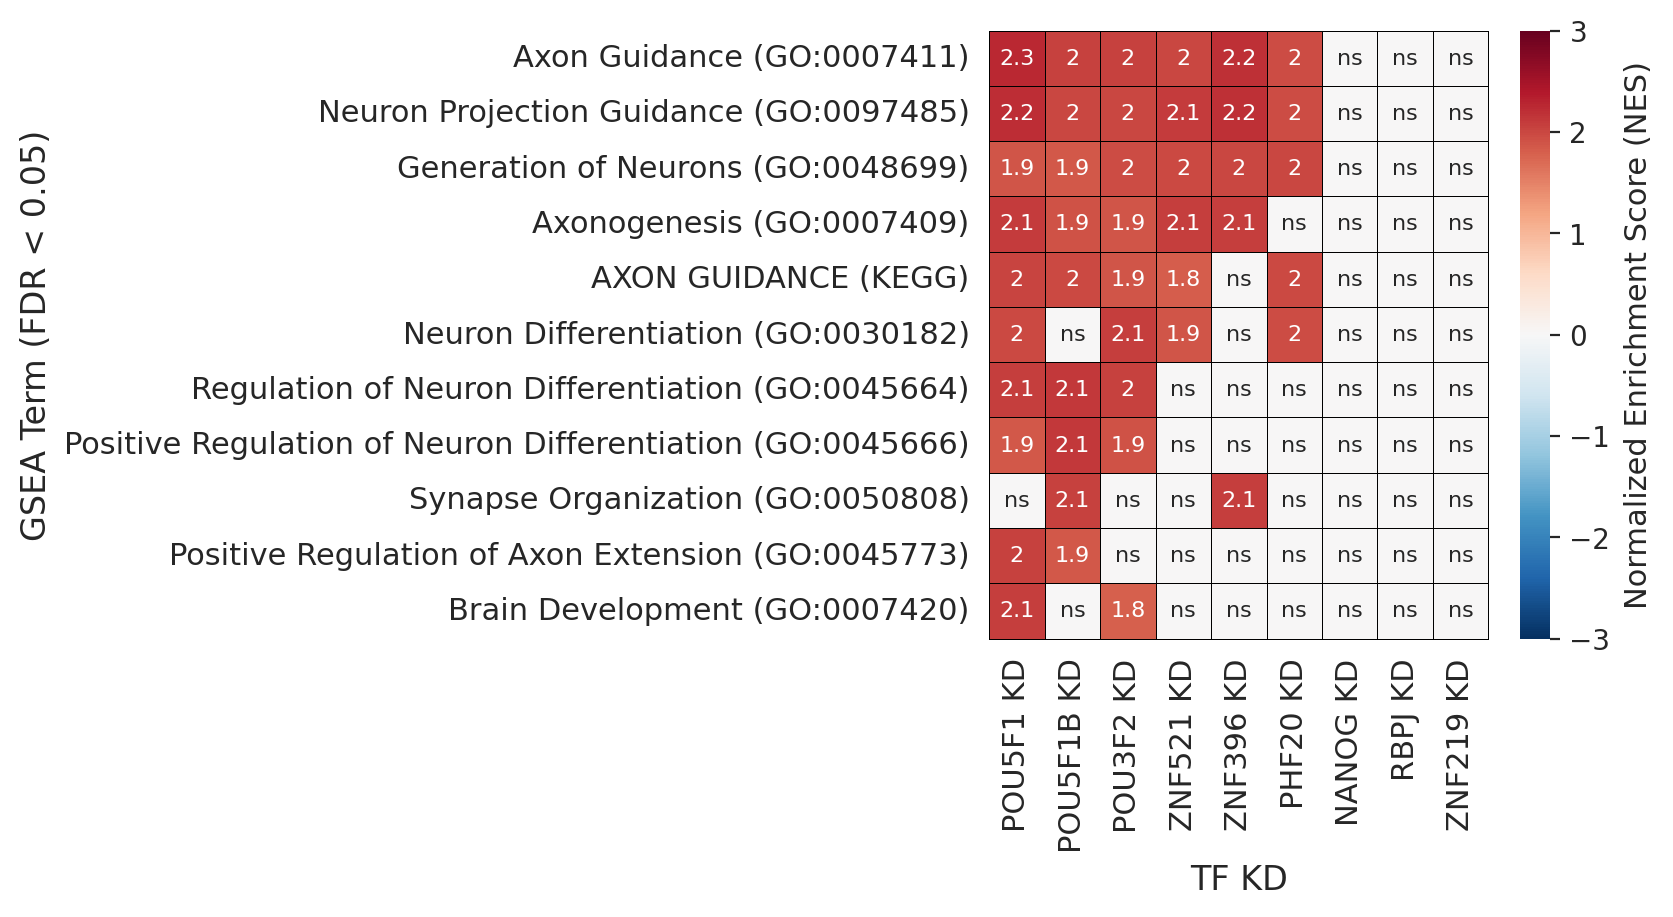

In [24]:
_ = plot_gsea_heatmap(kolf_gsea_results, kds=cl3_tf_kds,
                    terms=neuroectoderm_terms, sort_columns=False,
                    kd_col="TF KD", xlabel="TF KD",
                    ylabel="GSEA Term (FDR < 0.05)",
                    figsize=(4,4), cbar_label="Normalized Enrichment Score (NES)",
                    save_path="/home/ranwyl/figures_tf_project/kolf_cl3_gsea_neuroectoderm.png",
                    save_format="png", dpi=300)

In [25]:
ectoderm_terms = {
    'Eye Development (GO:0001654)', 'Camera-Type Eye Development (GO:0043010)', 
    'Visual System Development (GO:0150063)',
    'Sensory Organ Development (GO:0007423)', 'Inner Ear Morphogenesis (GO:0042472)',
}

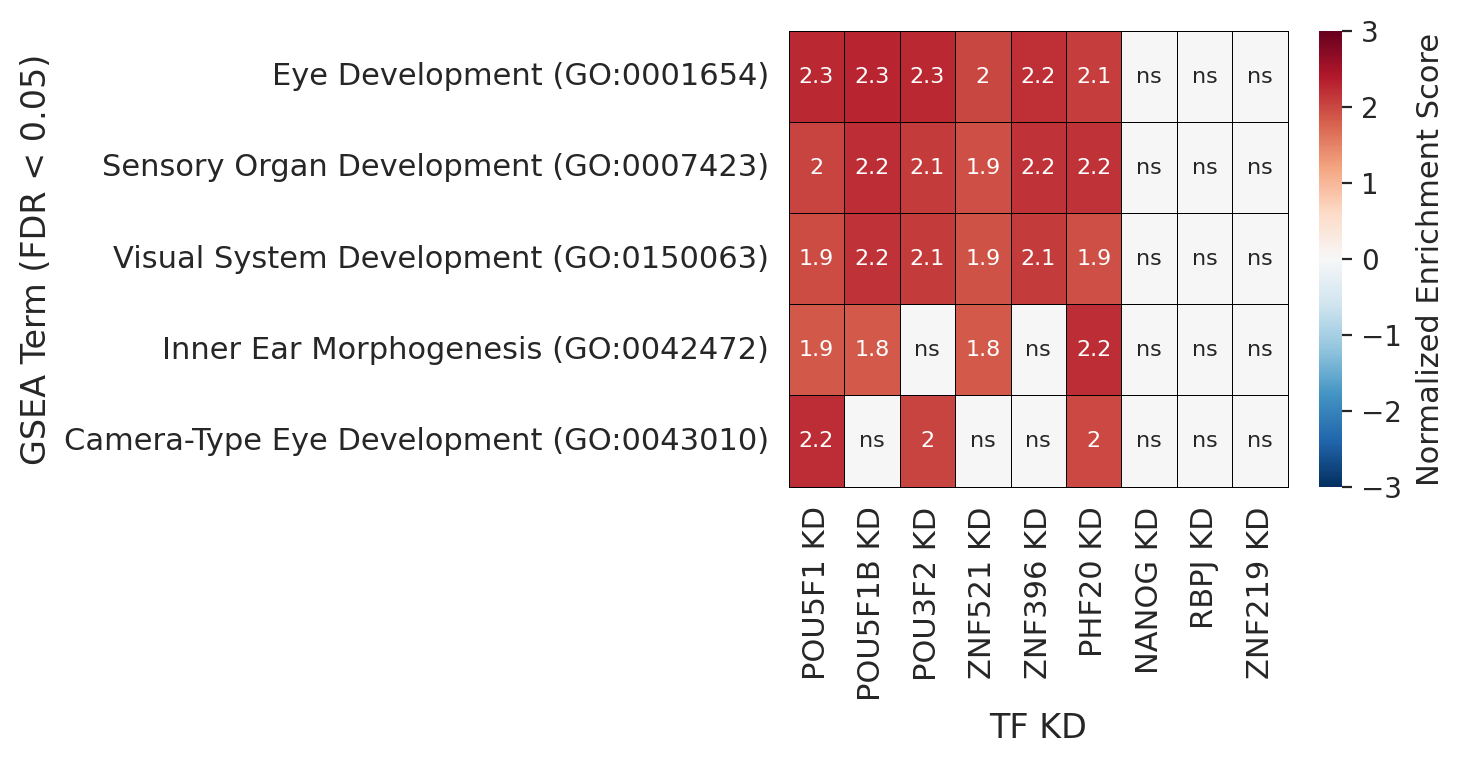

In [26]:
_ = plot_gsea_heatmap(kolf_gsea_results, kds=cl3_tf_kds,
                    terms=ectoderm_terms, sort_columns=False,
                    kd_col="TF KD", xlabel="TF KD", ylabel="GSEA Term (FDR < 0.05)",
                    figsize=(4,3), cbar_label="Normalized Enrichment Score",
                    save_path="/home/ranwyl/figures_tf_project/kolf_cl3_gsea_ectoderm.png",
                    save_format="png", dpi=300)

In [27]:
mesoderm_terms = {
    'Regulation of Chondrocyte Differentiation (GO:0032330)', 
    'Connective Tissue Development (GO:0061448)', 'Cartilage Development (GO:0051216)',
    'Skeletal System Development (GO:0001501)',
    'Positive Regulation of Osteoblast Differentiation (GO:0045669)', 
    'Positive Regulation of Ossification (GO:0045778)', 
    'Positive Regulation of Bone Mineralization (GO:0030501)', 'Angiogenesis', 
    'Limb Development (GO:0060173)', 'Heart Development (GO:0007507)',
    'Regulation of Sprouting Angiogenesis (GO:1903670)', 
}

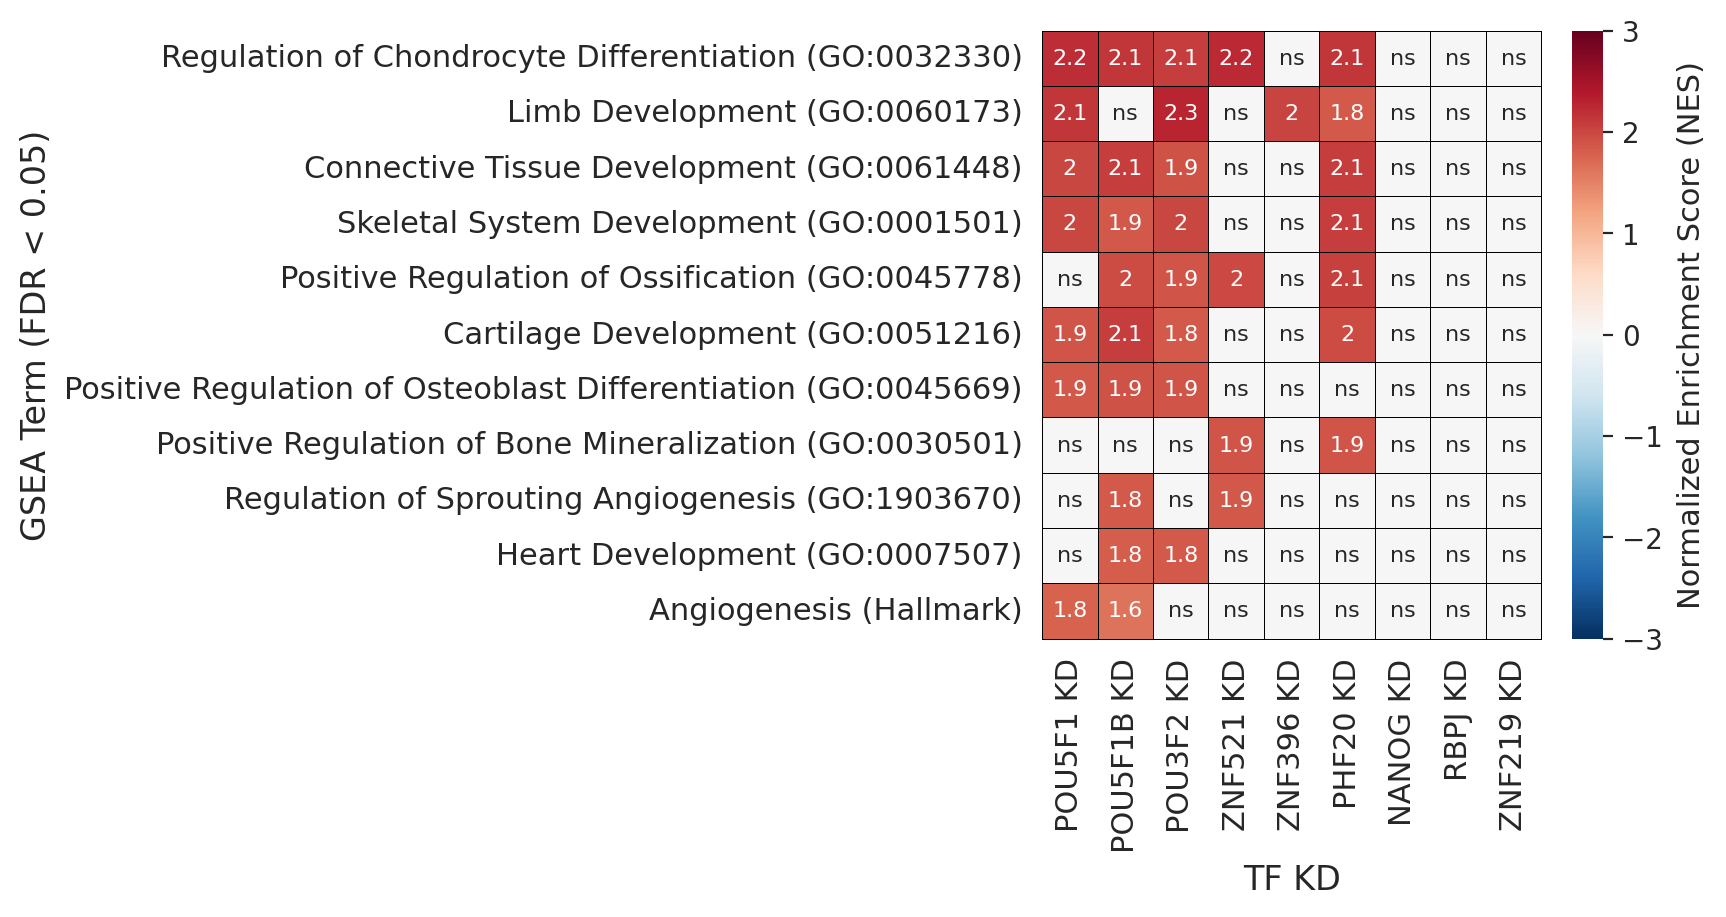

In [28]:
_ = plot_gsea_heatmap(kolf_gsea_results, kds=cl3_tf_kds,
                    terms=mesoderm_terms, sort_columns=False,
                    kd_col="TF KD", xlabel="TF KD",
                    ylabel="GSEA Term (FDR < 0.05)",
                    figsize=(4,4), cbar_label="Normalized Enrichment Score (NES)",
                    save_path="/home/ranwyl/figures_tf_project/kolf_cl3_gsea_mesoderm.png",
                    save_format="png", dpi=300)

In [29]:
ecm_terms = {'Elastic Fibre Formation', 
            'Molecules Associated With Elastic Fibres', 
            'CELL ADHESION MOLECULE (CAM) INTERACTION', 
            'Cell-Cell Adhesion via Plasma-Membrane Adhesion Molecules (GO:0098742)', 
            'Cell Junction Assembly (GO:0034329)', 
            'Cell-Cell Adhesion Mediated by Cadherin (GO:0044331)',
            'Adherens Junction Organization (GO:0034332)'}

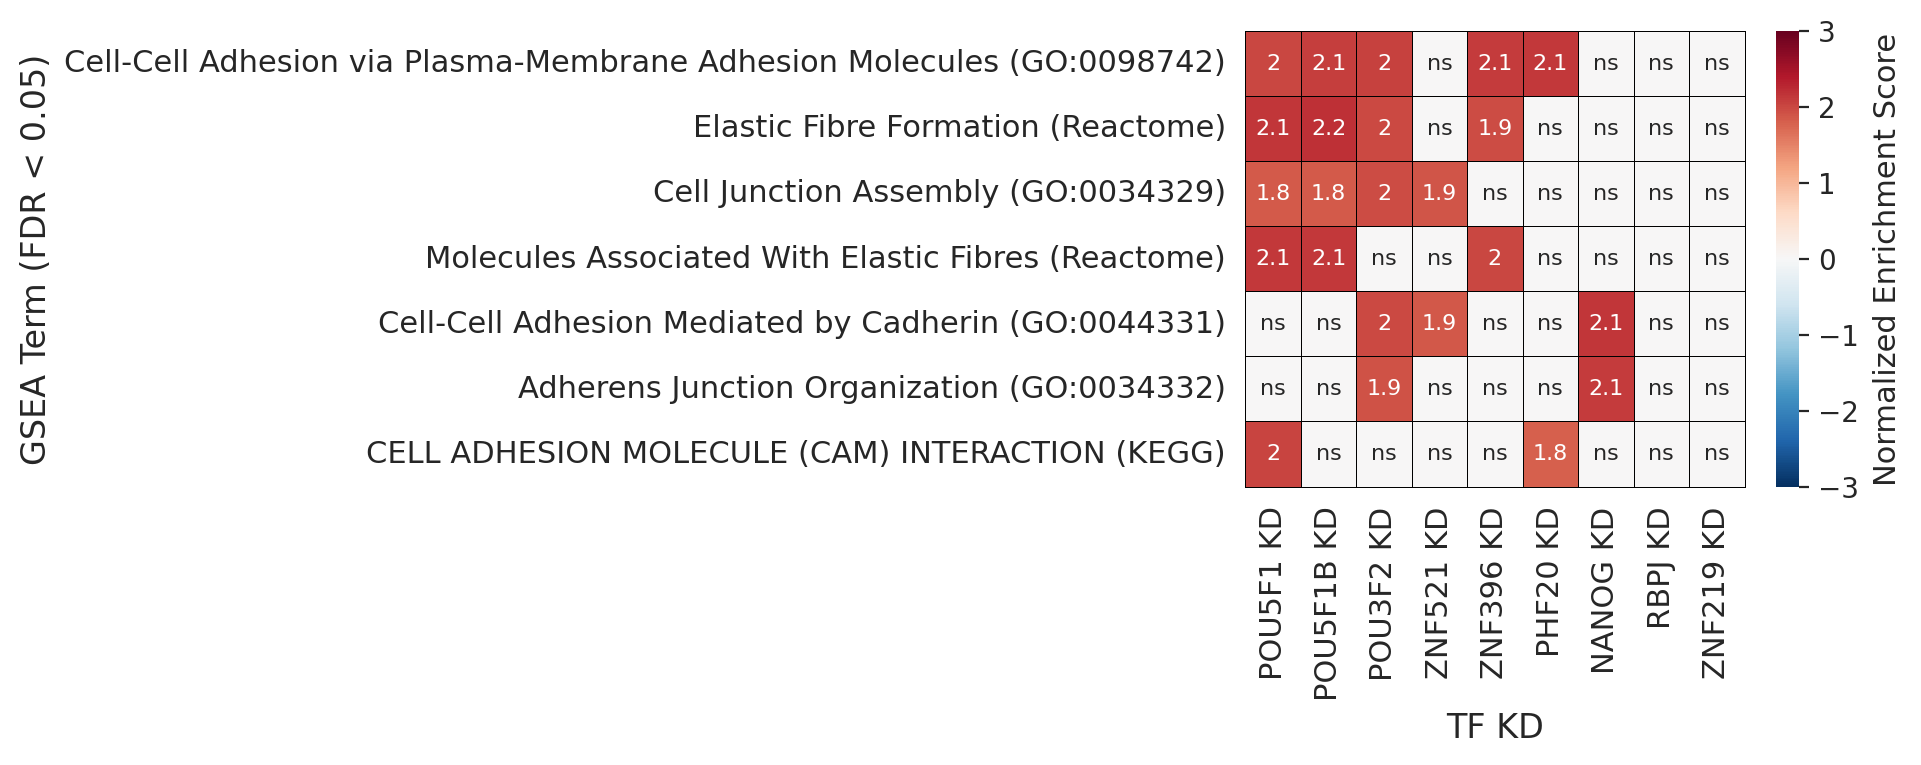

In [30]:
_ = plot_gsea_heatmap(kolf_gsea_results, kds=cl3_tf_kds,
                    sort_columns=False, ylabel="GSEA Term (FDR < 0.05)",
                    terms=ecm_terms, kd_col="TF KD", xlabel="TF KD",
                    figsize=(4,3), cbar_label="Normalized Enrichment Score",
                    save_path="/home/ranwyl/figures_tf_project/kolf_cl3_gsea_ecm.png",
                    save_format="png", dpi=300)

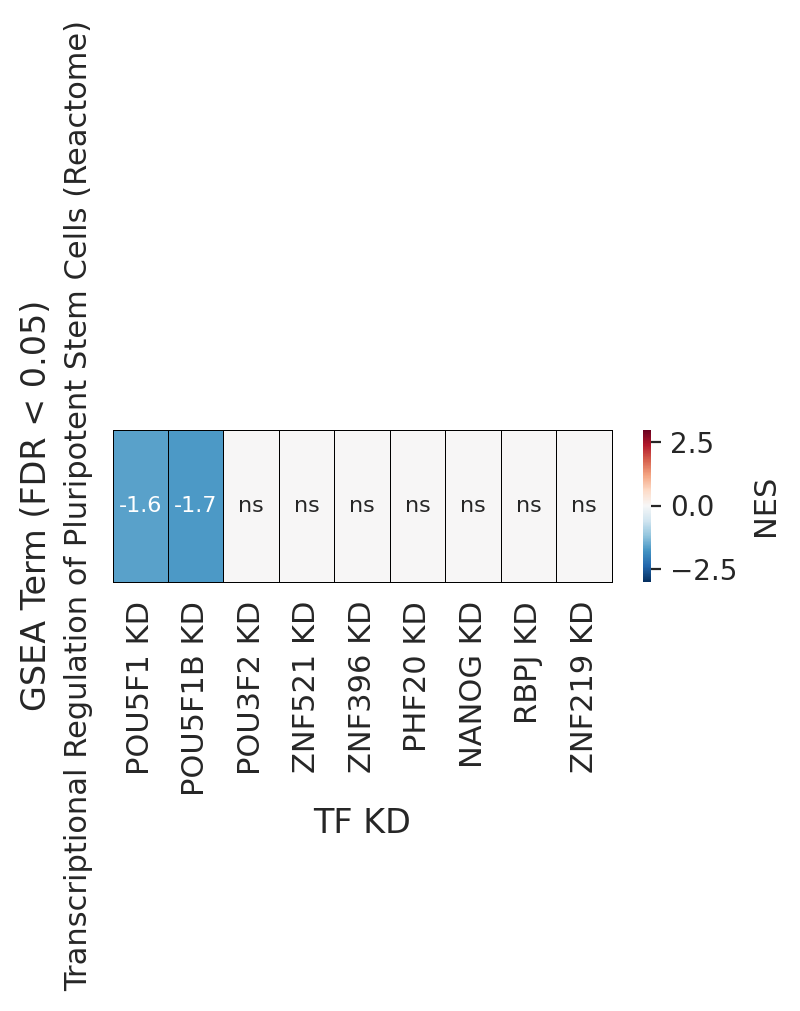

In [54]:
_ = plot_gsea_heatmap(kolf_gsea_results, kds=cl3_tf_kds,
                    sort_columns=False, ylabel="GSEA Term (FDR < 0.05)",
                    terms={"Transcriptional Regulation of Pluripotent Stem Cells"}, 
                    kd_col="TF KD", xlabel="TF KD",
                    figsize=(4,1), cbar_label="NES", vmin=-3, vmax=3)
                    # save_path="/home/ranwyl/figures_tf_project/kolf_cl3_gsea_ecm.png",
                    # save_format="png", dpi=300)

In [31]:
cl3_tfs_plot = ['SOX4', 'FEZF1', 'SIX3', 'PAX6', 'NEUROD1', 'SOX9', 'MKX', 'POU5F1']
cl3_tf_annots = {'Neuroectoderm': ['SOX4', 'FEZF1', 'PAX6', 'SIX3', 'NEUROD1'],
                'Mesoderm': ['SOX9', 'MKX'],
                'Ectoderm': ['PAX6', 'SIX3'],
                'Endoderm': ['PAX6', 'NEUROD1'],
                'Pluripotency': ['POU5F1']}
cl3_tf_annot_colors = {'Neuroectoderm': '#56B4E9', 'Ectoderm': '#0173B2', 
                       'Endoderm': '#ECE133', 'Mesoderm': '#029E73', 
                       'Pluripotency': '#D55E00'}

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


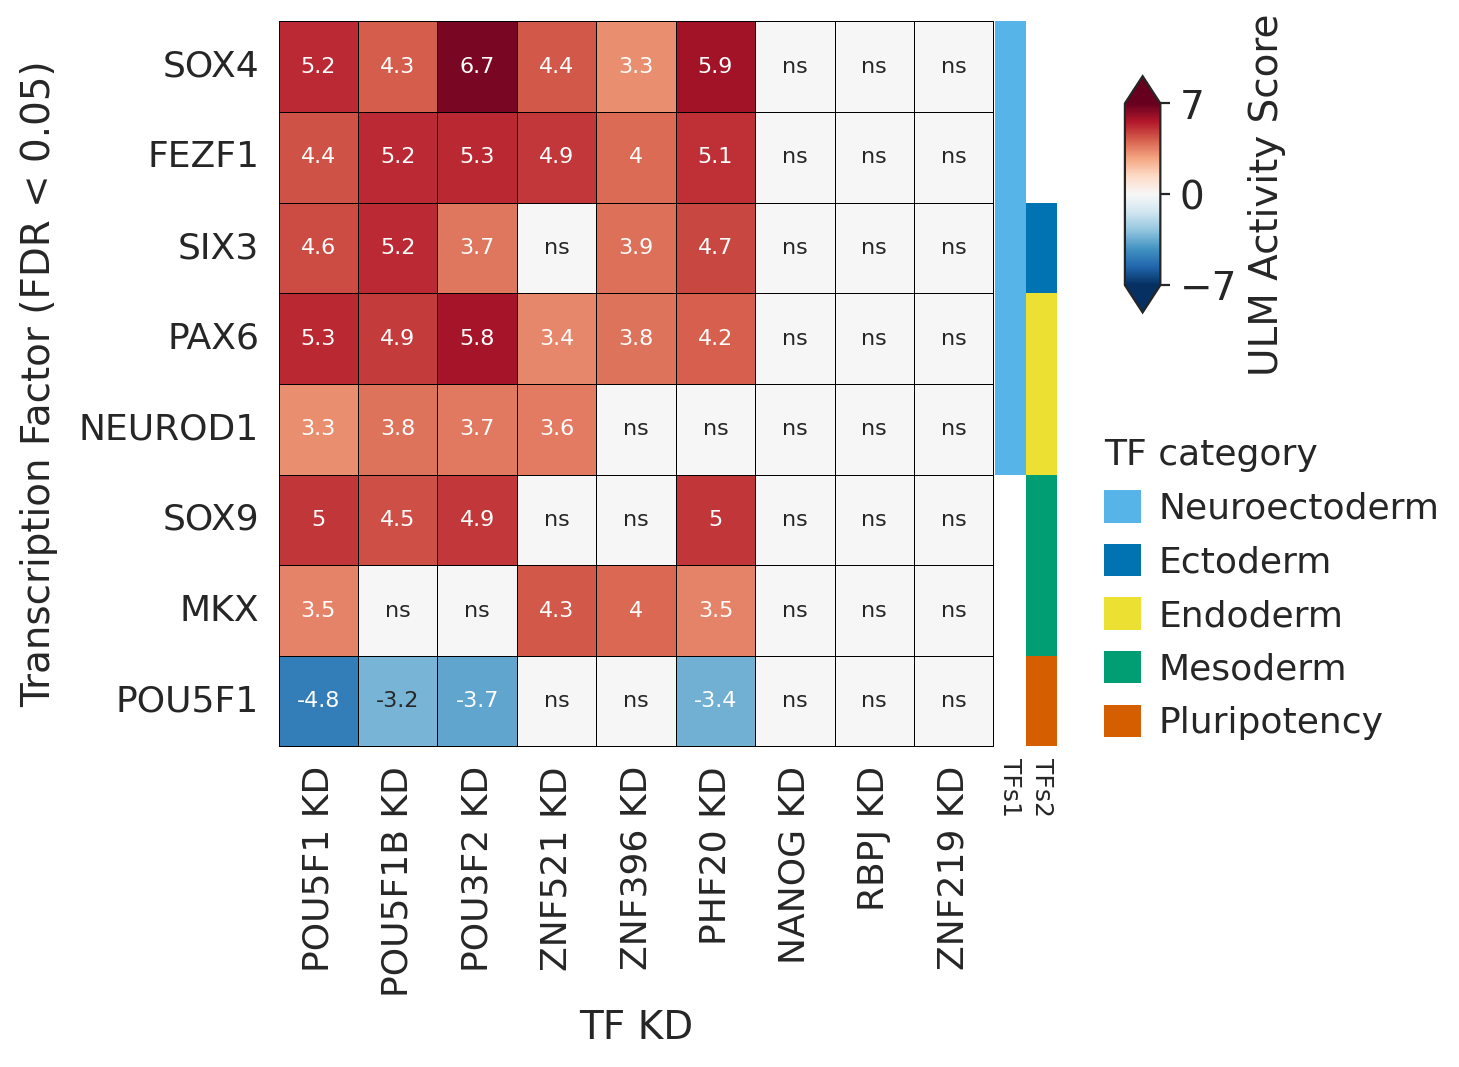

In [32]:
plot_tf_pw_activity_heatmap(tf_acts_df_kds_kolf[cl3_tfs_plot], kds=cl3_tf_kds,
                            xlabel="TF KD", ylabel="Transcription Factor (FDR < 0.05)", 
                            figsize=(5,4), xvals="kds", sort_columns=False, sort_rows=False,
                            annotations_for_bars=cl3_tf_annots, n_annotation_bars=2,
                            annotation_bar_1_label="Neuroectoderm",
                            annotation_colors=cl3_tf_annot_colors, xlabel_pad=90,
                            annot_legend_position=(1.13, 0.45), ylabel_pad=75,
                            save_path="/home/ranwyl/figures_tf_project/kolf_cl3_tf_acts.png",
                            save_format="png", dpi=300)

In [ ]:
# cl3_tfs_plot = ['SOX4', 'FEZF1', 'PAX6', 'SIX3', 'SOX9', 'MKX', 'NEUROD1', 'POU5F1']
# plot_tf_pw_activity_heatmap(tf_acts_df_kds_kolf[cl3_tfs_plot], kds=cl3_tf_kds,
#                             title="KOLF HDBSCAN CL3 CollecTRI TF Activities",
#                             xlabel="TF KD", ylabel="Transcription Factor (FDR < 0.05)", 
#                             figsize=(5,4), xvals="kds", sort_columns=False, sort_rows=False,
#                             cbar_size=0.75)

DEGs

In [33]:
cl3_gene_annots = {'Mesoderm': ['GREB1L', 'GPC3', 'SOX5', 'HAPLN1'],
                   'Ectoderm': ['SIX3', 'SIX6', 'HESX1'],
                   'Neuroectoderm': ['PRTG', 'SIX3', 'ZIC1', 'FEZF1', 'HESX1', 'MAP2', 'SOX5', 
                                     'HAPLN1', 'EPHA4', 'SEMA6D', 'SEMA5A', 'ERBB4', 'SHTN1',
                                     'LRRC4C', 'CADM1', 'PCDH7', 'PCDH11Y', 'CDH2'],
                   'Cell Adhesion & ECM': ['MAP2', 'LRRC4C', 'CADM1', 'PCDH7', 'PCDH11Y', 'CDH2',
                                           'FBN2', 'PALLD', 'CDH6', 'LTBP1', 'ITGB8']}
cl3_gene_annot_colors = {'Mesoderm': '#029E73', 'Neuroectoderm': '#56B4E9', 'Ectoderm': '#0173B2', 
                        'Cell Adhesion & ECM': '#CC78BC'}

cl3_degs_up = \
    ['GREB1L', 'GPC3', 'SOX5', 'HAPLN1', 
     'SIX3', 'SIX6', 'HESX1', 'PRTG', 'SHTN1',
     'FEZF1', 'ZIC1',
     'EPHA4', 'SEMA6D', 'SEMA5A', 'ERBB4',
     'MAP2', 'LRRC4C', 'CADM1', 'PCDH7', 'PCDH11Y', 'CDH2',
     'FBN2', 'PALLD', 'CDH6', 'LTBP1', 'ITGB8']

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


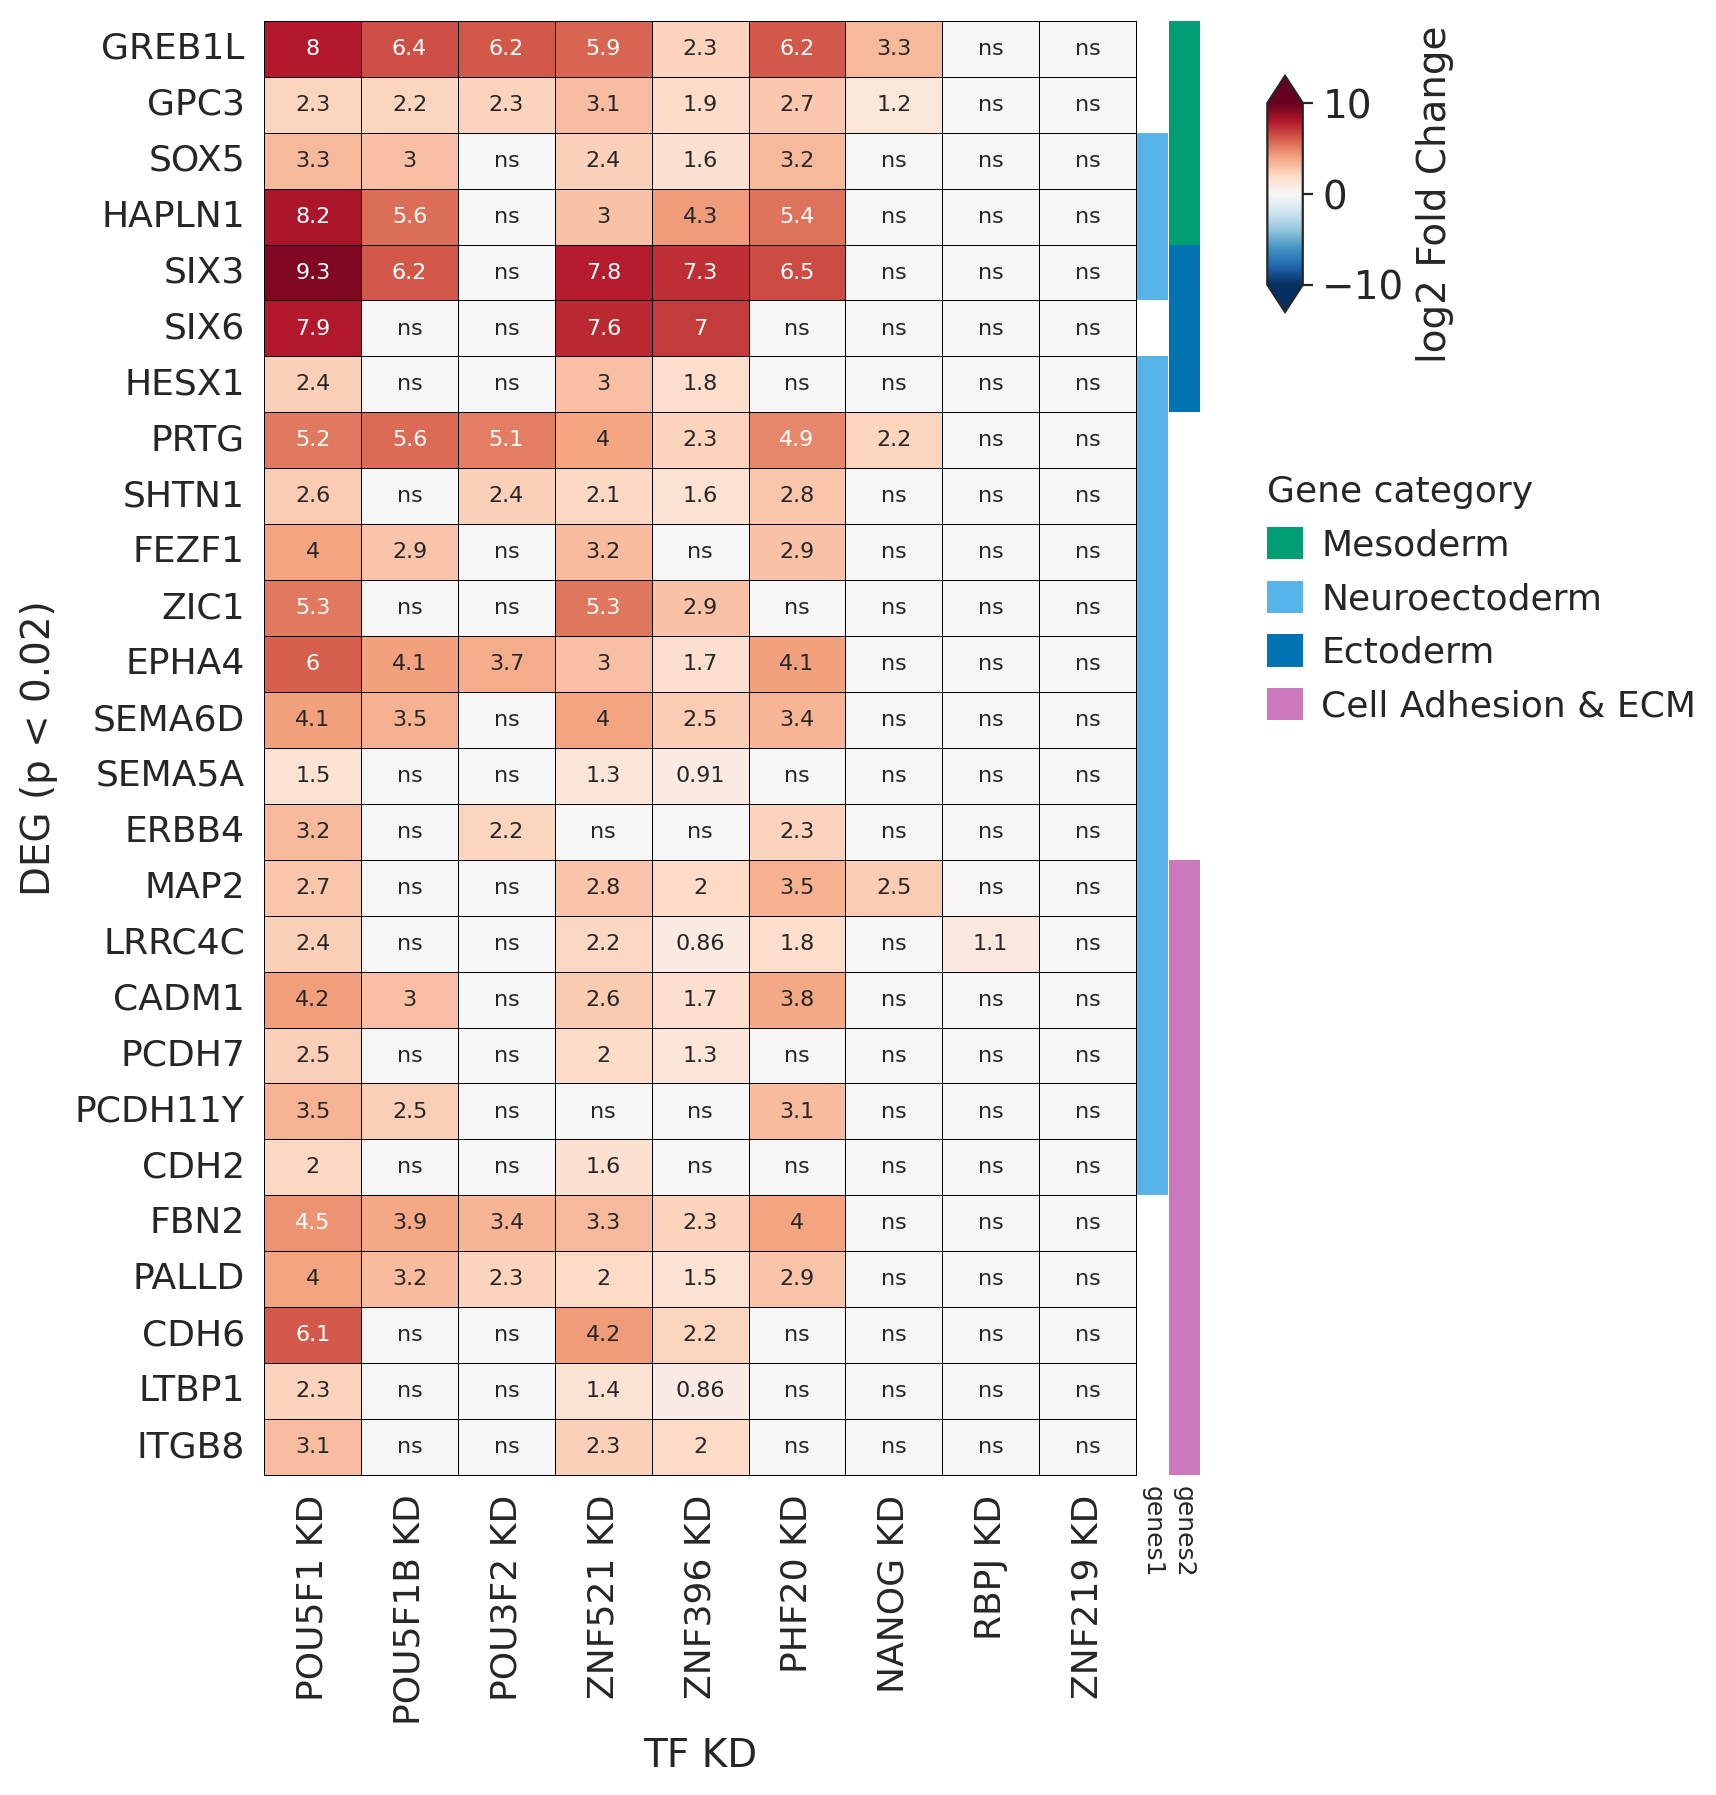

In [34]:
cl3_degs_up_heatmap_df = plot_DEG_LFC_heatmap(kolf_deg_lfcs, kds=cl3_tf_kds,
                         degs=cl3_degs_up, sort_rows=False, xlabel="TF KD",
                         ylabel="DEG (p < 0.02)", sort_columns=False,
                         figsize=(6,8), ylabel_pad=70, xlabel_pad=90,
                         annotations_for_bars=cl3_gene_annots, n_annotation_bars=2,
                         annotation_bar_1_label="Neuroectoderm",
                         annotation_colors=cl3_gene_annot_colors,
                         annot_legend_position=(1.13, 0.7),
                         save_path="/home/ranwyl/figures_tf_project/kolf_cl3_degs_up.png",
                         save_format="png", dpi=300)

In [35]:
collectri[(collectri["source"] == "POU5F1") &
          (collectri["target"].isin(cl3_degs_up))]

,source,target,weight,resources,references,sign_decision


In [36]:
cl3_degs_down = ['POU5F1', 'ESRG', 'TERF1', 'CD24']
cl3_degs_down_annot = {'Pluripotency': cl3_degs_down}
cl3_degs_down_colors = {'Pluripotency': '#D55E00'}

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


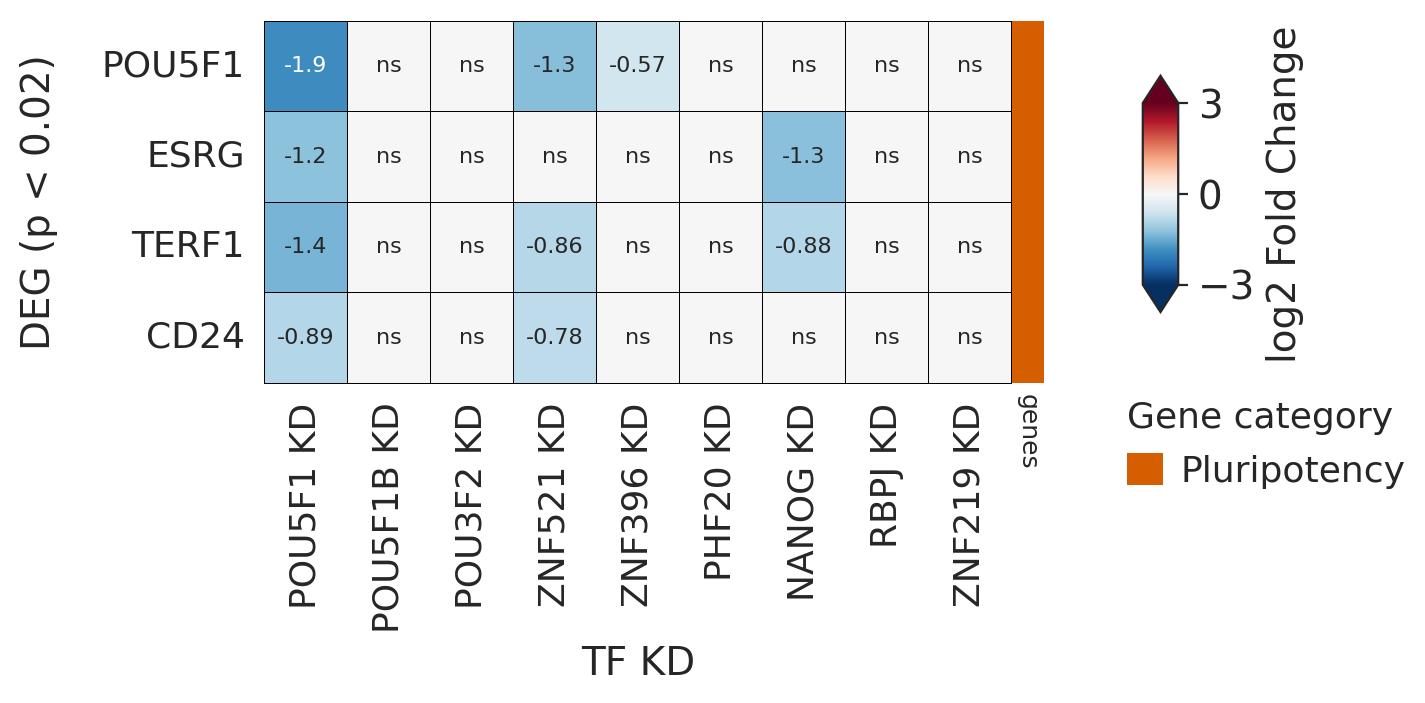

In [40]:
_ = plot_DEG_LFC_heatmap(kolf_deg_lfcs, kds=cl3_tf_kds,
                         degs=cl3_degs_down, sort_rows=False,
                         ylabel="DEG (p < 0.02)", sort_columns=False,
                         figsize=(5,2), vmin=-3, vmax=3, xlabel="TF KD",
                         annotations_for_bars=cl3_degs_down_annot, n_annotation_bars=1,
                         annotation_colors=cl3_degs_down_colors,
                         annot_legend_position=(1.13, 0),
                         save_path="/home/ranwyl/figures_tf_project/kolf_cl3_degs_down.png",
                         save_format="png", dpi=300)

In [ ]:
collectri[(collectri["source"] == "POU5F1") &
          (collectri["target"].isin(cl3_degs_down))]

,source,target,weight,resources,references,sign_decision
8378,POU5F1,POU5F1,1.0,ExTRI;NTNU.Curated;Pavlidis2021;TFactS,15557334;15988017;16790525;17324942;20505756,PMID
11205,POU5F1,DPPA4,1.0,ExTRI;NTNU.Curated;SIGNOR,16846370;17068183;18366076,PMID
13277,POU5F1,ESRG,1.0,ExTRI;NTNU.Curated,17803967,default activation
24564,POU5F1,TERF1,1.0,ExTRI;NTNU.Curated,23735977,default activation
31951,POU5F1,L1TD1,1.0,TRRUST,22162396,default activation


In [ ]:
# cl3_gene_annots_all = {'Mesoderm': ['GREB1L', 'GPC3', 'SOX5', 'HAPLN1'],
#                    'Ectoderm': ['SIX3', 'SIX6', 'HESX1'],
#                    'Neuroectoderm': ['PRTG', 'SIX3', 'ZIC1', 'FEZF1', 'HESX1', 'MAP2', 'DACH1', 'SOX5', 
#                                      'HAPLN1', 'EPHA4', 'SEMA6D', 'SEMA5A', 'ERBB4', 'SHTN1',
#                                      'LRRC4C', 'CADM1', 'PCDH7', 'PCDH11Y', 'CDH2'],
#                    'Cell Adhesion & ECM': ['LRRC4C', 'CADM1', 'PCDH7', 'PCDH11Y', 'CDH2',
#                                            'FBN2', 'PALLD', 'CDH6', 'LTBP1', 'ITGB8', 'TPBG'],
#                     'Pluripotency': ['POU5F1', 'ESRG', 'TERF1', 'CD24', 'DPPA4', 'L1TD1']}
# cl3_gene_annot_colors_all = {'Mesoderm': '#029E73', 'Neuroectoderm': '#56B4E9', 'Ectoderm': '#0173B2', 
#                         'Cell Adhesion & ECM': '#CC78BC', 'Pluripotency': '#D55E00'}

# cl3_degs_all = \
#     ['GREB1L', 'GPC3', 'SOX5', 'HAPLN1', 
#      'SIX3', 'SIX6', 'HESX1', 'PRTG', 'MAP2', 'SHTN1',
#      'FEZF1', 'DACH1', 'ZIC1',
#      'EPHA4', 'SEMA6D', 'SEMA5A', 'ERBB4',
#      'LRRC4C', 'CADM1', 'PCDH7', 'PCDH11Y', 'CDH2',
#      'FBN2', 'PALLD', 'CDH6', 'LTBP1', 'ITGB8', 'TPBG',
#      'POU5F1', 'ESRG', 'TERF1', 'CD24', 'DPPA4', 'L1TD1']

In [ ]:
# cl3_degs_heatmap_df = plot_DEG_LFC_heatmap(kolf_deg_lfcs, kds=cl3_tf_kds,
#                          degs=cl3_degs_all, sort_rows=False, xlabel="TF KD",
#                          ylabel="DEG (p < 0.02)", sort_columns=False,
#                          figsize=(6,10), ylabel_pad=70, xlabel_pad=90,
#                          vmin=-2, vmax=10,
#                          annotations_for_bars=cl3_gene_annots_all, n_annotation_bars=2,
#                          annotation_bar_1_label="Neuroectoderm",
#                          annotation_colors=cl3_gene_annot_colors_all,
#                          annot_legend_position=(1.13, 0.8))

ChIP-seq targets

In [ ]:
find_encode_chea_tf_experiments(cl3_tf_kds, ["hESC", "H1", "H9"])

ChEA 2022: ['POU5F1 16153702 ChIP-ChIP HESCs Human']
ENCODE 2014: ['POU5F1 H1']
ENCODE 2015: ['NANOG H1-hESC hg19']
ChEA 2022: ['NANOG 21062744 ChIP-ChIP HESCs Human', 'NANOG 16153702 ChIP-ChIP HESCs Human']
ENCODE 2014: ['NANOG H1']
ENCODE 2015: ['NANOG H1-hESC hg19']


### Full figures

In [ ]:
neural_terms_all = {'Axon Guidance (GO:0007411)', 'Neuron Projection Guidance (GO:0097485)', 
                       'Axonogenesis (GO:0007409)', 'Brain Development (GO:0007420)', 
                       'Regulation of Neuron Differentiation (GO:0045664)', 
                       'Neural Crest Cell Migration (GO:0001755)', 
                       'Neural Crest Cell Development (GO:0014032)', 'AXON GUIDANCE', 
                       'Positive Regulation of Axon Extension (GO:0045773)', 
                       'Neuron Differentiation (GO:0030182)', 
                       'EPHA-mediated Growth Cone Collapse', 
                       'Positive Regulation of Neuron Differentiation (GO:0045666)', 
                       'Generation of Neurons (GO:0048699)', 
                       'Regulation of Neuron Migration (GO:2001222)', 
                       'Neuron Projection Morphogenesis (GO:0048812)',
                       'Regulation of Neurogenesis (GO:0050767)',
                       'Synapse Organization (GO:0050808)'}              
_ = plot_gsea_heatmap(kolf_gsea_results, kds=cl3_tf_kds,
                    title="KOLF Cluster 3 GSEA - Neural",
                    terms=neural_terms_all, sort_columns=False,
                    kd_col="TF KD", xlabel="TF KD",
                    ylabel="GSEA Term (FDR < 0.05)",
                    cbar_size=0.5, figsize=(4,6))

In [ ]:
ectoderm_terms_all = {
    'Eye Development (GO:0001654)', 'Camera-Type Eye Development (GO:0043010)', 
    'Visual System Development (GO:0150063)', 'Eye Morphogenesis (GO:0048592)',
    'Sensory Organ Development (GO:0007423)', 'Inner Ear Morphogenesis (GO:0042472)',
}
_ = plot_gsea_heatmap(kolf_gsea_results, kds=cl3_tf_kds,
                    title="KOLF HDBSCAN CL3 GSEA - Ectoderm",
                    terms=ectoderm_terms_all, sort_columns=False,
                    kd_col="TF KD", xlabel="TF KD", ylabel="GSEA Term (FDR < 0.05)",
                    figsize=(4,3))  

In [ ]:
mesoderm_terms_all = {
    'Regulation of Chondrocyte Differentiation (GO:0032330)', 
    'Connective Tissue Development (GO:0061448)', 'Cartilage Development (GO:0051216)',
    'Skeletal System Development (GO:0001501)',
    'Positive Regulation of Osteoblast Differentiation (GO:0045669)', 
    'Positive Regulation of Ossification (GO:0045778)', 
    'Positive Regulation of Bone Mineralization (GO:0030501)', 
    'Embryonic Skeletal System Development (GO:0048706)',
    'RUNX2 Regulates Osteoblast Differentiation', 'RUNX2 Regulates Bone Development',
    'Embryonic Limb Morphogenesis (GO:0030326)', 'Myogenesis', 
    'Fat Cell Differentiation (GO:0045444)',  
    'Kidney Development (GO:0001822)', 'Angiogenesis', 
    'Limb Development (GO:0060173)',
    'Aortic Valve Morphogenesis (GO:0003180)', 
    'Heart Development (GO:0007507)', 'Striated Muscle Tissue Development (GO:0014706)',
    'Regulation of Sprouting Angiogenesis (GO:1903670)', 'Gonad Development (GO:0008406)',
}
_ = plot_gsea_heatmap(kolf_gsea_results, kds=cl3_tf_kds, 
                    title="KOLF HDBSCAN CL3 GSEA - Mesoderm",
                    terms=mesoderm_terms_all, sort_columns=False,
                    kd_col="TF KD", xlabel="TF KD",
                    ylabel="GSEA Term (FDR < 0.05)",
                    cbar_size=0.5, figsize=(4,7))  

In [ ]:
emt_ecm_terms = {'Elastic Fibre Formation', 
                    'Molecules Associated With Elastic Fibres', 
                    'CELL ADHESION MOLECULE (CAM) INTERACTION', 
                    'Cell-Cell Adhesion via Plasma-Membrane Adhesion Molecules (GO:0098742)', 
                    'ECM Proteoglycans', 
                    'Cell Junction Assembly (GO:0034329)', 
                    'Homophilic Cell Adhesion via Plasma Membrane Adhesion Molecules (GO:0007156)',
                    'Epithelial Mesenchymal Transition', 
                    'Regulation of Epithelial to Mesenchymal Transition (GO:0010717)',
                    'Mesenchymal Cell Migration (GO:0090497)', 
                    'Cell-Cell Adhesion Mediated by Cadherin (GO:0044331)',
                    'Adherens Junction Organization (GO:0034332)'}
_ = plot_gsea_heatmap(kolf_gsea_results, kds=cl3_tf_kds, 
                    title="KOLF HDBSCAN CL3 GSEA - EMT + ECM Remodeling",
                    sort_columns=False, ylabel="GSEA Term (FDR < 0.05)",
                    terms=emt_ecm_terms,
                    kd_col="TF KD", xlabel="TF KD",
                    cbar_size=0.5, figsize=(4,4))  

In [ ]:
signaling_terms_up = {
    'Regulation of Smoothened Signaling Pathway (GO:0008589)', 
    'HEDGEHOG SIGNALING PATHWAY', 'WNT SIGNALING PATHWAY',
    'Non-Canonical Wnt Signaling Pathway (GO:0035567)', 
    'Response to Transforming Growth Factor Beta (GO:0071559)', 
    'Notch Signaling', 'Regulation of Wnt Signaling Pathway (GO:0030111)', 
    'TGF-beta Signaling',
    'Ephrin Receptor Signaling Pathway (GO:0048013)',
    'Wnt-beta Catenin Signaling',
}
_ = plot_gsea_heatmap(kolf_gsea_results[kolf_gsea_results["NES"] > 0], kds=cl3_tf_kds, 
                    title="KOLF HDBSCAN CL3 GSEA - Developmental Signaling",
                    sort_columns=False, ylabel="GSEA Term (FDR < 0.05)",
                    terms=signaling_terms_up,
                    kd_col="TF KD", xlabel="TF KD",
                    cbar_size=0.5, figsize=(4,4))

In [ ]:
signaling_terms_down = {
    'Interferon Alpha Beta Signaling', 
    'Response to Interferon-Beta (GO:0035456)',
    'Response to Type II Interferon (GO:0034341)',
    'FCERI Mediated NF-kB Activation', 'TCR Signaling',
    'Inactivation of CSF3 (G-CSF) Signaling', 'Interleukin-12 Signaling', 
    'Interleukin-12 Family Signaling', 'Interleukin-1 Signaling', 'Downstream TCR Signaling',
    'Gene and Protein Expression by JAK-STAT Signaling After Interleukin-12 Stimulation',
    'TNFR2 Non-Canonical NF-kB Pathway', 'DDX58 IFIH1-mediated Induction of Interferon-Alpha Beta',
}
_ = plot_gsea_heatmap(kolf_gsea_results[kolf_gsea_results["NES"] < 0], kds=cl3_tf_kds, 
                    title="KOLF HDBSCAN CL3 GSEA - Signaling Down",
                    sort_columns=False,
                    terms=signaling_terms_down, 
                    kd_col="TF KD", xlabel="TF KD",
                    cbar_size=0.5, figsize=(4,6))

In [ ]:
plot_tf_pw_activity_heatmap(tf_acts_df_kds_kolf, kds=cl3_tf_kds,
                            title="KOLF HDBSCAN CL3 CollecTRI TF Activities",
                            xlabel="TF KD", ylabel="Transcription Factor", figsize=(7,10),
                            xvals="kds", top=30, sort_columns=False, 
                            cbar_size=0.75)

In [ ]:
cl3_degs_up_sig = ['FZD5', 'FZD8', 'FRZB', 'SFRP1', 'IL17RD', 'FST'] # SIGNALING
_ = plot_DEG_LFC_heatmap(kolf_deg_lfcs, kds=cl3_tf_kds,
                         title="KOLF Cluster 3 DEGS - Developmental Signaling", 
                         degs=cl3_degs_up_sig, sort_rows=False,
                         ylabel="DEG (p < 0.02)", sort_columns=False,
                         figsize=(5,3))

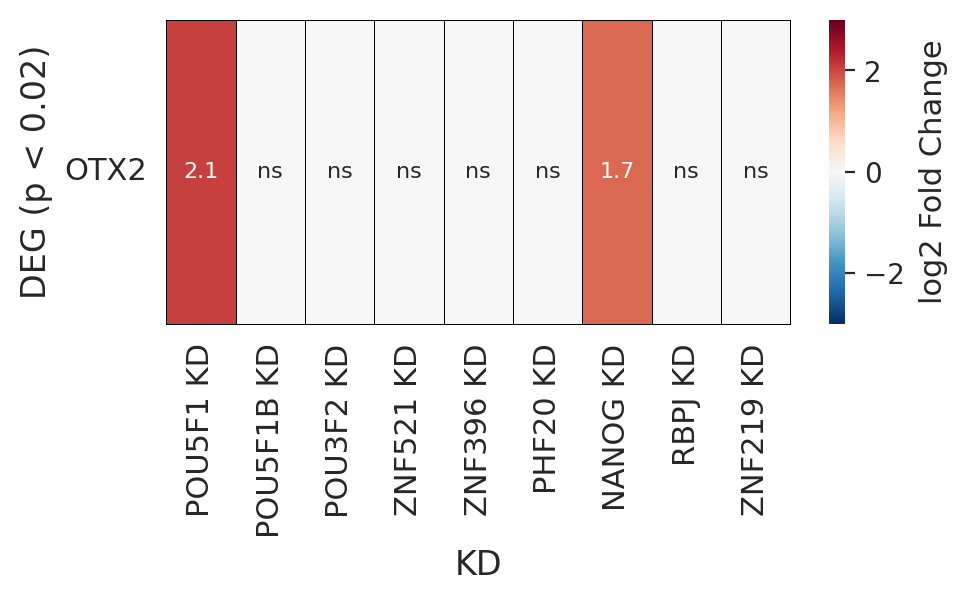

In [123]:
_ = plot_DEG_LFC_heatmap(kolf_deg_lfcs, kds=cl3_tf_kds, 
                         degs=["OTX2"], sort_rows=False,
                         ylabel="DEG (p < 0.02)", sort_columns=False,
                         figsize=(5,2))

In [ ]:
# cl3_degs_up_dev = \
#     ['GPC3', # General development
#      'PRTG', # Tissue development and neurogenesis
#      'SIX3', 'SIX6', 'HESX1', # Ectoderm
#      'ZIC1', 'FEZF1', 'MAP2', 'DACH1', # Neural
#      'EPHA4', 'SEMA6D', 'LRRC4C', 'CADM1', 'ERBB4', # Axon guidance, synapse formation
#      'SOX5', 'HAPLN1', # Skeletal + brain or nervous system development (neuroecto- and mesoderm)
#      'GREB1L',
#      'FBN2', 'CDH2', 'CDH6', 'CDH11', 'LTBP1', 'ITGB8', 'TPBG'] # Mesoderm

# cl3_degs_up_heatmap_df = plot_DEG_LFC_heatmap(kolf_deg_lfcs, kds=cl3_tf_kds,
#                          title="KOLF HDBSCAN CL3 DEGs\nDevelopment + Germ Layer", 
#                          degs=cl3_degs_up_dev, sort_rows=False,
#                          ylabel="DEG (p < 0.02)", sort_columns=False,
#                          figsize=(5,8), cbar_size=0.75)

In [ ]:
_ = plot_DEG_LFC_heatmap(kolf_deg_lfcs, cluster=3, cluster_df=hdbscan_clusters_kolf,
                         title="KOLF HDBSCAN CL3 Top Shared DEG LFCs",
                         ylabel="DEG (p < 0.02)", top=25, sort_columns=True,
                         figsize=(5,8), cbar_size=0.75)

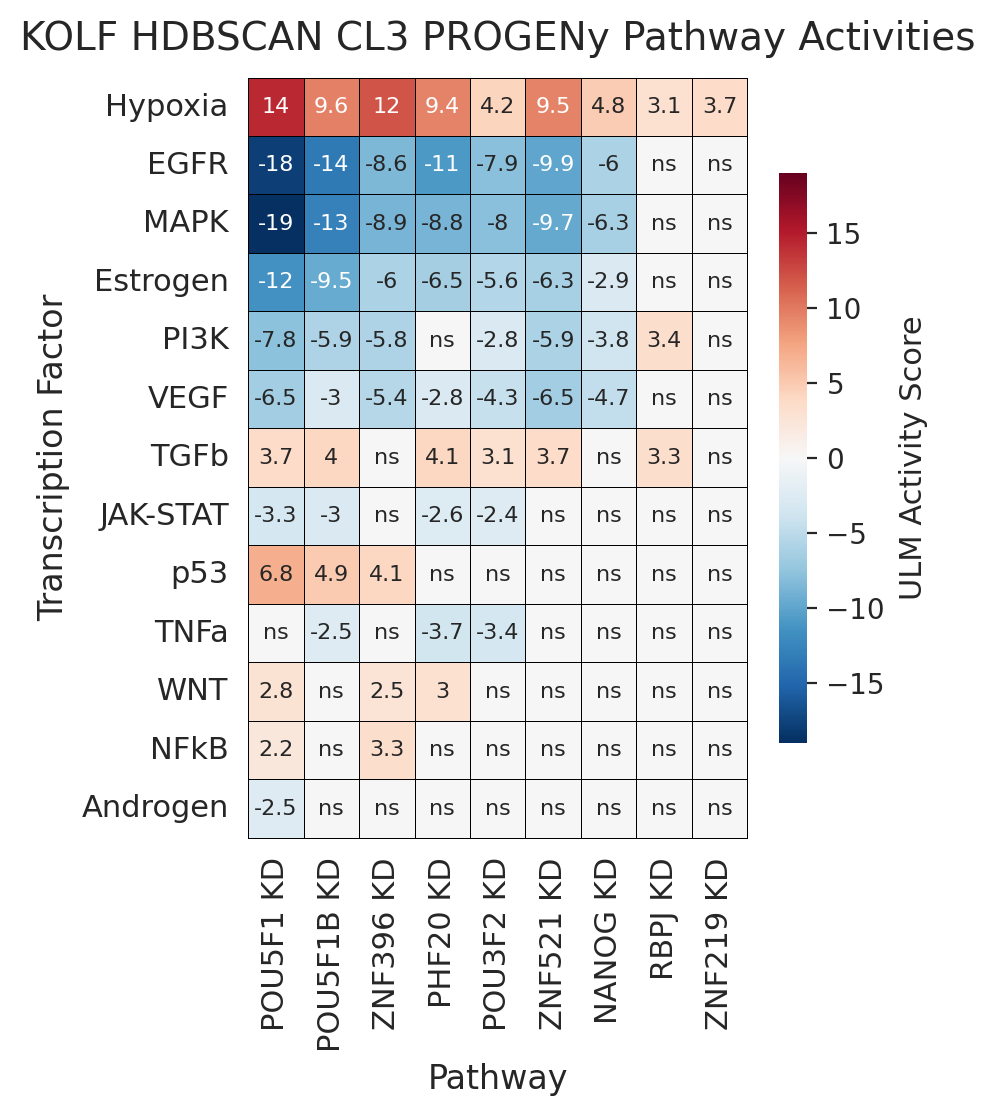

In [130]:
plot_tf_pw_activity_heatmap(pw_acts_df_kds_kolf, kds=cl3_tf_kds,
                            title="KOLF HDBSCAN CL3 PROGENy Pathway Activities",
                            xlabel="Pathway", ylabel="Transcription Factor", figsize=(4,5),
                            xvals="kds", top=25, sort_columns=True, 
                            cbar_size=0.75)

# POU5F1 KD

## GSEA

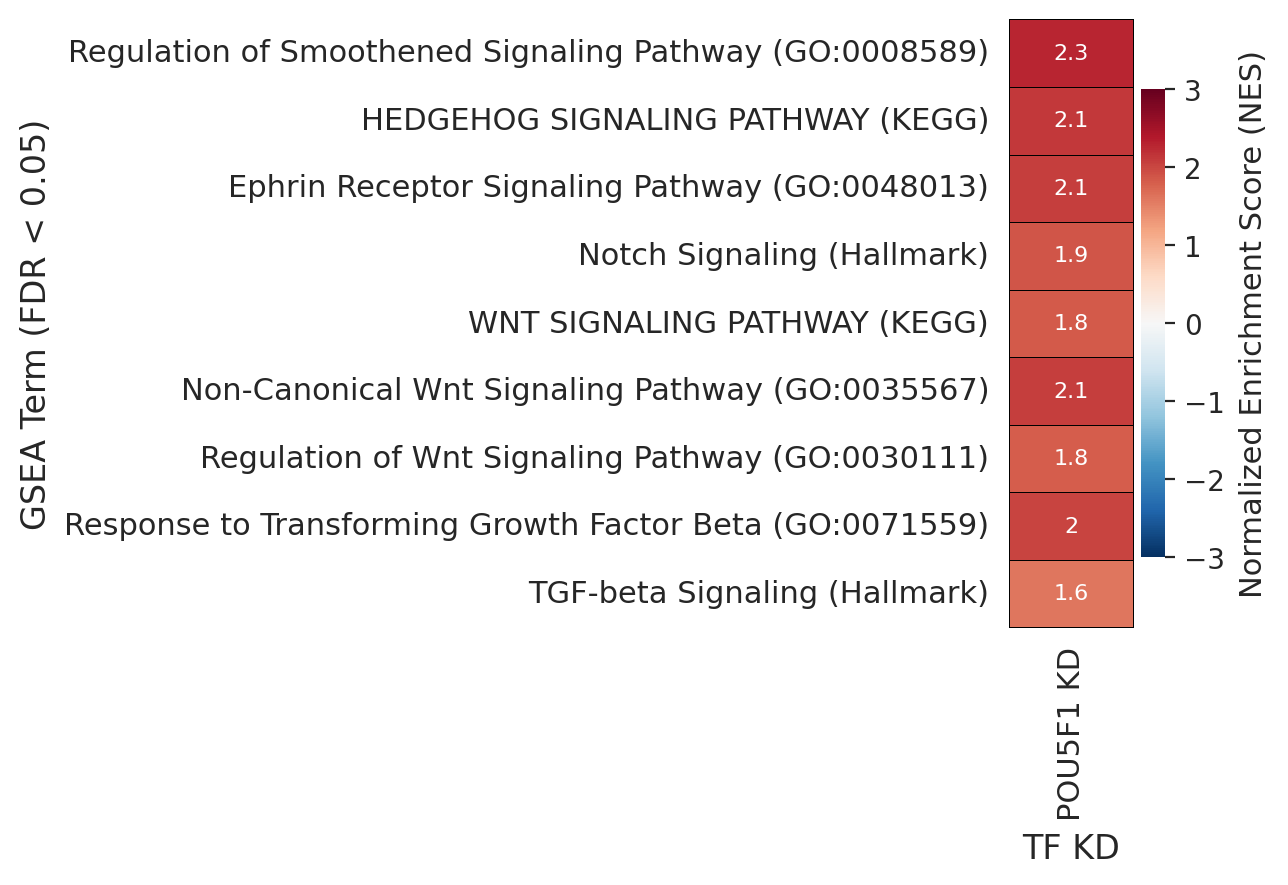

In [75]:
signaling_terms_up = [
    'Regulation of Smoothened Signaling Pathway (GO:0008589)', 
    'HEDGEHOG SIGNALING PATHWAY',
    'Ephrin Receptor Signaling Pathway (GO:0048013)', 'Notch Signaling', 
    'WNT SIGNALING PATHWAY',
    'Non-Canonical Wnt Signaling Pathway (GO:0035567)', 
    'Regulation of Wnt Signaling Pathway (GO:0030111)', 
    'Response to Transforming Growth Factor Beta (GO:0071559)', 'TGF-beta Signaling']
_ = plot_gsea_heatmap(kolf_gsea_results, kds=['POU5F1'], 
                    sort_columns=False, ylabel="GSEA Term (FDR < 0.05)",
                    terms=signaling_terms_up, sort_rows=False,
                    kd_col="TF KD", xlabel="TF KD", cbar_size=1,
                    figsize=(1,4), cbar_label="Normalized Enrichment Score (NES)",
                    save_path="/home/ranwyl/figures_tf_project/kolf_pou5f1_kd_gsea_signaling.png",
                    save_format="png", dpi=300)

In [74]:
pou5f1_signaling_gsea = kolf_gsea_enriched[(kolf_gsea_enriched["TF KD"] == "POU5F1") &
                                           (kolf_gsea_enriched["Term"].isin(signaling_terms_up))]
with pd.option_context("display.max_colwidth", None):
    display(pou5f1_signaling_gsea)

,Cell line,HDBSCAN cluster,Leiden cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,# DE lead genes,# lead genes w/ |Wald| > 1,Tag %,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
9758,KOLF2.1J,3,8,POU5F1,GO_Biological_Process_2025,Regulation of Smoothened Signaling Pathway (GO:0008589),0.670731,2.289130,0.000000,0.000287,0.0003,5,16,16/48,8.37%,GLI3;GPC3;ZIC1;OTX2;SUFU;GAS1;IFT81;CIBAR1;NCOA2;BTRC;IFT122;UBR5;INTU;SFRP1;PDCL;TULP3,GLI3;GPC3;OTX2;SUFU;ZIC1,BTRC;CIBAR1;GAS1;GLI3;GPC3;IFT122;IFT81;INTU;NCOA2;OTX2;PDCL;SFRP1;SUFU;TULP3;UBR5;ZIC1
9772,KOLF2.1J,3,8,POU5F1,KEGG_2026,HEDGEHOG SIGNALING PATHWAY,0.620500,2.117121,0.000000,0.000817,0.0011,3,14,19/47,15.71%,GLI3;LRP2;SUFU;CCND1;CDON;GAS1;ARRB1;SMURF2;BTRC;IQCE;SPOP;GSK3B;BOC;SPOPL;KIF3A;BCL2;CUL3;CSNK1G3;PRKACB,GLI3;LRP2;SUFU,ARRB1;BCL2;BOC;BTRC;CCND1;CDON;GAS1;GLI3;GSK3B;IQCE;LRP2;SMURF2;SPOP;SUFU
9776,KOLF2.1J,3,8,POU5F1,GO_Biological_Process_2025,Ephrin Receptor Signaling Pathway (GO:0048013),0.638298,2.072253,0.000000,0.003843,0.0497,3,10,10/38,8.32%,EPHA4;EPHA7;EFNA5;EPHB2;EFNB1;FYN;EFNB2;KALRN;PTK2;TIAM1,EFNA5;EPHA4;EPHA7,EFNA5;EFNB1;EFNB2;EPHA4;EPHA7;EPHB2;FYN;KALRN;PTK2;TIAM1
9777,KOLF2.1J,3,8,POU5F1,GO_Biological_Process_2025,Non-Canonical Wnt Signaling Pathway (GO:0035567),0.670874,2.069279,0.000163,0.003746,0.0520,5,11,11/30,8.32%,FZD5;FZD8;FRZB;FZD2;PRICKLE2;DAAM1;PRICKLE1;SMURF2;SFRP1;CCDC88C;TIAM1,FRZB;FZD2;FZD5;FZD8;PRICKLE2,CCDC88C;DAAM1;FRZB;FZD2;FZD5;FZD8;PRICKLE1;PRICKLE2;SFRP1;SMURF2;TIAM1
9787,KOLF2.1J,3,8,POU5F1,GO_Biological_Process_2025,Response to Transforming Growth Factor Beta (GO:0071559),0.688222,2.018183,0.000334,0.006331,0.1216,7,8,8/24,2.82%,SOX5;ZFHX3;SOX6;WWOX;SMAD3;ZFP36L2;SOX9;TGFBR1,SMAD3;SOX5;SOX6;SOX9;WWOX;ZFHX3;ZFP36L2,SMAD3;SOX5;SOX6;SOX9;TGFBR1;WWOX;ZFHX3;ZFP36L2
9807,KOLF2.1J,3,8,POU5F1,MSigDB_Hallmark_2020,Notch Signaling,0.612618,1.879906,0.000487,0.002805,0.0067,2,10,12/29,14.00%,FZD5;HES1;CCND1;LFNG;ARRB1;JAG1;NOTCH2;DTX4;ST3GAL6;DLL1;PSENEN;NOTCH3,FZD5;HES1,ARRB1;CCND1;DLL1;DTX4;FZD5;HES1;JAG1;LFNG;NOTCH2;ST3GAL6
9816,KOLF2.1J,3,8,POU5F1,KEGG_2026,WNT SIGNALING PATHWAY,0.459504,1.831567,0.000136,0.024478,0.1423,11,28,29/121,9.91%,TLE4;FZD5;MAPK10;LGR4;CAMK2D;WNT5B;FZD8;FRZB;SMAD3;FZD2;PRICKLE2;DAAM1;CCND1;CTNNBIP1;PRICKLE1;CXXC4;MCC;CTNNB1;TBL1XR1;MAPK8;BTRC;PLCB1;SFRP1;LEF1;CCDC88C;TLE2;GSK3B;RNF43;LRP5,CAMK2D;FRZB;FZD2;FZD5;FZD8;LGR4;MAPK10;PRICKLE2;SMAD3;TLE4;WNT5B,BTRC;CAMK2D;CCDC88C;CCND1;CTNNB1;CTNNBIP1;CXXC4;DAAM1;FRZB;FZD2;FZD5;FZD8;GSK3B;LEF1;LGR4;MAPK10;MAPK8;MCC;PLCB1;PRICKLE1;PRICKLE2;RNF43;SFRP1;SMAD3;TBL1XR1;TLE2;TLE4;WNT5B
9818,KOLF2.1J,3,8,POU5F1,GO_Biological_Process_2025,Regulation of Wnt Signaling Pathway (GO:0030111),0.486498,1.824333,0.000435,0.047589,0.8358,6,19,21/83,11.05%,PCDH11Y;GPC3;CDK14;SHISA2;WWOX;FRZB;CTNNBIP1;PRKN;MACF1;CXXC4;BTRC;SFRP1;SALL1;TRABD2A;TIAM1;CCNYL1;RNF43;SULF1;PTK7;TMEM237;PPP2R3A,CDK14;FRZB;GPC3;PCDH11Y;SHISA2;WWOX,BTRC;CCNYL1;CDK14;CTNNBIP1;CXXC4;FRZB;GPC3;MACF1;PCDH11Y;PPP2R3A;PRKN;PTK7;RNF43;SALL1;SFRP1;SHISA2;TIAM1;TRABD2A;WWOX
9833,KOLF2.1J,3,8,POU5F1,MSigDB_Hallmark_2020,TGF-beta Signaling,0.465799,1.605133,0.010507,0.025508,0.1632,2,11,11/50,6.32%,SMAD3;ID2;CDKN1C;ID1;CDH1;TGFBR1;CTNNB1;ARID4B;ID3;SMAD6;SMURF2,ID2;SMAD3,ARID4B;CDH1;CDKN1C;CTNNB1;ID1;ID2;ID3;SMAD3;SMAD6;SMURF2;TGFBR1


## TF activities

## DEG network

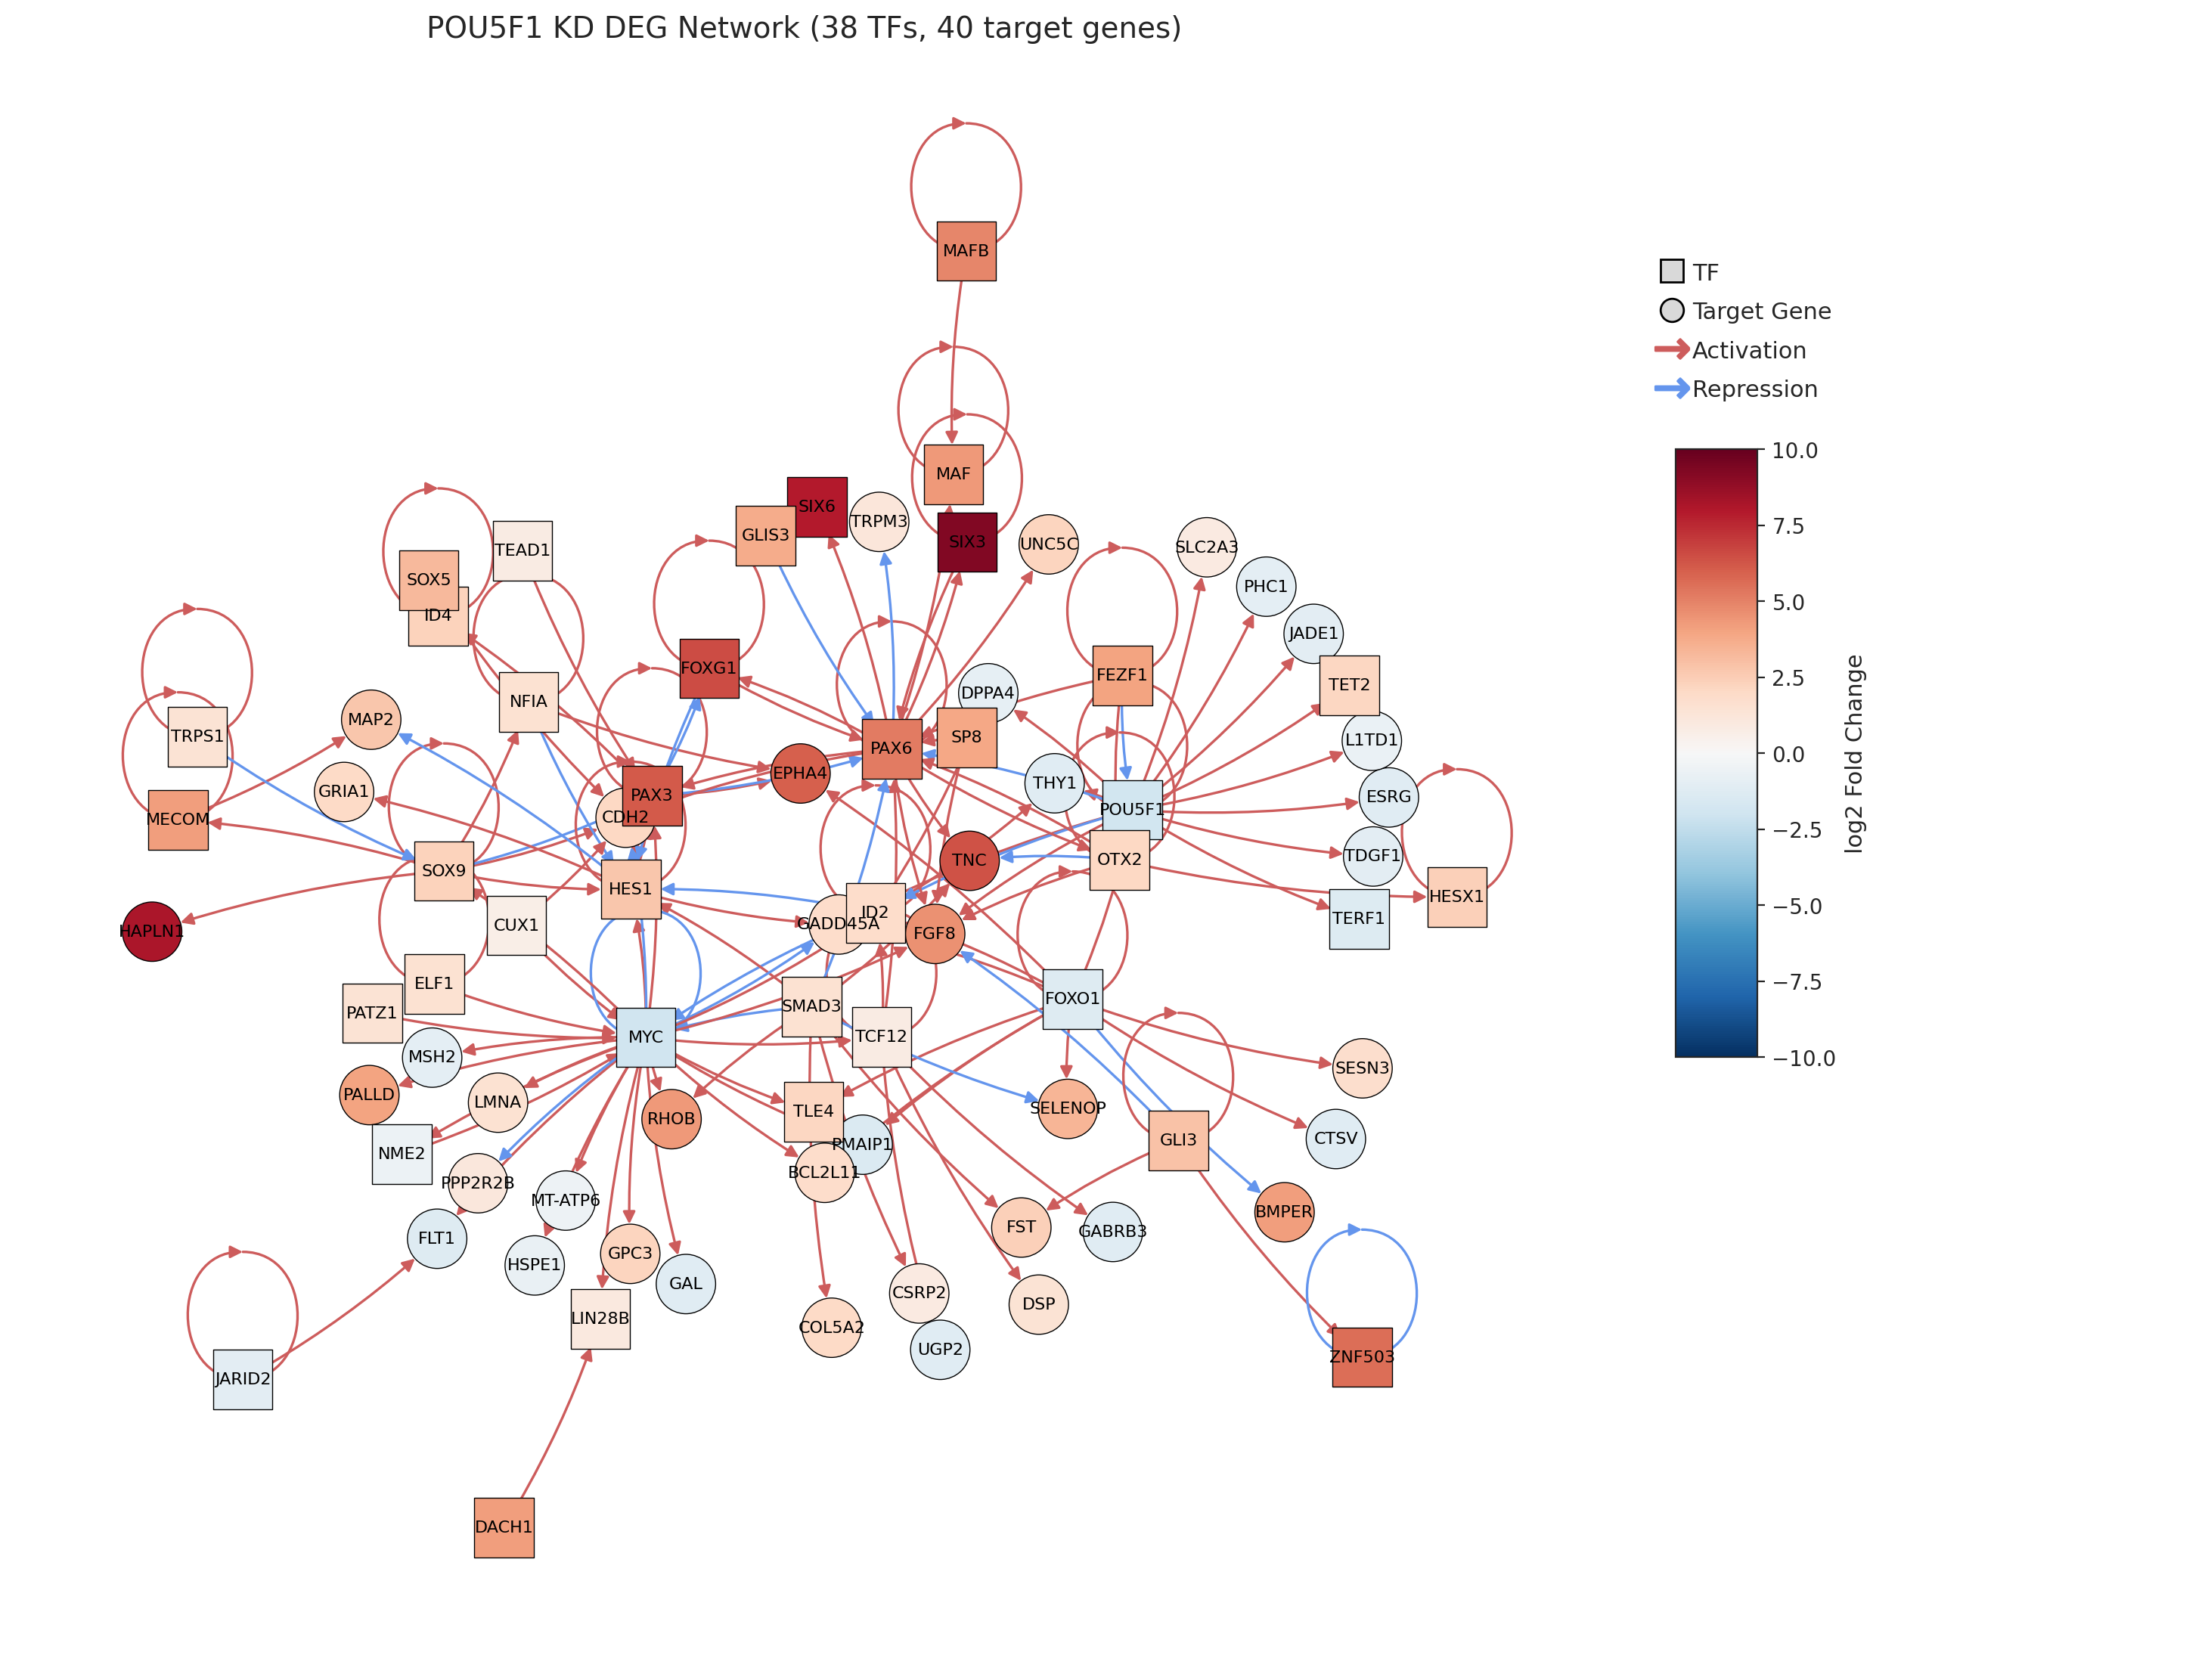

In [ ]:
_, _, pou5f1_ntwk = plot_grn("POU5F1", lfc_df=kolf_deg_lfcs, grn_df=collectri, tfs=lambert_tfs,
                             genes="connected", figsize=(18,12), colorbar_scale=0.5,
                             exclude={'TFAP2C', 'SOX6', 'HMGA2', 'GRHL2', 'ZFHX3', 'NRG1', 'DNMT3B'})

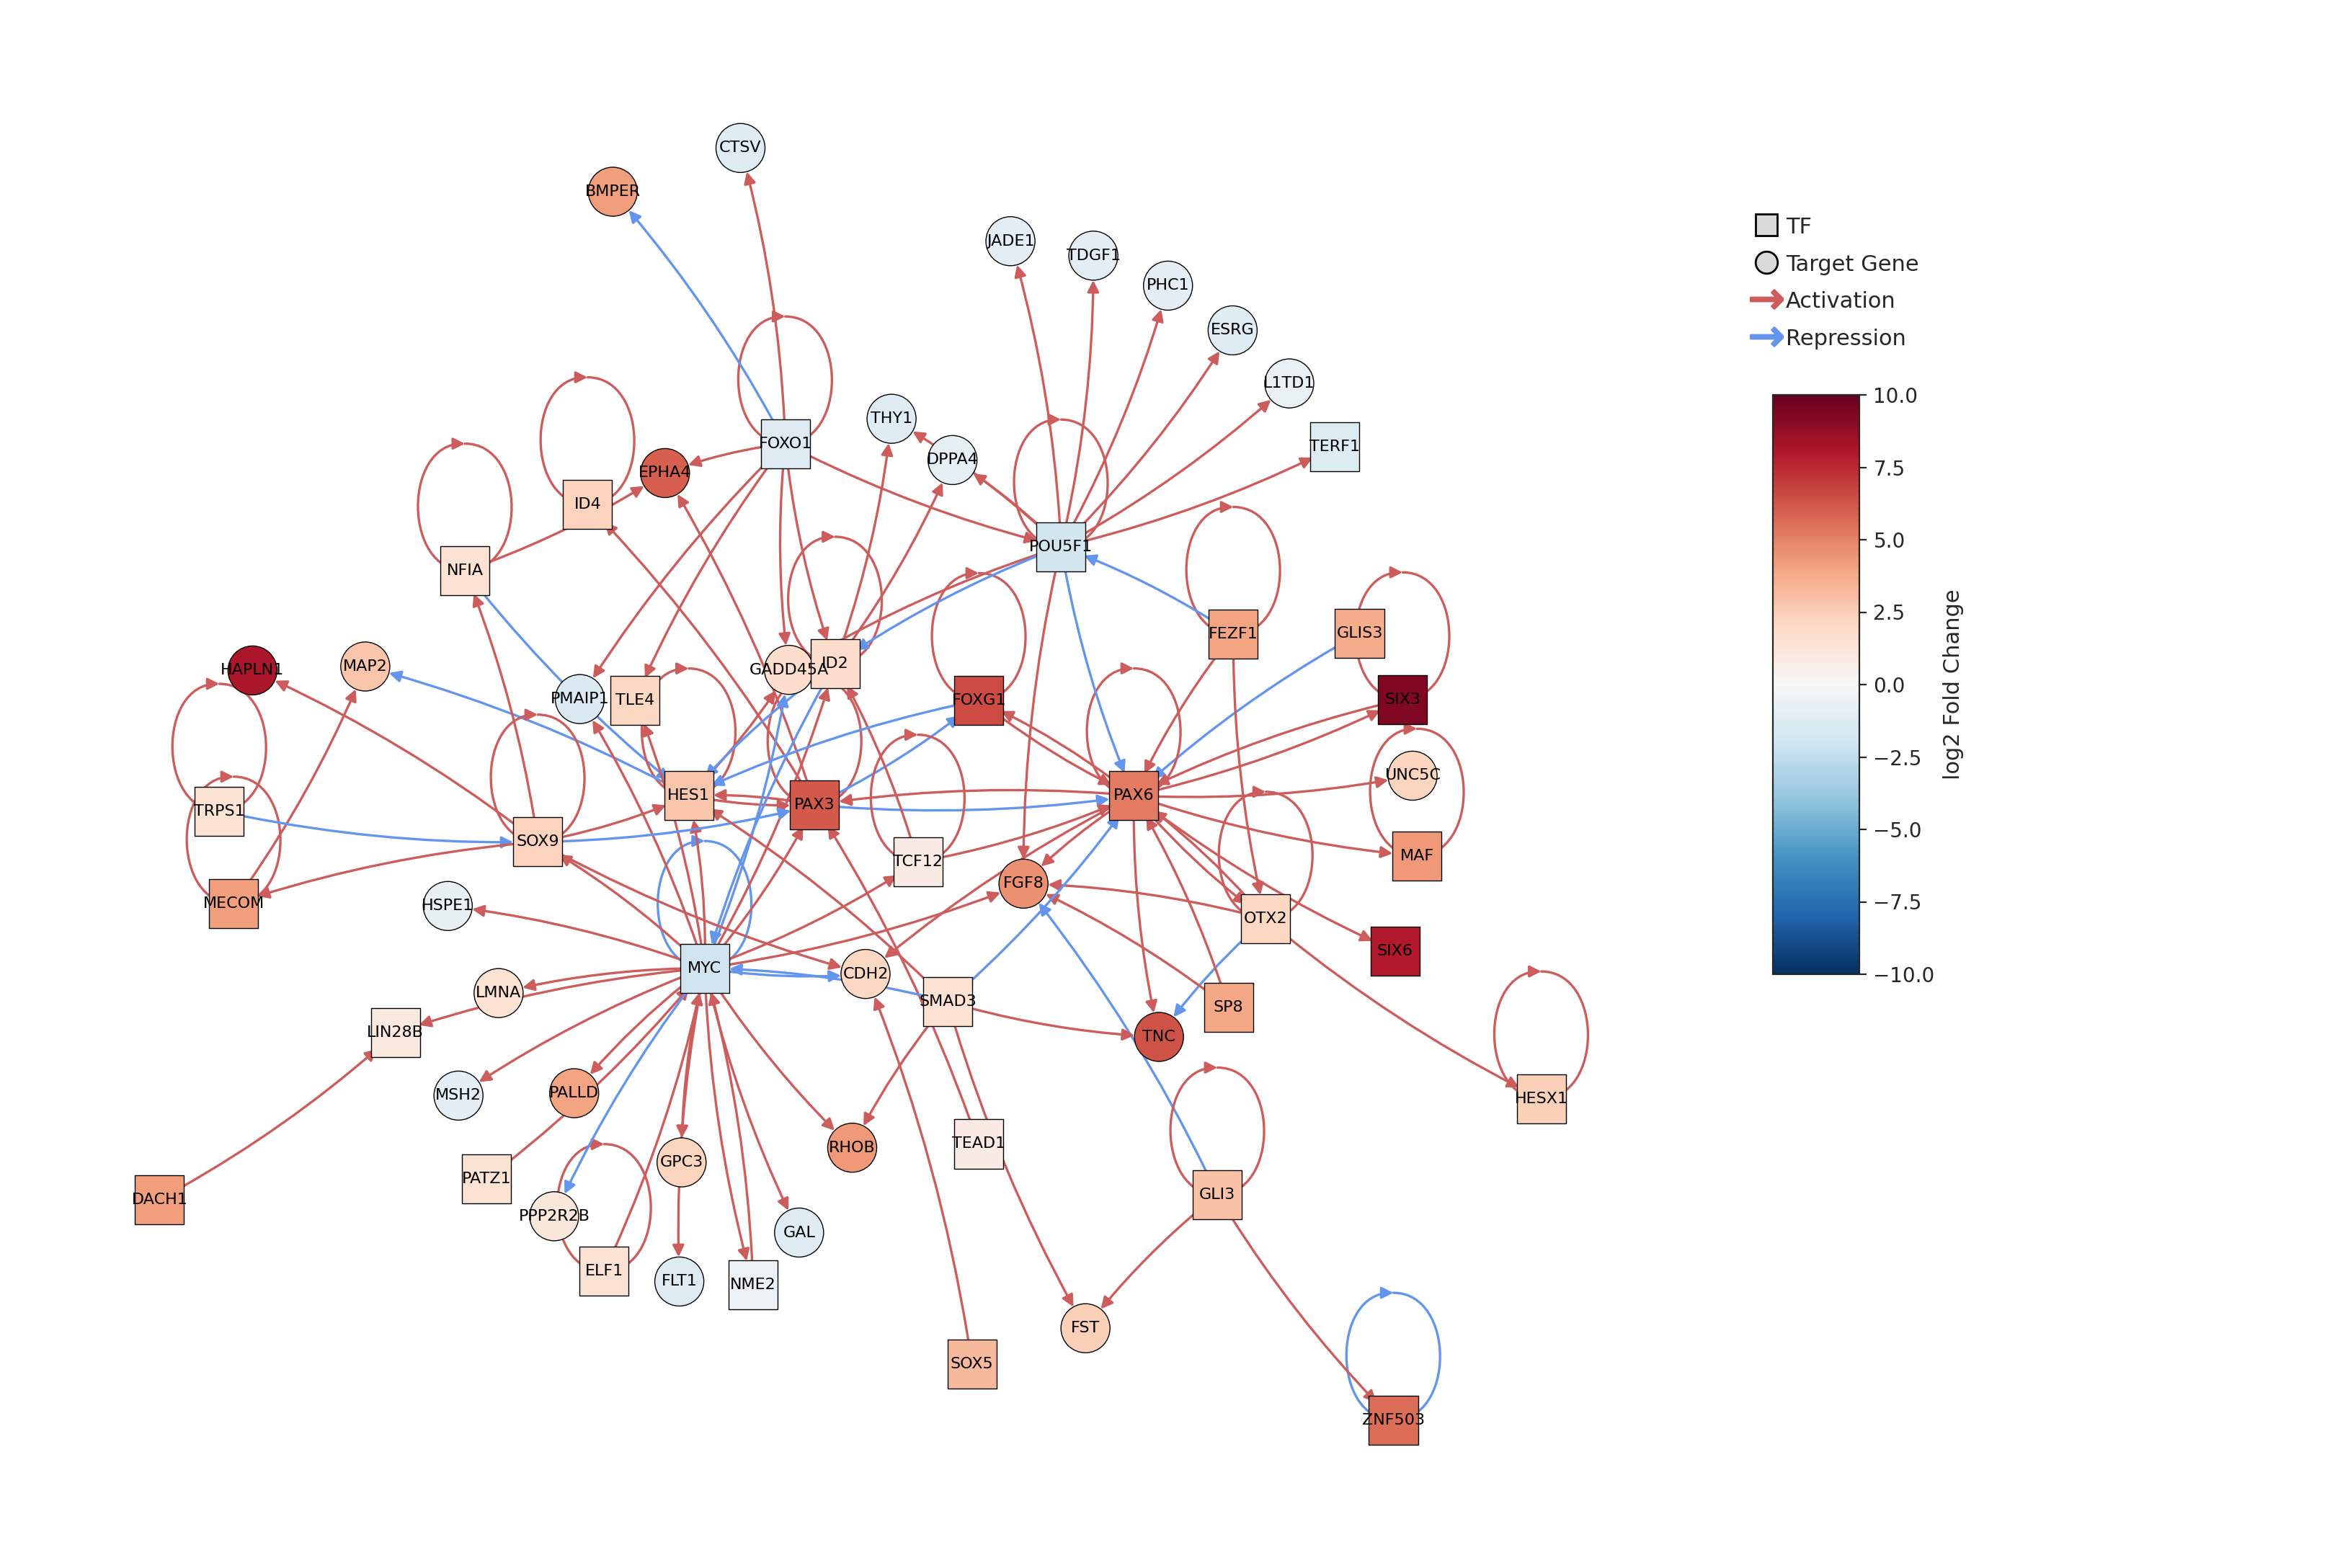

In [58]:
pou5f1_kd_hub_degs = \
    ['GPC3', # General development
     'SIX3', 'SIX6', 'HESX1', # Ectoderm
     'FEZF1', 'MAP2', 'DACH1', # Neural
     'EPHA4', # Axon guidance, synapse formation
     'SOX5', 'HAPLN1', # Skeletal + brain or nervous system development (neuroecto- and mesoderm)
     'POU5F1', 'ESRG', 'TERF1', # Pluripotency
     'PAX6', 'PAX3', 'SOX9', 'GLI3', 'MECOM', 'MYC', # Enriched TFs that are DEGs
     'FOXO1', 'OTX2'] # Other TFs
pou5f1_kd_degs_exclude = {'TFAP2C', 'SOX6', 'HMGA2', 'GRHL2', 'ZFHX3', 'NRG1', 'DNMT3B', 'TET2', 'SLC2A3', 'TRPM3',
                          'BCL2L11', 'MT-ATP6', 'SELENOP', 'CUX1', 'SESN3'}
_, _, pou5f1_ntwk = plot_grn("POU5F1", lfc_df=kolf_deg_lfcs, grn_df=collectri, tfs=lambert_tfs,
                             figsize=(20,12), hubs=pou5f1_kd_hub_degs, colorbar_scale=0.5, node_size=600,
                             exclude=pou5f1_kd_degs_exclude, title="",
                             save_path="/home/ranwyl/figures_tf_project/kolf_pou5f1_kd_deg_network_hubs.png",
                             save_format="png", dpi=300)
# 34 TFs, 28 target genes

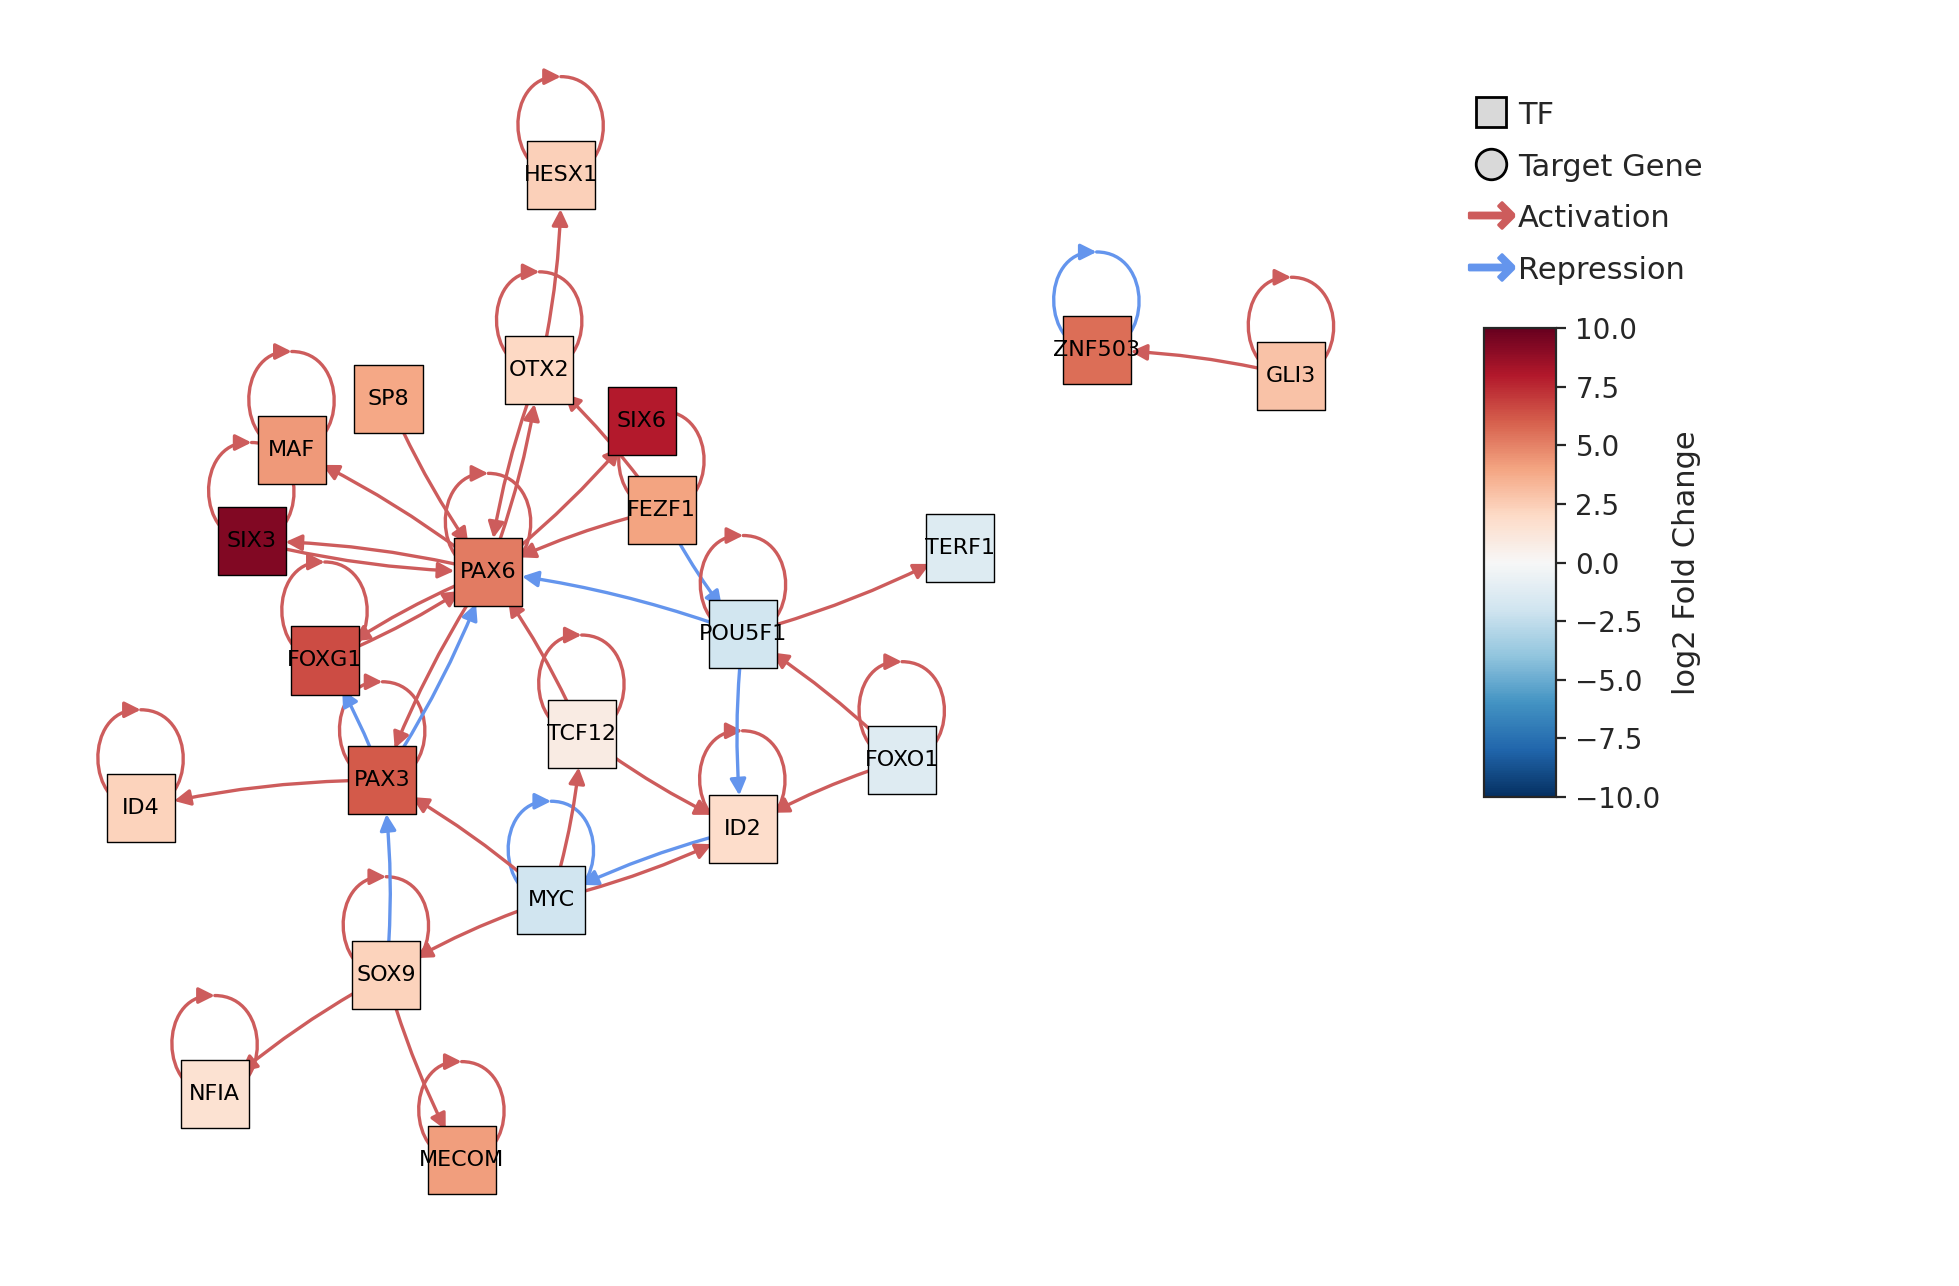

In [63]:
pou5f1_kd_tf_degs = \
     ['SIX3', 'SIX6', 'HESX1', 'FEZF1', 'POU5F1', 'TERF1', 'PAX6', 'PAX3', 'SOX9', 
      'FOXO1', 'OTX2', 'MAF', 'SP8', 'TCF12', 'FOXG1', 'NFIA', 'MECOM',
      'ID2', 'ID4', 'GLI3', 'ZNF503', 'MYC']
_, _, pou5f1_ntwk = plot_grn("POU5F1", lfc_df=kolf_deg_lfcs, grn_df=collectri, tfs=lambert_tfs,
                             figsize=(12,7), genes=pou5f1_kd_tf_degs, colorbar_scale=0.5, node_size=600,
                             exclude=pou5f1_kd_degs_exclude, title="",
                             save_path="/home/ranwyl/figures_tf_project/kolf_pou5f1_kd_deg_network_tfs.png",
                             save_format="png", dpi=300)
# 22 TFs

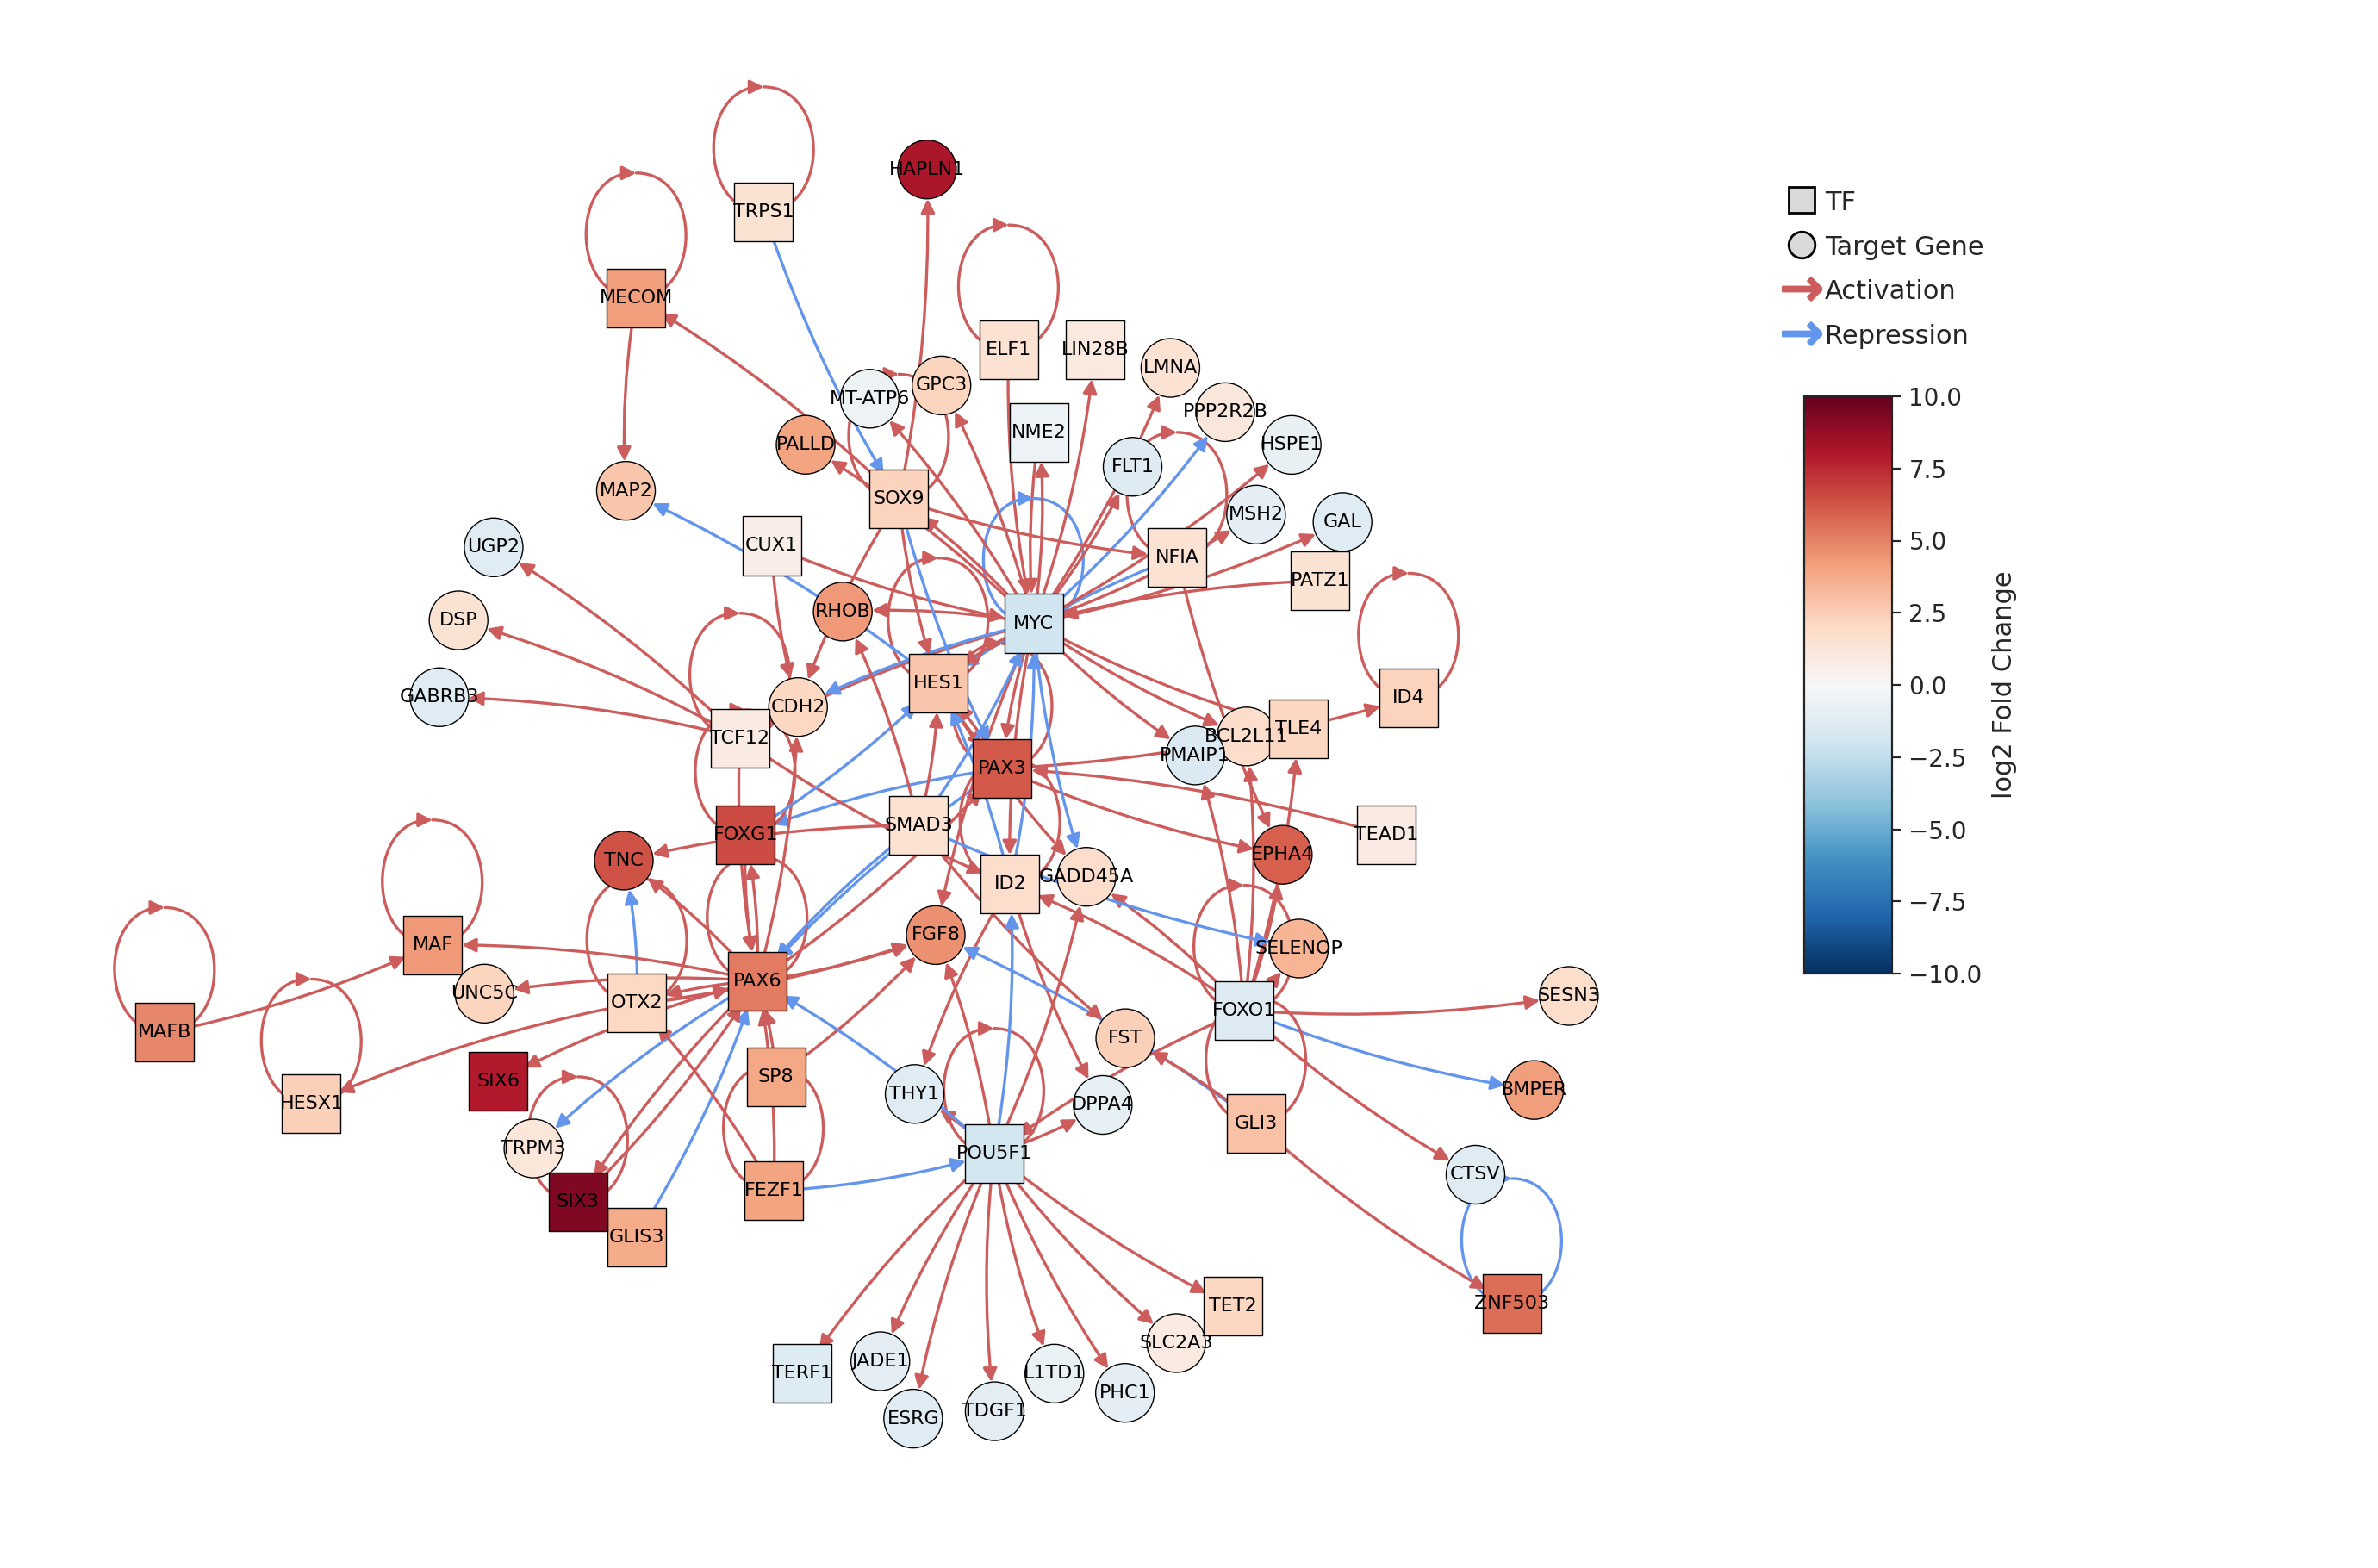

In [66]:
# pou5f1_kd_tf_degs = \
#      ['SIX3', 'SIX6', 'HESX1', 'FEZF1', 'POU5F1', 'TERF1', 'PAX6', 'PAX3', 'SOX9', 
#       'MYC', 'FOXO1', 'OTX2', 'MAF', 'SP8', 'ID4', 'ID2', 'TCF12', 'TLE4',
#       'FOXG1', 'MECOM', 'GLIS3', 'SMAD3']
_, _, pou5f1_ntwk = plot_grn("POU5F1", lfc_df=kolf_deg_lfcs, grn_df=collectri, tfs=lambert_tfs,
                             figsize=(17,10), hubs=pou5f1_kd_tf_degs, colorbar_scale=0.5, node_size=600,
                             title="", save_path="/home/ranwyl/figures_tf_project/kolf_pou5f1_kd_deg_network_tfs_genes.png",
                             save_format="png", dpi=300
                             )
# 35 TFs, 37 genes

## ChIP expts

In [ ]:
pou5f1_kd_kolf_up_degs = kd_deg_dict_kolf_self_degs_direction["POU5F1"]["UP"]
pou5f1_kd_kolf_down_degs = kd_deg_dict_kolf_self_degs_direction["POU5F1"]["DOWN"]
pou5f1_kd_kolf_degs = pou5f1_kd_kolf_up_degs | pou5f1_kd_kolf_down_degs
print(f"{len(pou5f1_kd_kolf_degs)} KOLF hiPSC POU5F1 KD DEGs")

418 KOLF hiPSC POU5F1 KD DEGs


POU5F1 H1 hESC ChIP-seq

In [ ]:
print([expt for expt in encode2014 if "POU5F1" in expt])

['POU5F1 H1']


In [ ]:
pou5f1_h1_hesc_chip_seq_targets = set(encode2014['POU5F1 H1'])
print(f"{len(pou5f1_h1_hesc_chip_seq_targets)} H1 hESC POU5F1 ChIP-seq targets")

89 H1 hESC POU5F1 ChIP-seq targets


In [ ]:
print(f"Intersection of KOLF hiPSC POU5F1 KD DEGs and H1 hESC POU5F1 ChIP-seq binding targets: "
      f"{len((pou5f1_h1_hesc_chip_seq_targets & pou5f1_kd_kolf_degs))} genes")

Intersection of KOLF hiPSC POU5F1 KD DEGs and H1 hESC POU5F1 ChIP-seq binding targets: 4 genes


In [ ]:
print(f"Intersection of POU5F1 up DEGs and ChIP-seq binding targets: "
      f"{', '.join(sorted(list(pou5f1_h1_hesc_chip_seq_targets & pou5f1_kd_kolf_up_degs)))}")
print(f"Intersection of POU5F1 down DEGs and ChIP-seq binding targets: "
      f"{', '.join(sorted(list(pou5f1_h1_hesc_chip_seq_targets & pou5f1_kd_kolf_down_degs)))}")

Intersection of POU5F1 up DEGs and ChIP-seq binding targets: SSBP2
Intersection of POU5F1 down DEGs and ChIP-seq binding targets: DPPA4, PAK1IP1, ZNF589


H9 hESC ChIP-chip (Boyer et al. 2010)

In [ ]:
print([expt for expt in chea if ("POU5F1" in expt) & ("Human" in expt)])

['POU5F1 16153702 ChIP-ChIP HESCs Human']


In [ ]:
pou5f1_h9_hesc_chip_chip_targets = set(chea['POU5F1 16153702 ChIP-ChIP HESCs Human'])
print(f"{len(pou5f1_h9_hesc_chip_chip_targets)} H9 hESC POU5F1 ChIP-chip targets")

433 H9 hESC POU5F1 ChIP-chip targets


In [ ]:
print(f"Intersection of KOLF hiPSC POU5F1 KD DEGs and H9 hESC POU5F1 ChIP-chip binding targets: "
      f"{len((pou5f1_h9_hesc_chip_chip_targets & pou5f1_kd_kolf_degs))} genes")

Intersection of KOLF hiPSC POU5F1 KD DEGs and H9 hESC POU5F1 ChIP-chip binding targets: 35 genes


In [ ]:
print(f"POU5F1 up DEGs & ChIP-chip binding targets ({len(pou5f1_h9_hesc_chip_chip_targets & pou5f1_kd_kolf_up_degs)} genes): "
      f"{', '.join(sorted(list(pou5f1_h9_hesc_chip_chip_targets & pou5f1_kd_kolf_up_degs)))}")
print(f"POU5F1 down DEGs & ChIP-chip binding targets ({len(pou5f1_h9_hesc_chip_chip_targets & pou5f1_kd_kolf_down_degs)} genes): "
      f"{', '.join(sorted(list(pou5f1_h9_hesc_chip_chip_targets & pou5f1_kd_kolf_down_degs)))}")

POU5F1 up DEGs & ChIP-chip binding targets (25 genes): BMP7, DACH1, EPHA4, GABRG3, GLI3, GPC3, HESX1, ID2, IL1RAPL1, NEBL, NFIA, PAX6, PDE10A, RGL1, SESN3, SIX6, SOX5, SP8, SSBP2, TCF12, TFAP2C, TNC, TRPS1, YAF2, ZIC1
POU5F1 down DEGs & ChIP-chip binding targets (10 genes): DPPA4, FGFR2, GRID2, JARID2, POLR3G, POU5F1, ROR1, SLC24A2, SNRPN, TDGF1


TF activities/DEGs/binding targets comparison

In [ ]:
pou5f1_kd_tf_acts = tf_acts_df_kds_kolf.loc[["POU5F1 KD"]].dropna(axis=1)
pou5f1_kd_enriched_tfs = set(pou5f1_kd_tf_acts.columns)
pou5f1_kd_up_tfs = set(pou5f1_kd_tf_acts[pou5f1_kd_tf_acts > 0].dropna(axis=1).columns)
pou5f1_kd_down_tfs = set(pou5f1_kd_tf_acts[pou5f1_kd_tf_acts < 0].dropna(axis=1).columns)
print(f"{len(pou5f1_kd_enriched_tfs)} POU5F1 KD enriched TFs: {len(pou5f1_kd_up_tfs)} up, {len(pou5f1_kd_down_tfs)} down")

34 POU5F1 KD enriched TFs: 22 up, 12 down


In [ ]:
print(f"{len(kd_deg_dict_kolf_self_degs_direction['POU5F1']['UP'] & pou5f1_kd_up_tfs)} POU5F1 KD up TFs are DEGs")
print(', '.join(sorted(list(kd_deg_dict_kolf_self_degs_direction["POU5F1"]["UP"] & pou5f1_kd_up_tfs))))

8 POU5F1 KD up TFs are DEGs
FEZF1, GLI3, GRHL2, MECOM, PAX6, SIX3, SOX9, TFAP2C


In [ ]:
print(f"{len(kd_deg_dict_kolf_self_degs_direction['POU5F1']['DOWN'] & pou5f1_kd_down_tfs)} POU5F1 KD down TFs are DEGs")
print(', '.join(sorted(list(kd_deg_dict_kolf_self_degs_direction["POU5F1"]["DOWN"] & pou5f1_kd_down_tfs))))

2 POU5F1 KD down TFs are DEGs
MYC, POU5F1


In [ ]:
print(f"Intersection of POU5F1 KD enriched TFs and DEGs: {len(pou5f1_kd_kolf_degs & pou5f1_kd_enriched_tfs)} TFs")
print(', '.join(sorted(list((pou5f1_kd_kolf_degs & pou5f1_kd_enriched_tfs)))))

Intersection of POU5F1 KD enriched TFs and DEGs: 10 TFs
FEZF1, GLI3, GRHL2, MECOM, MYC, PAX6, POU5F1, SIX3, SOX9, TFAP2C


In [ ]:
print(f"Intersection of KOLF POU5F1 KD DEGs, KOLF POU5F1 KD enriched TFs, and H9 hESC POU5F1 ChIP-chip binding targets: "
      f"{len(pou5f1_kd_kolf_degs & pou5f1_kd_enriched_tfs & pou5f1_h9_hesc_chip_chip_targets)} TFs")
print(', '.join(sorted(list((pou5f1_kd_kolf_degs & pou5f1_kd_enriched_tfs & pou5f1_h9_hesc_chip_chip_targets)))))

Intersection of KOLF POU5F1 KD DEGs, KOLF POU5F1 KD enriched TFs, and H9 hESC POU5F1 ChIP-chip binding targets: 4 TFs
GLI3, PAX6, POU5F1, TFAP2C


# NANOG KD

## DEGs

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


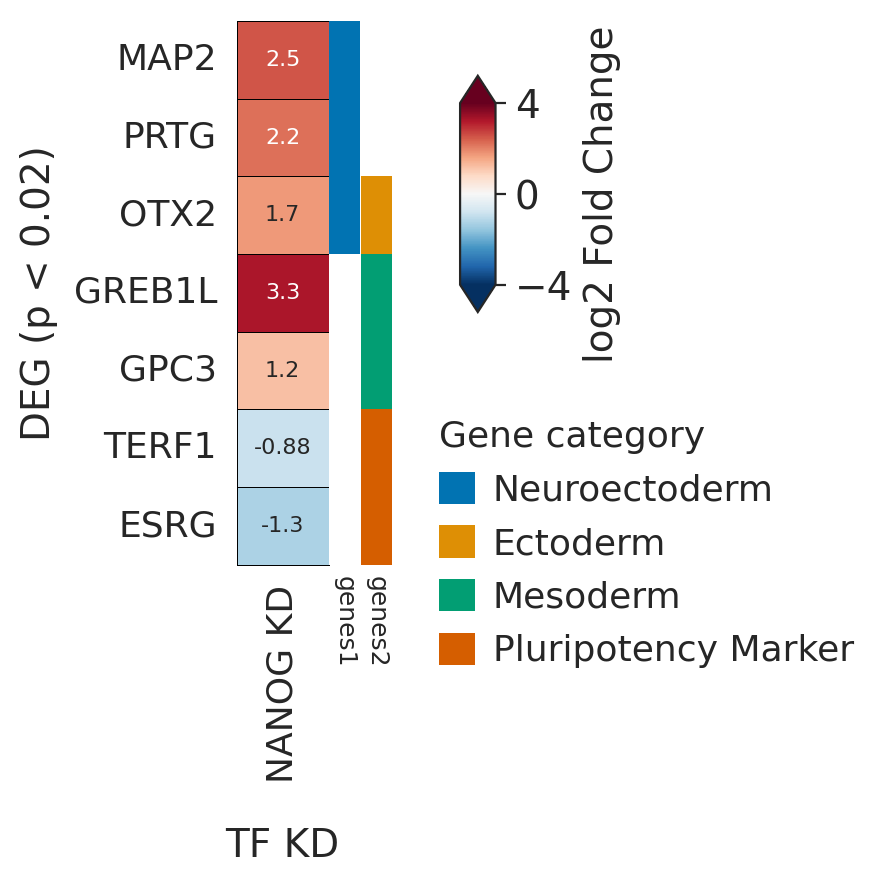

In [40]:
nanog_degs = ['MAP2', 'PRTG', 'OTX2', 'GREB1L', 'GPC3', 'TERF1', 'ESRG']
nanog_deg_annots = {'Neuroectoderm': ['MAP2', 'PRTG', 'OTX2'], 
                    'Ectoderm': ['OTX2'], 'Mesoderm': ['GREB1L', 'GPC3'], 
                    'Pluripotency Marker': ['TERF1', 'ESRG']}
_ = plot_DEG_LFC_heatmap(kolf_deg_lfcs, kds=['NANOG'], degs=nanog_degs,
                         ylabel="DEG (p < 0.02)", xlabel="TF KD",
                         annotations_for_bars=nanog_deg_annots, ylabel_pad=60,
                         n_annotation_bars=2, annot_legend_position=(2, 0.3),
                         annotation_bar_1_label="Neuroectoderm",
                         sort_rows=False, figsize=(1,3),
                         save_path="/home/ranwyl/figures_tf_project/kolf_nanog_kd_degs.png")

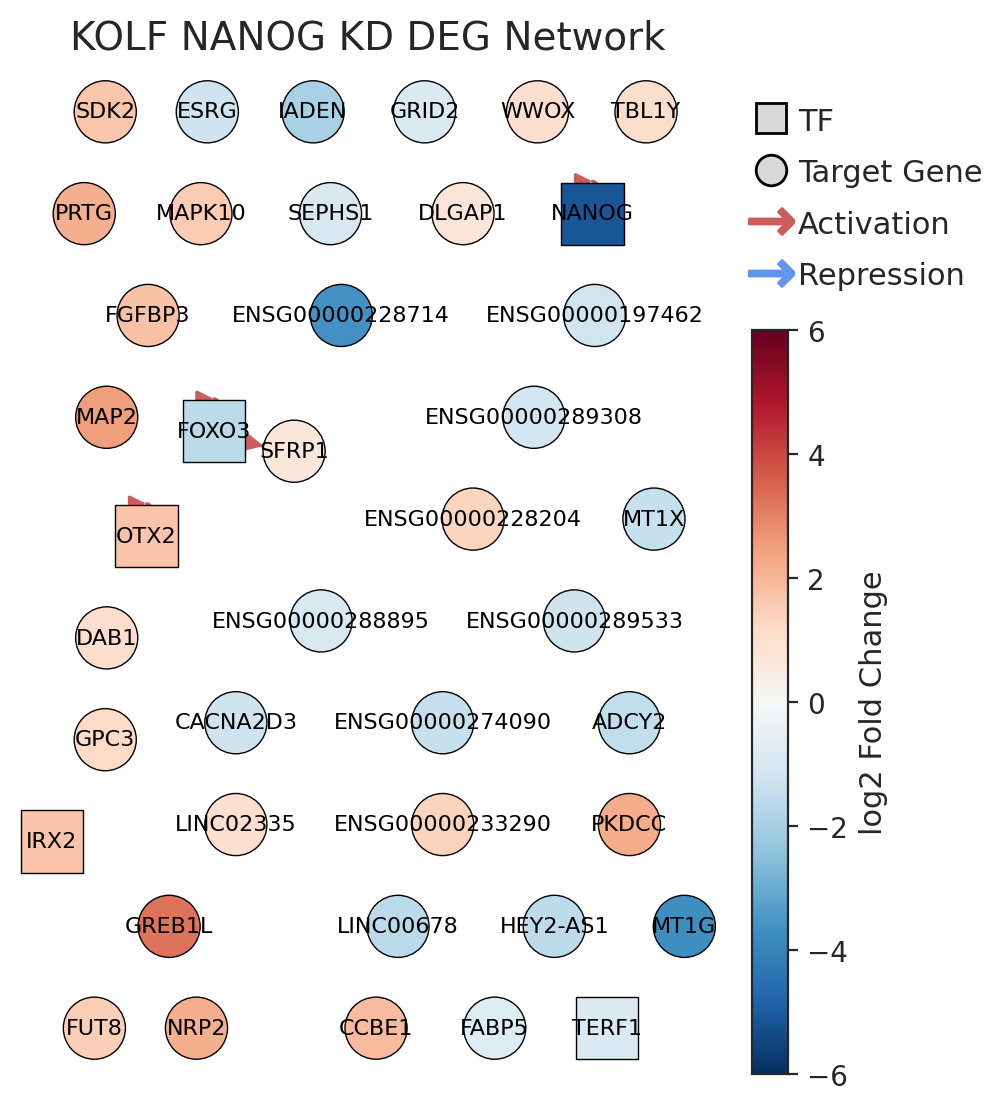

In [37]:
_ = plot_grn("NANOG", lfc_df=kolf_deg_lfcs, grn_df=collectri, genes="all", figsize=(6,6),
            tfs=lambert_tfs, title="KOLF NANOG KD DEG Network", node_size=500, network_top_position=0.9)

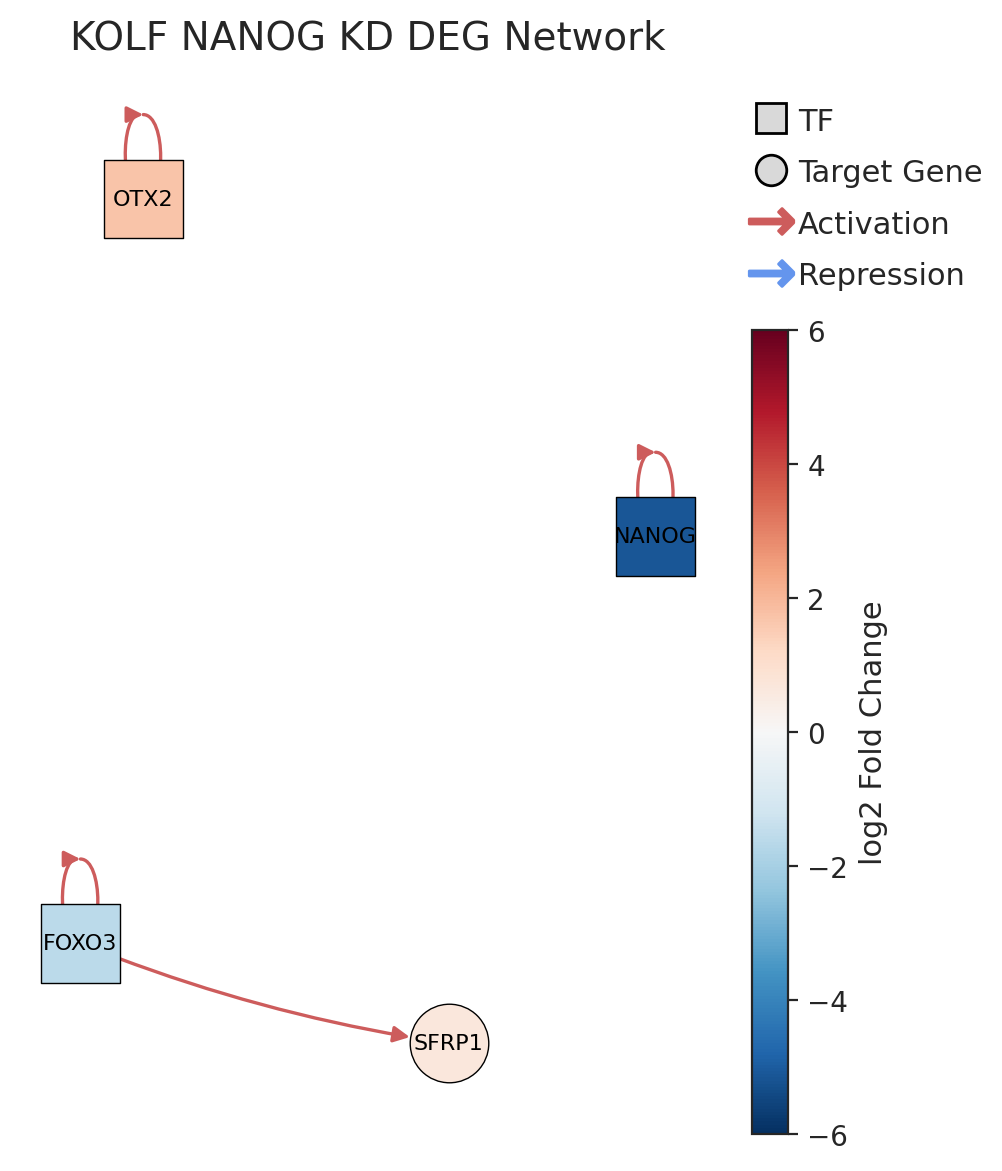

In [38]:
_ = plot_grn("NANOG", lfc_df=kolf_deg_lfcs, grn_df=collectri, genes="connected", figsize=(6,6),
            tfs=lambert_tfs, title="KOLF NANOG KD DEG Network")

## ChIP expts

In [ ]:
nanog_kd_kolf_up_degs = kd_deg_dict_kolf_self_degs_direction["NANOG"]["UP"]
nanog_kd_kolf_down_degs = kd_deg_dict_kolf_self_degs_direction["NANOG"]["DOWN"]
nanog_kd_kolf_degs = nanog_kd_kolf_up_degs | nanog_kd_kolf_down_degs
print(f"{len(nanog_kd_kolf_degs)} KOLF hiPSC NANOG KD DEGs")

41 KOLF hiPSC NANOG KD DEGs


In [ ]:
print(', '.join(sorted(list(nanog_kd_kolf_degs))))

ADCY2, CACNA2D3, CCBE1, DAB1, DLGAP1, ENSG00000197462, ENSG00000228204, ENSG00000228714, ENSG00000233290, ENSG00000274090, ENSG00000288895, ENSG00000289308, ENSG00000289533, ESRG, FABP5, FGFBP3, FOXO3, FUT8, GPC3, GREB1L, GRID2, HEY2-AS1, IADEN, IRX2, LINC00678, LINC02335, MAP2, MAPK10, MT1G, MT1X, NANOG, NRP2, OTX2, PKDCC, PRTG, SDK2, SEPHS1, SFRP1, TBL1Y, TERF1, WWOX


In [ ]:
print([expt for expt in encode2015 if "NANOG" in expt])

['NANOG H1-hESC hg19']


In [ ]:
print([expt for expt in chea if ("NANOG" in expt) & ("Human" in expt)])

['NANOG 21062744 ChIP-ChIP HESCs Human', 'NANOG 16153702 ChIP-ChIP HESCs Human', 'NANOG 19829295 ChIP-Seq ESCs Human', 'NANOG 20526341 ChIP-Seq ESCs Human']


In [ ]:
nanog_h1_hesc_targets = set(encode2015['NANOG H1-hESC hg19'])
print(f"{len(nanog_h1_hesc_targets)} H1 hESC NANOG ChIP-seq targets")

113 H1 hESC NANOG ChIP-seq targets


In [ ]:
print(f"Intersection of KOLF NANOG KD DEGs and hESC NANOG ChIP-seq targets: "
      f"{len((nanog_hesc_targets & nanog_kd_kolf_degs))} genes")

Intersection of KOLF NANOG KD DEGs and hESC NANOG ChIP-seq targets: 1 genes


In [ ]:
print(nanog_hesc_targets & nanog_kd_kolf_degs)

{'ESRG'}


In [ ]:
nanog_hesc_targets_chea_1 = set(chea['NANOG 19829295 ChIP-Seq ESCs Human'])
print(f"{len(nanog_hesc_targets_chea_1)} hESC NANOG ChIP-seq targets (expt 19829295)")

1584 hESC NANOG ChIP-seq targets (expt 19829295)


In [ ]:
print(f"Intersection of KOLF NANOG KD DEGs and hESC NANOG ChIP-seq targets (expt 19829295): "
      f"{len((nanog_hesc_targets_chea_1 & nanog_kd_kolf_degs))} genes")

Intersection of KOLF NANOG KD DEGs and hESC NANOG ChIP-seq targets (expt 19829295): 6 genes


In [ ]:
print(f"Intersection of NANOG up DEGs and ChIP-seq binding targets: "
      f"{', '.join(sorted(list(nanog_hesc_targets_chea_1 & nanog_kd_kolf_up_degs)))}")
print(f"Intersection of NANOG down DEGs and ChIP-seq binding targets: "
      f"{', '.join(sorted(list(nanog_hesc_targets_chea_1 & nanog_kd_kolf_down_degs)))}")

Intersection of NANOG up DEGs and ChIP-seq binding targets: FGFBP3, GREB1L, SDK2
Intersection of NANOG down DEGs and ChIP-seq binding targets: MT1G, NANOG, SEPHS1


In [ ]:
nanog_hesc_targets_chea_2 = set(chea['NANOG 20526341 ChIP-Seq ESCs Human'])
print(f"{len(nanog_hesc_targets_chea_2)} hESC NANOG ChIP-seq targets (expt 20526341)")

1579 hESC NANOG ChIP-seq targets (expt 20526341)


In [ ]:
print(f"Intersection of KOLF NANOG KD DEGs and hESC NANOG ChIP-seq targets (expt 20526341): "
      f"{len((nanog_hesc_targets_chea_2 & nanog_kd_kolf_degs))} genes")

Intersection of KOLF NANOG KD DEGs and hESC NANOG ChIP-seq targets (expt 20526341): 3 genes


In [ ]:
print(f"Intersection of NANOG up DEGs and ChIP-seq binding targets: "
      f"{', '.join(sorted(list(nanog_hesc_targets_chea_2 & nanog_kd_kolf_up_degs)))}")
print(f"Intersection of NANOG down DEGs and ChIP-seq binding targets: "
      f"{', '.join(sorted(list(nanog_hesc_targets_chea_2 & nanog_kd_kolf_down_degs)))}")

Intersection of NANOG up DEGs and ChIP-seq binding targets: PKDCC
Intersection of NANOG down DEGs and ChIP-seq binding targets: GRID2, MT1X


## Comparison to POU5F1

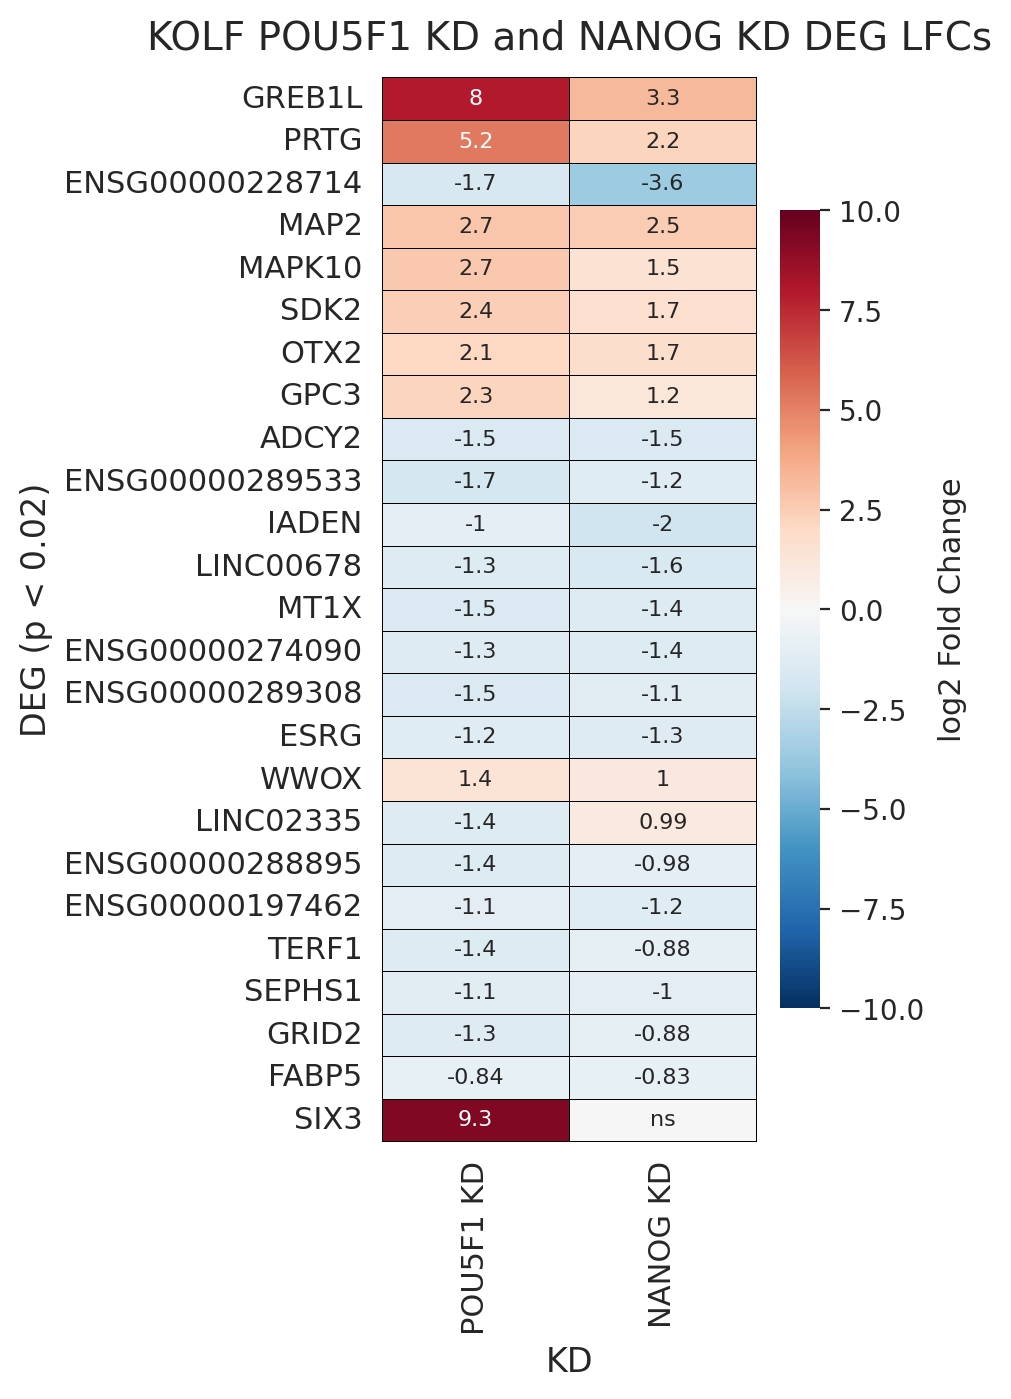

In [39]:
_ = plot_DEG_LFC_heatmap(kolf_deg_lfcs, kds=['POU5F1', 'NANOG'],
                         title="KOLF POU5F1 KD and NANOG KD DEG LFCs",
                         ylabel="DEG (p < 0.02)", top=25, sort_columns=True,
                         figsize=(3,7), cbar_size=0.75)

# POU5F1B KD

## DEGs

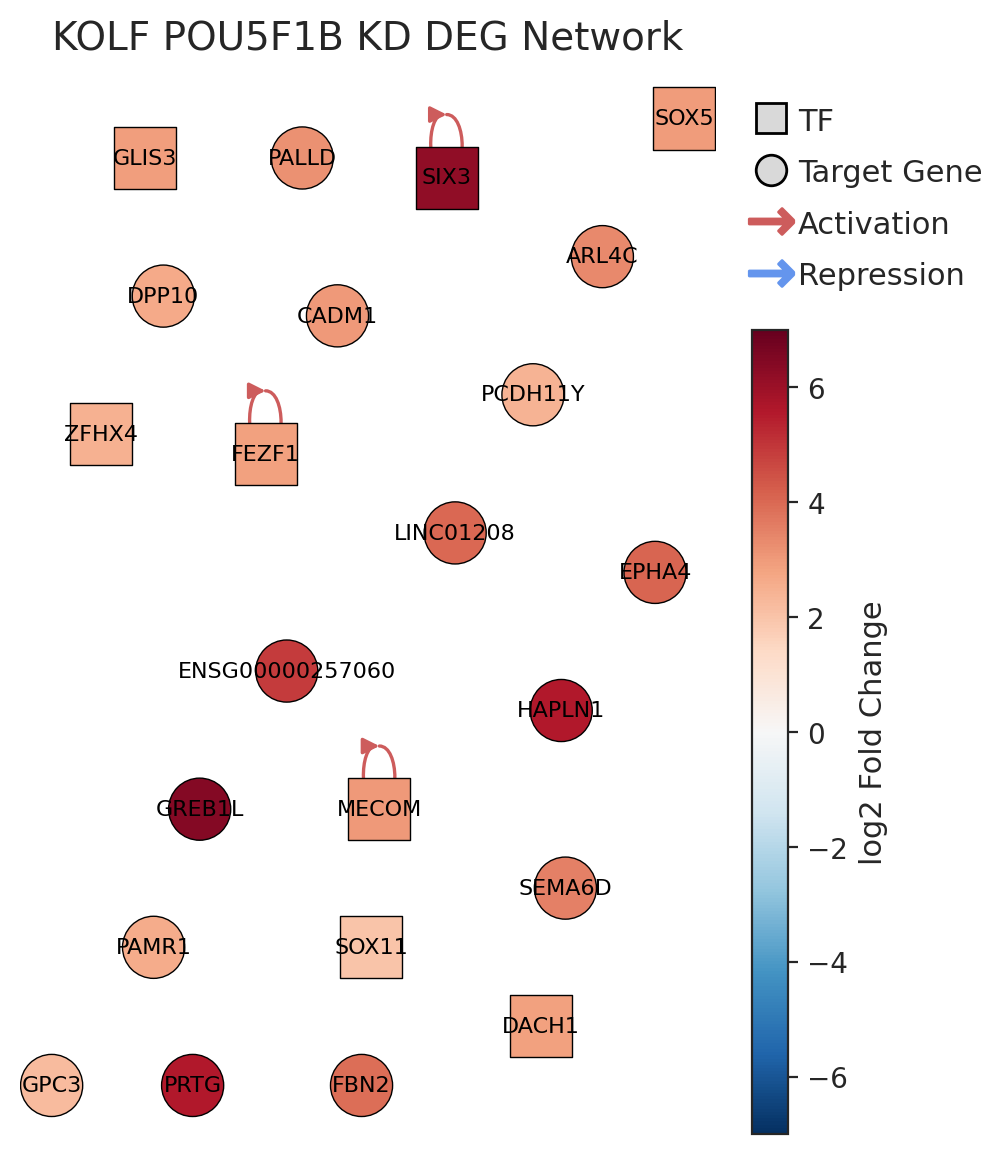

In [34]:
_ = plot_grn("POU5F1B", lfc_df=kolf_deg_lfcs, grn_df=collectri, tfs=lambert_tfs, genes="all", figsize=(6,6), node_size=500,
             title="KOLF POU5F1B KD DEG Network")

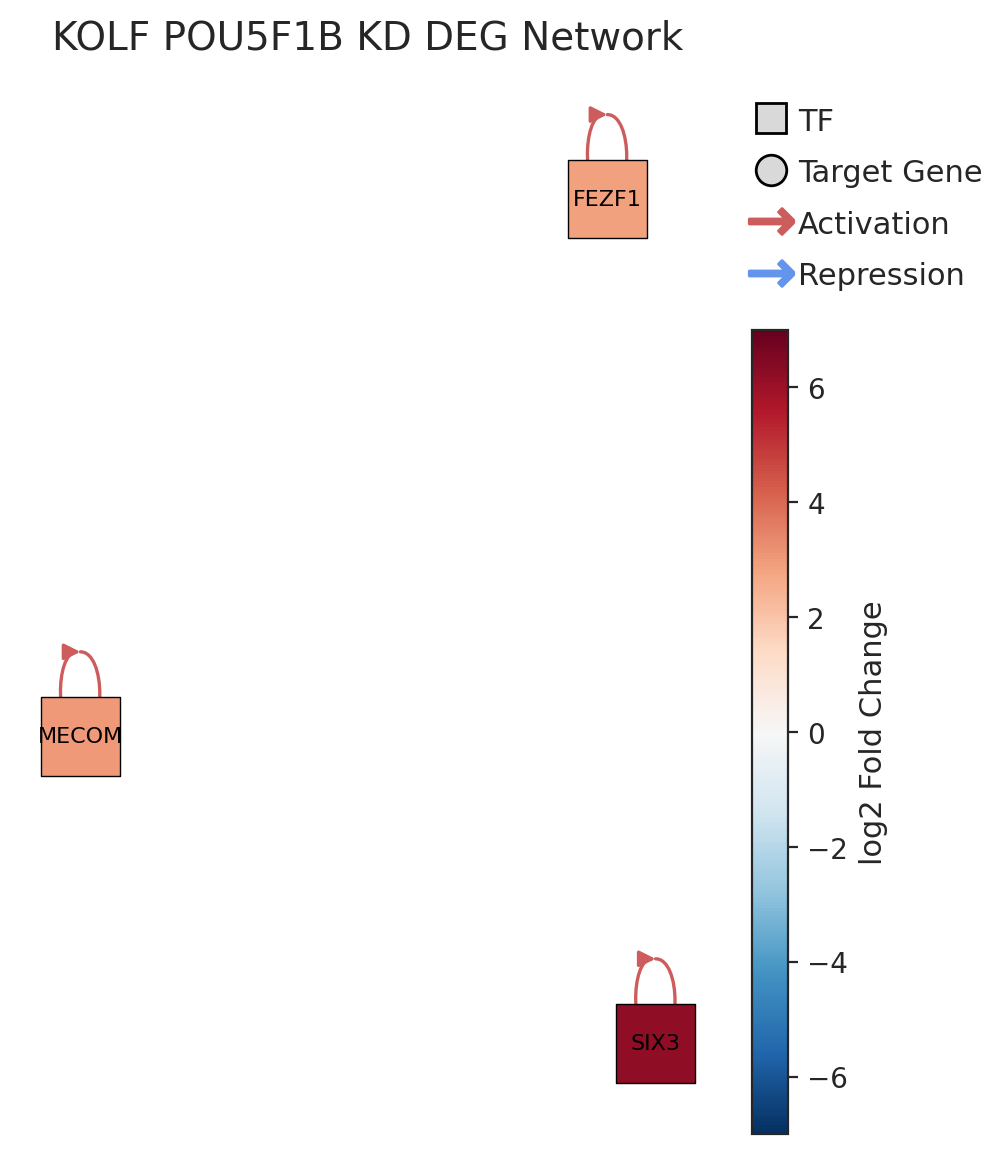

In [35]:
_ = plot_grn("POU5F1B", lfc_df=kolf_deg_lfcs, grn_df=collectri, tfs=lambert_tfs, genes="connected", figsize=(6,6),
             title="KOLF POU5F1B KD DEG Network")

## Comparison to POU5F1

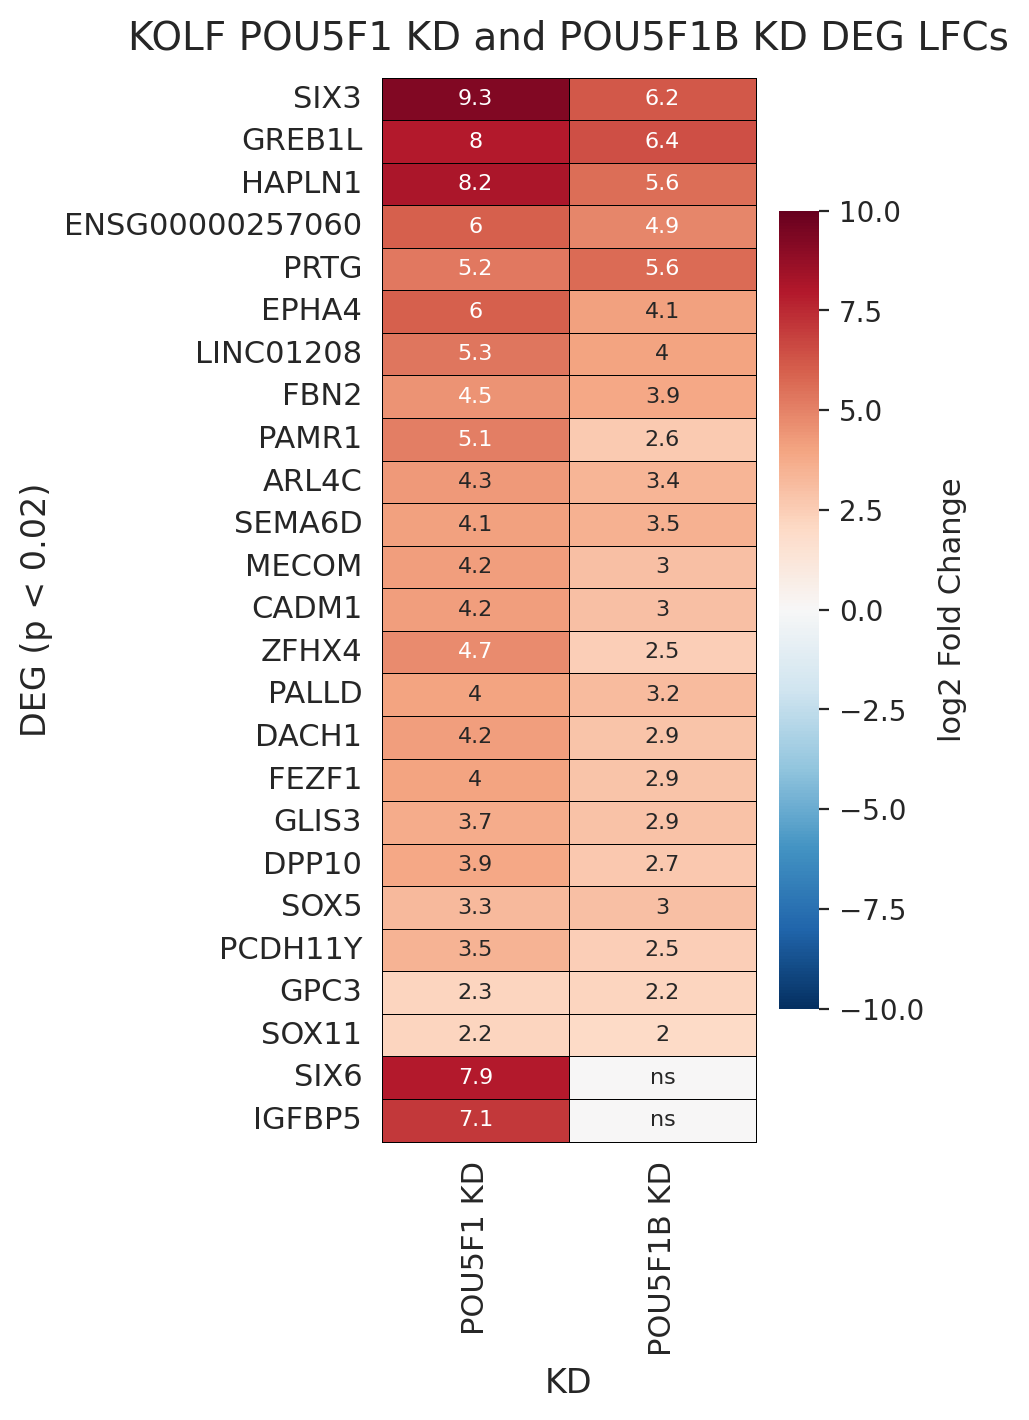

In [96]:
_ = plot_DEG_LFC_heatmap(kolf_deg_lfcs, kds=['POU5F1', 'POU5F1B'],
                         title="KOLF POU5F1 KD and POU5F1B KD DEG LFCs",
                         ylabel="DEG (p < 0.02)", top=25, sort_columns=True,
                         figsize=(3,7), cbar_size=0.75)

In [97]:
plur_gsea = kolf_gsea_enriched[kolf_gsea_enriched["Term"] == "Transcriptional Regulation of Pluripotent Stem Cells"]
with pd.option_context('display.max_colwidth', None):
    display(plur_gsea)

,Cell line,HDBSCAN cluster,Leiden cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,# DE lead genes,# lead genes w/ |Wald| > 1,Tag %,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
358,KOLF2.1J,-1,0,NR5A1,Reactome_Pathways_2024,Transcriptional Regulation of Pluripotent Stem Cells,-0.515823,-1.713774,0.010801,0.032716,0.8396,0,1,11/23,31.69%,POU5F1;SALL1;SOX2;SALL4;DPPA4;EPHA1;NANOG;ZSCAN10;LIN28A;TDGF1;SMAD4,NaN,POU5F1
9875,KOLF2.1J,3,8,POU5F1,Reactome_Pathways_2024,Transcriptional Regulation of Pluripotent Stem Cells,-0.525981,-1.638991,0.017319,0.035023,0.9262,2,7,8/21,8.03%,TDGF1;DPPA4;PRDM14;FGF2;FOXD3;STAT3;NANOG;EPHA1,DPPA4;TDGF1,DPPA4;EPHA1;FGF2;FOXD3;PRDM14;STAT3;TDGF1
10226,KOLF2.1J,3,8,POU5F1B,Reactome_Pathways_2024,Transcriptional Regulation of Pluripotent Stem Cells,-0.510907,-1.711107,0.009576,0.031666,0.7795,0,4,10/22,15.43%,TDGF1;POU5F1;ZSCAN10;NANOG;DPPA4;STAT3;EPHA1;PRDM14;SALL4;FGF2,NaN,NANOG;POU5F1;TDGF1;ZSCAN10


In [111]:
pou5f1_kd_lead_genes_plur = sorted(plur_gsea[(plur_gsea["TF KD"] == "POU5F1")]["Lead_genes"].values[0].split(";"))
print(pou5f1_kd_lead_genes_plur)
pou5f1b_kd_lead_genes_plur = sorted(plur_gsea[(plur_gsea["TF KD"] == "POU5F1B")]["Lead_genes"].values[0].split(";"))
print(pou5f1b_kd_lead_genes_plur)
plur_lead_genes_all = sorted(list(set(pou5f1_kd_lead_genes_plur) | set(pou5f1b_kd_lead_genes_plur)))

['DPPA4', 'EPHA1', 'FGF2', 'FOXD3', 'NANOG', 'PRDM14', 'STAT3', 'TDGF1']
['DPPA4', 'EPHA1', 'FGF2', 'NANOG', 'POU5F1', 'PRDM14', 'SALL4', 'STAT3', 'TDGF1', 'ZSCAN10']


Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


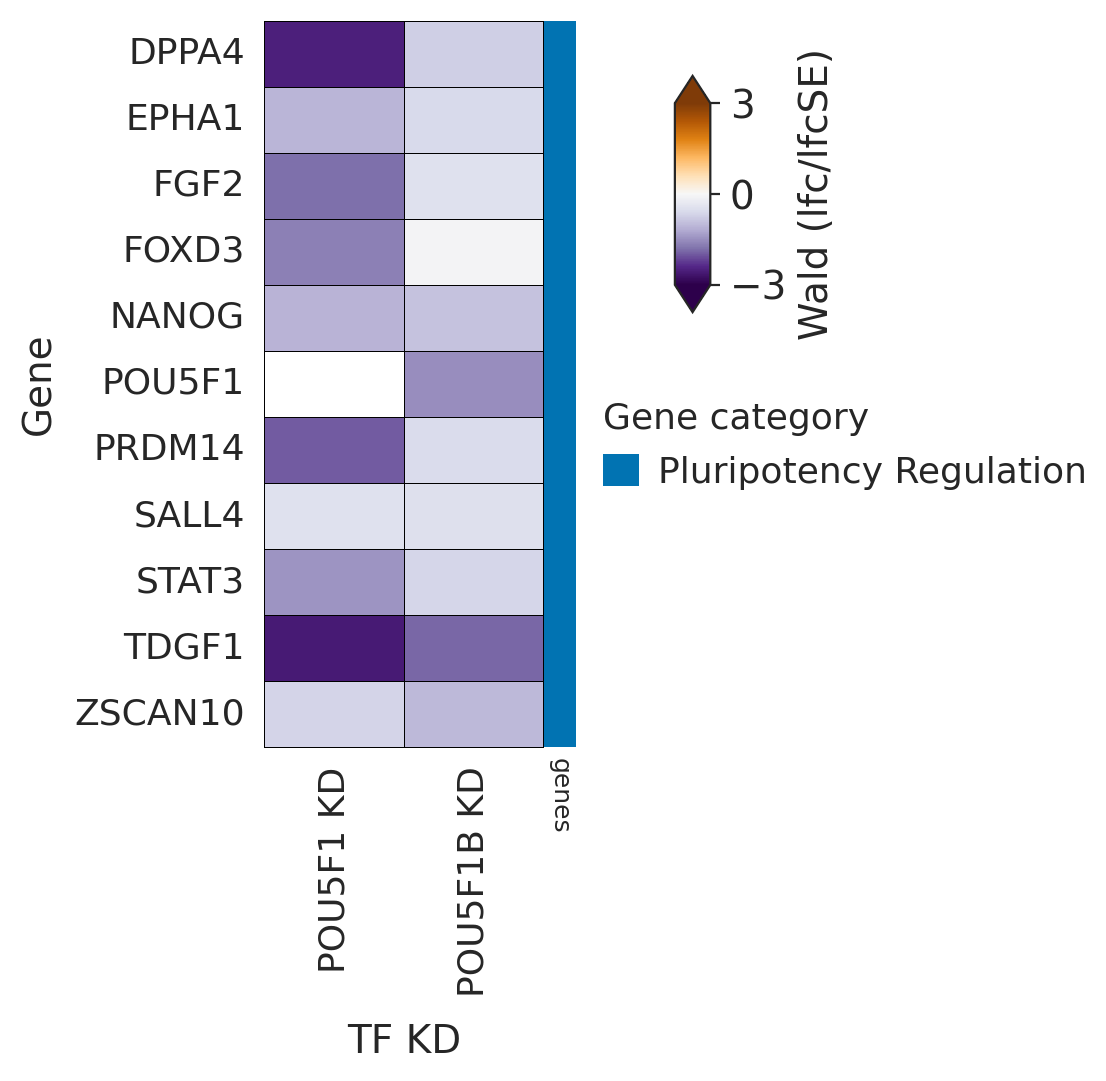

In [119]:
plot_gene_wald_heatmap(wald_df_kds_kolf[wald_df_kds_kolf.index.isin({"POU5F1 KD", "POU5F1B KD"})],
                    xlabel="TF KD", ylabel="Gene", figsize=(2,4),
                    kds=['POU5F1', 'POU5F1B'], cmap="PuOr_r", column_sort_ascending=True,
                    sort_columns=True, genes=plur_lead_genes_all,
                    show_rownames=True, show_colnames=True, show_borders=True,
                    annotations_for_bars={'Pluripotency Regulation': plur_lead_genes_all},
                    annot_legend_position=(1.15, 0.5), xlabel_pad=95, ylabel_pad=70,
                    # save_path="/home/ranwyl/figures_tf_project/kolf_generic_wald.png",
                    # save_format="png", dpi=300
                    )

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


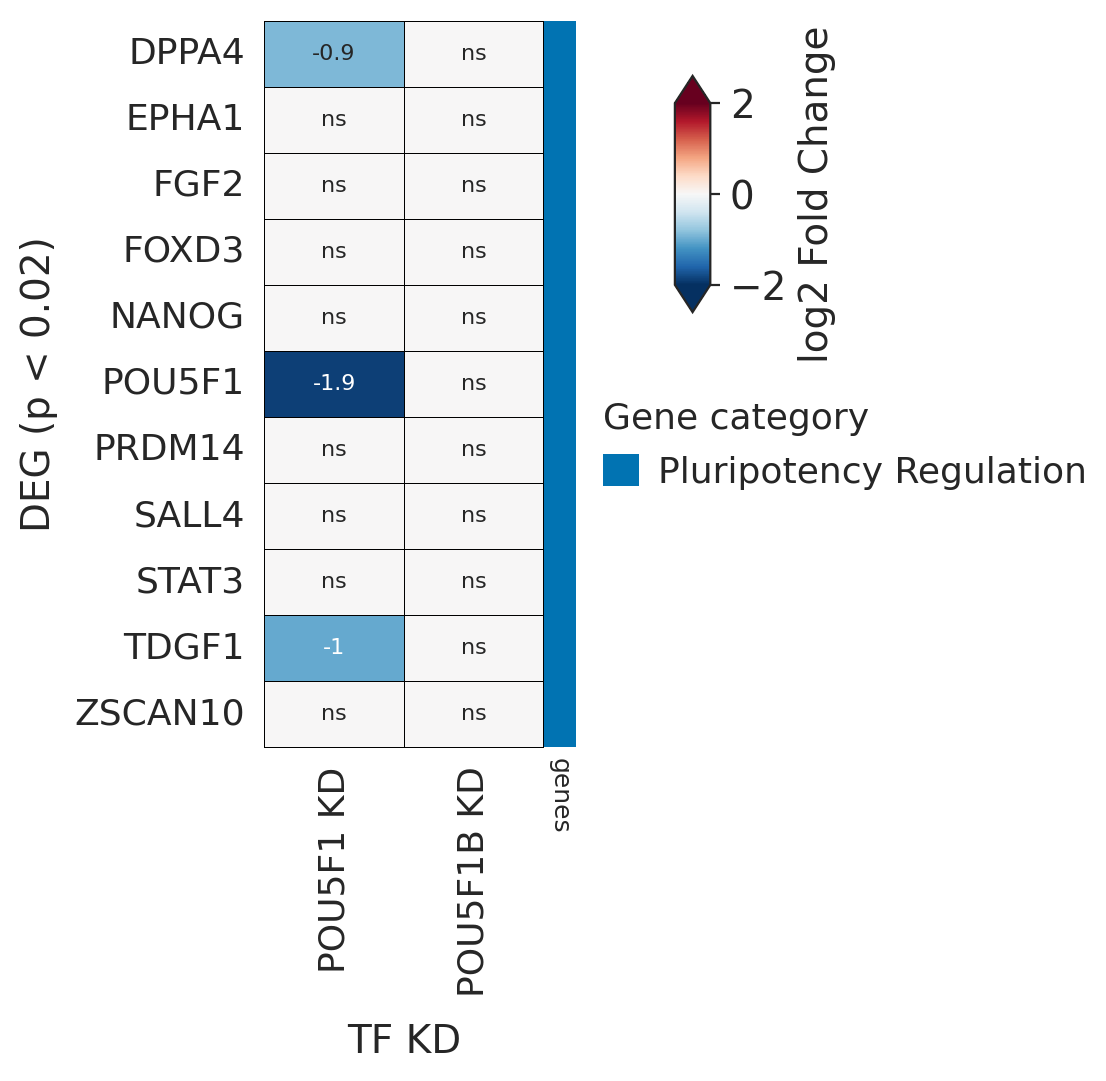

In [120]:
plot_DEG_LFC_heatmap(kolf_deg_lfcs, kds=['POU5F1', 'POU5F1B'], degs=plur_lead_genes_all,
                        ylabel="DEG (p < 0.02)", xlabel="TF KD",
                        annotations_for_bars={'Pluripotency Regulation': plur_lead_genes_all},
                        sort_rows=False, figsize=(2,4),
                        annot_legend_position=(1.15, 0.5), xlabel_pad=95, ylabel_pad=70,
                        #save_path="/home/ranwyl/figures_tf_project/kolf_nanog_kd_degs.png"
                        )

# POU3F2 KD

## DEGs

No edges in DEG GRN

In [ ]:
_ = plot_grn("POU3F2", lfc_df=kolf_deg_lfcs, grn_df=collectri, tfs=lambert_tfs, genes="all", figsize=(6,6), node_size=500,
             title="KOLF POU3F2 KD DEG Network")

# ZNF521 KD

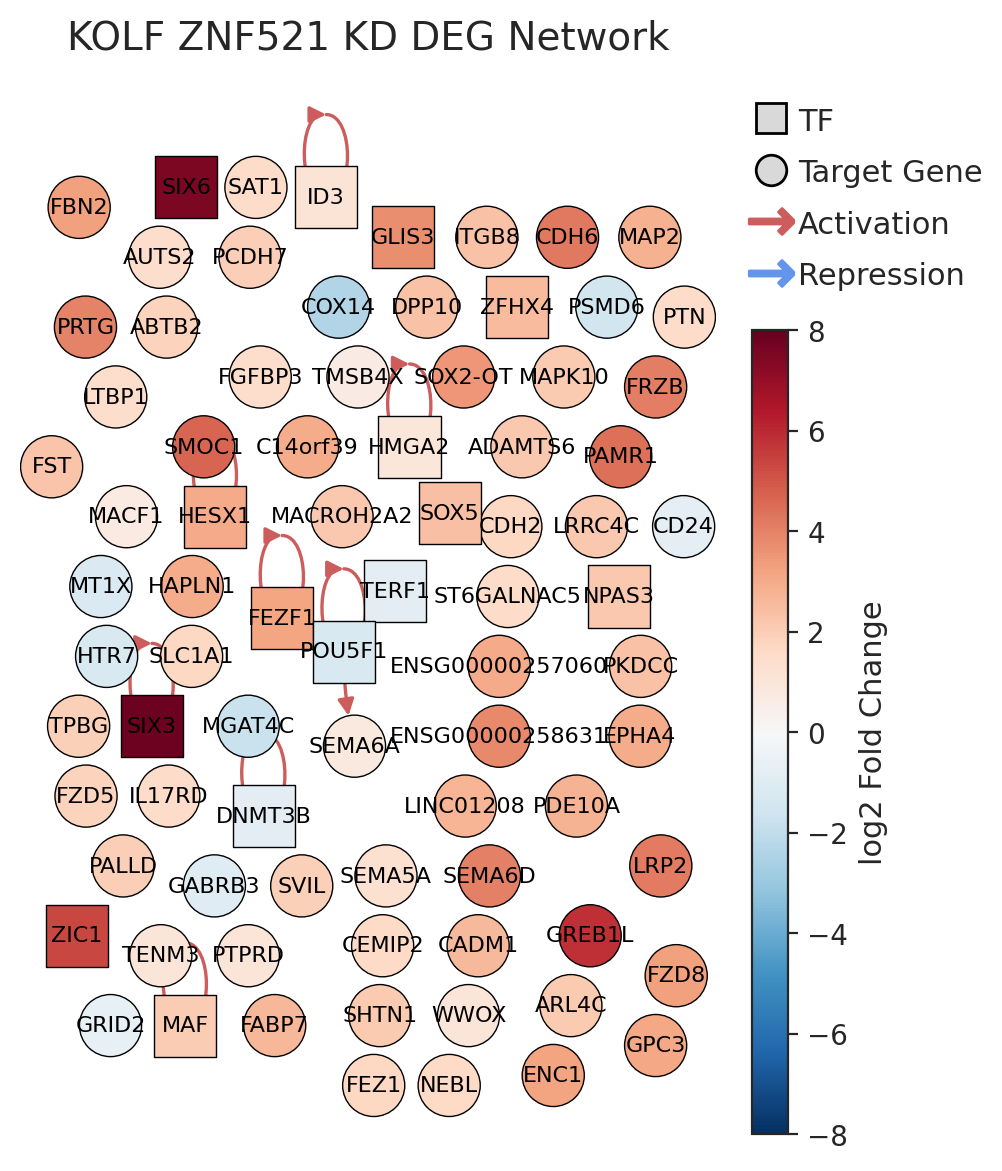

In [32]:
_ = plot_grn("ZNF521", lfc_df=kolf_deg_lfcs, grn_df=collectri, tfs=lambert_tfs, genes="all", figsize=(6,6), node_size=500,
             title="KOLF ZNF521 KD DEG Network")

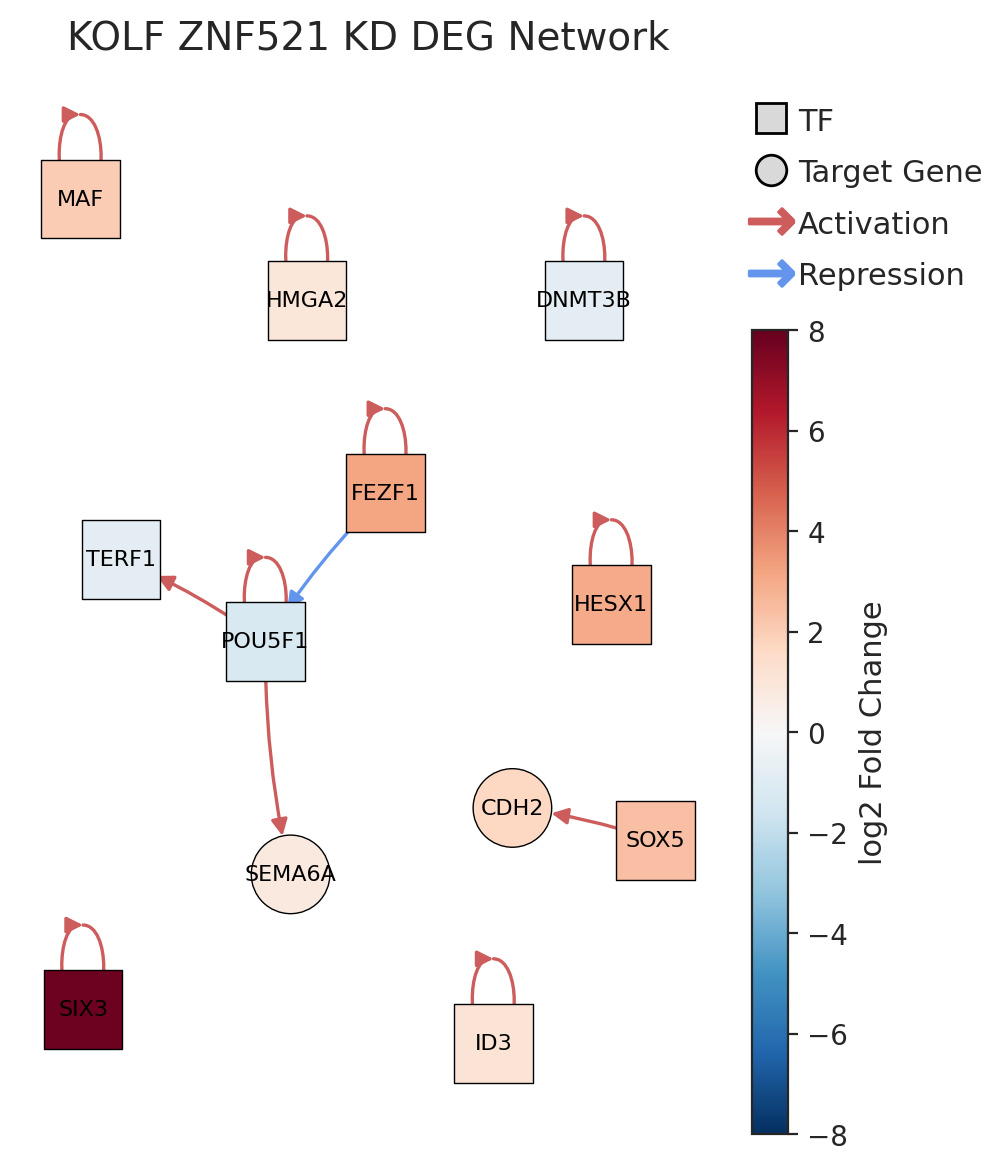

In [33]:
_ = plot_grn("ZNF521", lfc_df=kolf_deg_lfcs, grn_df=collectri, tfs=lambert_tfs, genes="connected", figsize=(6,6),
             title="KOLF ZNF521 KD DEG Network")

# ZNF396 KD

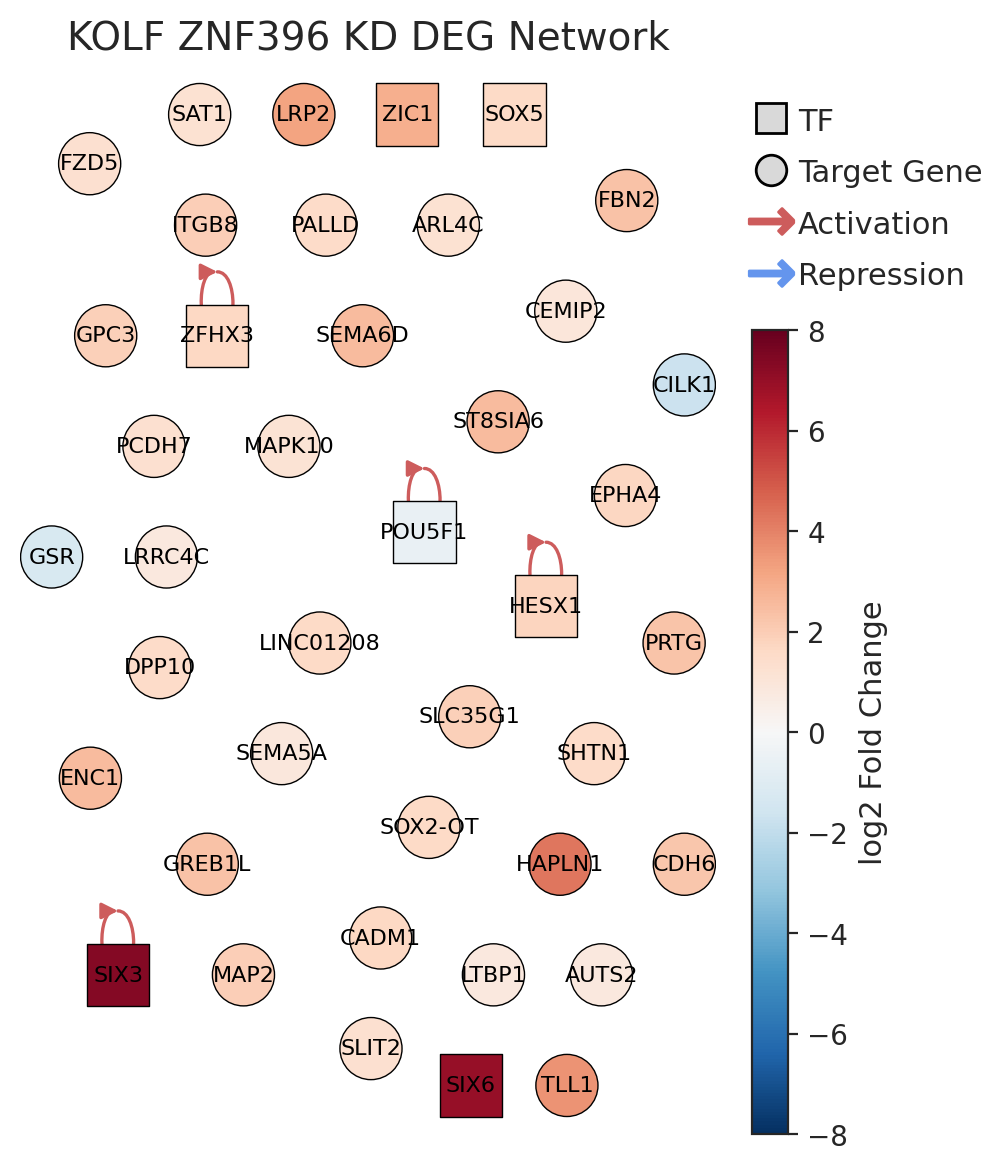

In [30]:
_ = plot_grn("ZNF396", lfc_df=kolf_deg_lfcs, grn_df=collectri, tfs=lambert_tfs, genes="all", figsize=(6,6), node_size=500,
             title="KOLF ZNF396 KD DEG Network")

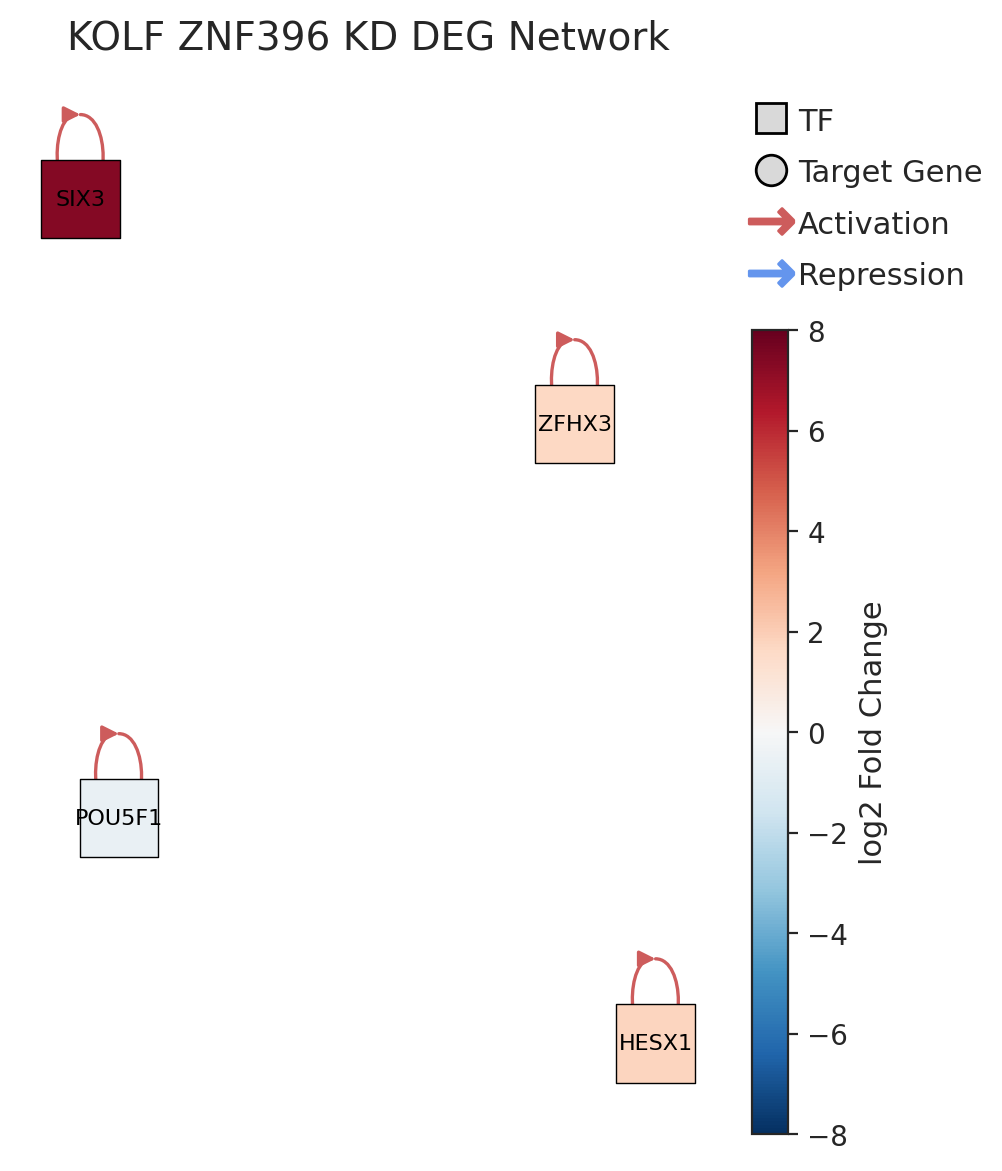

In [31]:
_ = plot_grn("ZNF396", lfc_df=kolf_deg_lfcs, grn_df=collectri, tfs=lambert_tfs, genes="connected", figsize=(6,6),
             title="KOLF ZNF396 KD DEG Network")

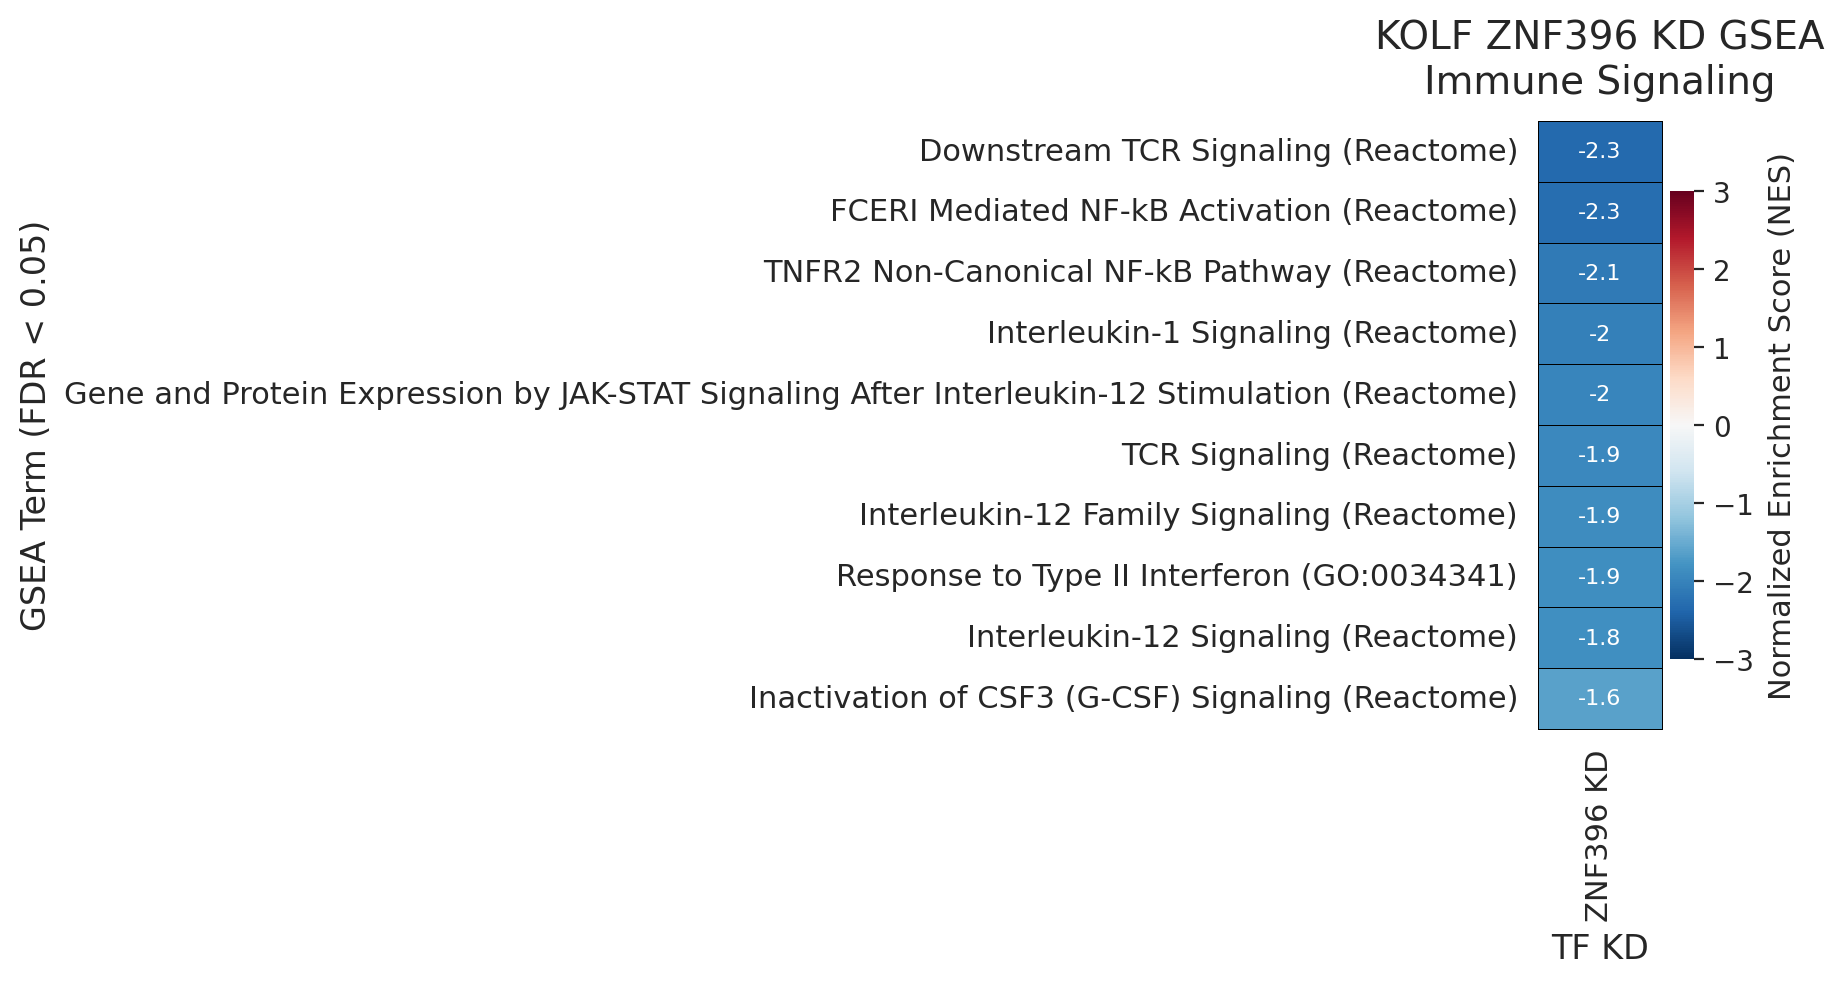

In [ ]:
# Note - no DEG support and under half of leading genes per term have |Wald| > 1
signaling_terms_down = ['TCR Signaling', 'Downstream TCR Signaling',
    'FCERI Mediated NF-kB Activation', 'TNFR2 Non-Canonical NF-kB Pathway',
    'Interleukin-1 Signaling', 'Interleukin-12 Signaling', 
    'Interleukin-12 Family Signaling',  
    'Gene and Protein Expression by JAK-STAT Signaling After Interleukin-12 Stimulation',
    'Response to Type II Interferon (GO:0034341)', 'Inactivation of CSF3 (G-CSF) Signaling',]
_ = plot_gsea_heatmap(kolf_gsea_results, kds=['ZNF396'], 
                    title="KOLF ZNF396 KD GSEA\nImmune Signaling",
                    sort_columns=False, ylabel="GSEA Term (FDR < 0.05)",
                    terms=signaling_terms_down,
                    kd_col="TF KD", xlabel="TF KD", cbar_size=1,
                    figsize=(1,4), cbar_label="Normalized Enrichment Score (NES)")

# PHF20 KD

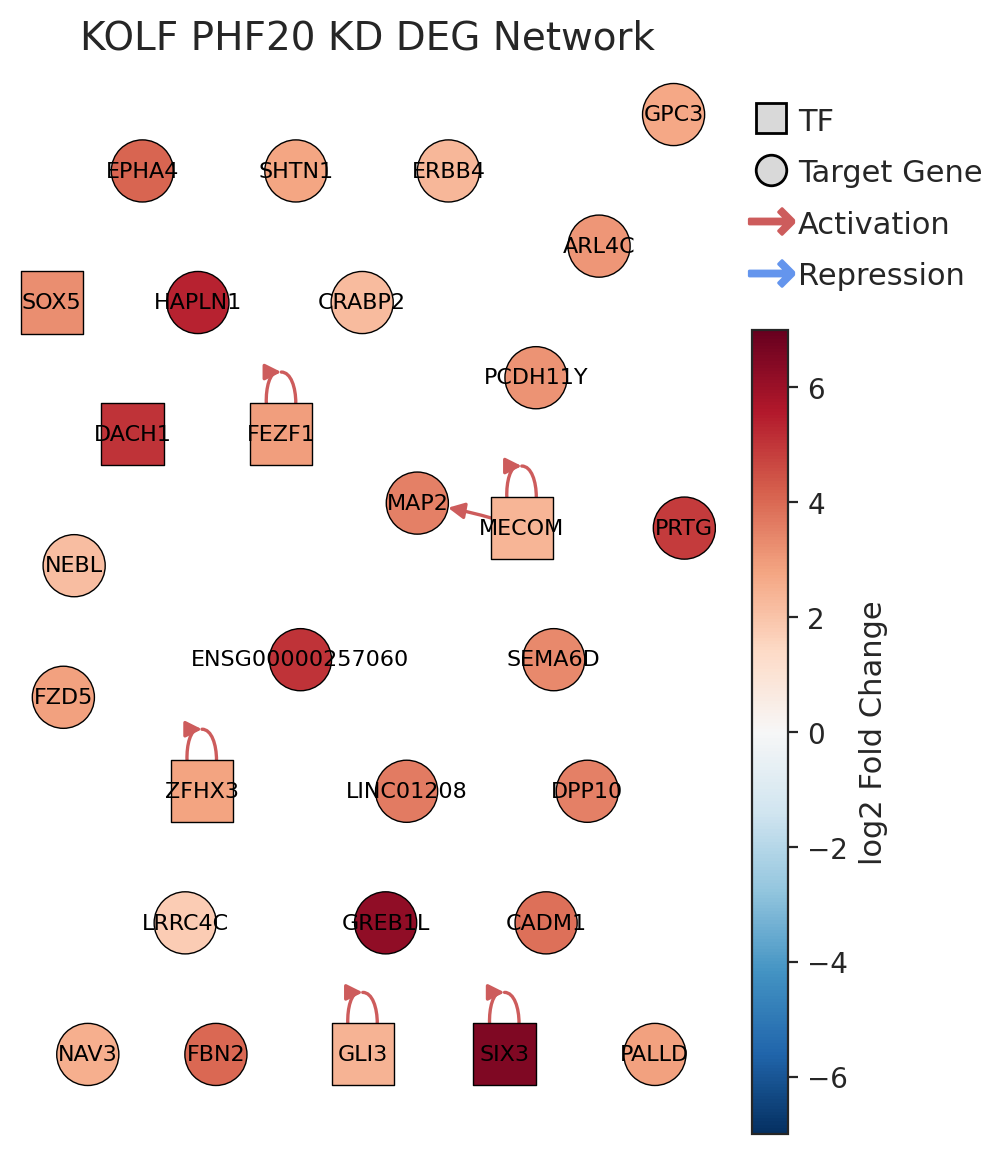

In [28]:
_ = plot_grn("PHF20", lfc_df=kolf_deg_lfcs, grn_df=collectri, tfs=lambert_tfs, genes="all", figsize=(6,6), node_size=500,
             title="KOLF PHF20 KD DEG Network")

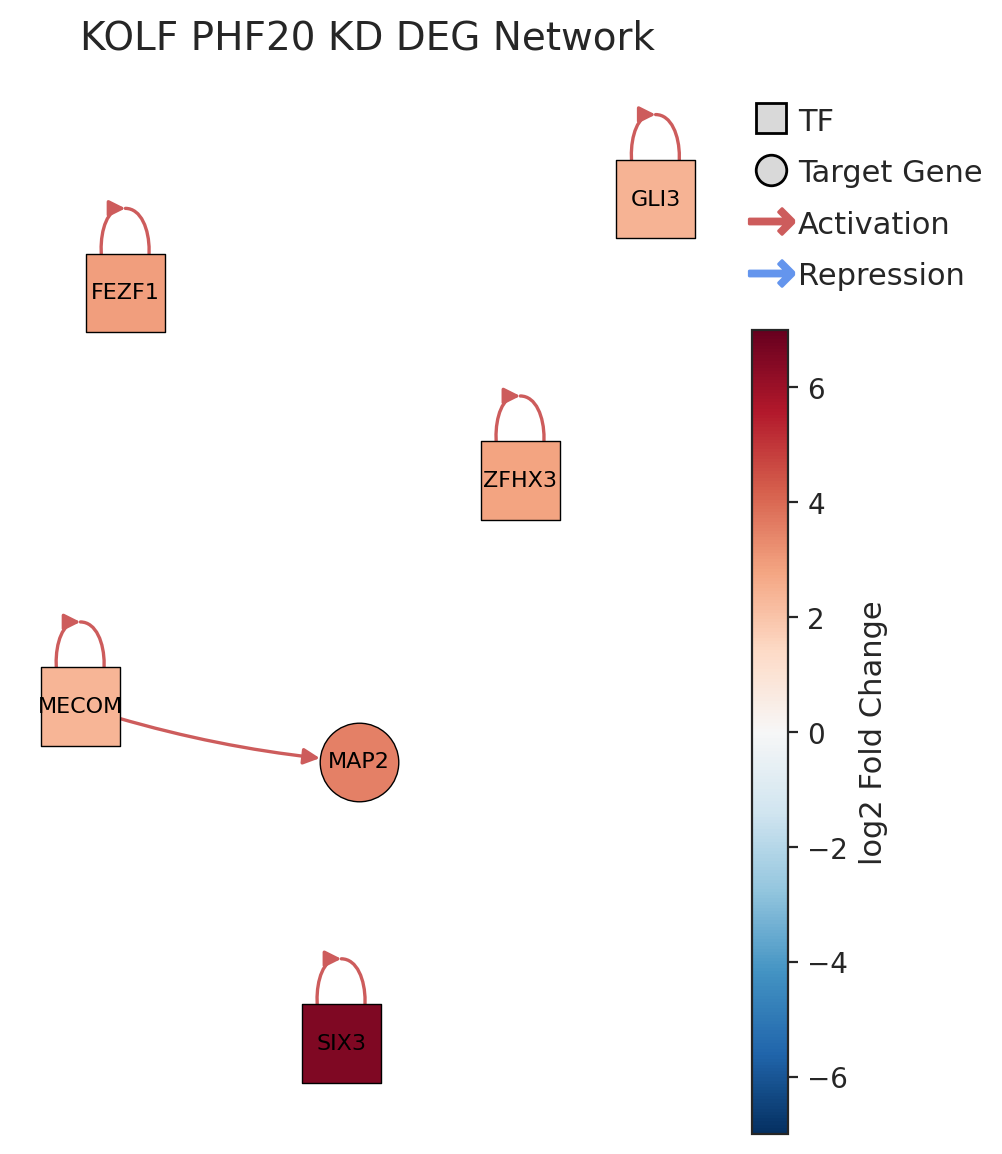

In [29]:
_ = plot_grn("PHF20", lfc_df=kolf_deg_lfcs, grn_df=collectri, tfs=lambert_tfs, genes="connected", figsize=(6,6),
             title="KOLF PHF20 KD DEG Network")

# DNMT1

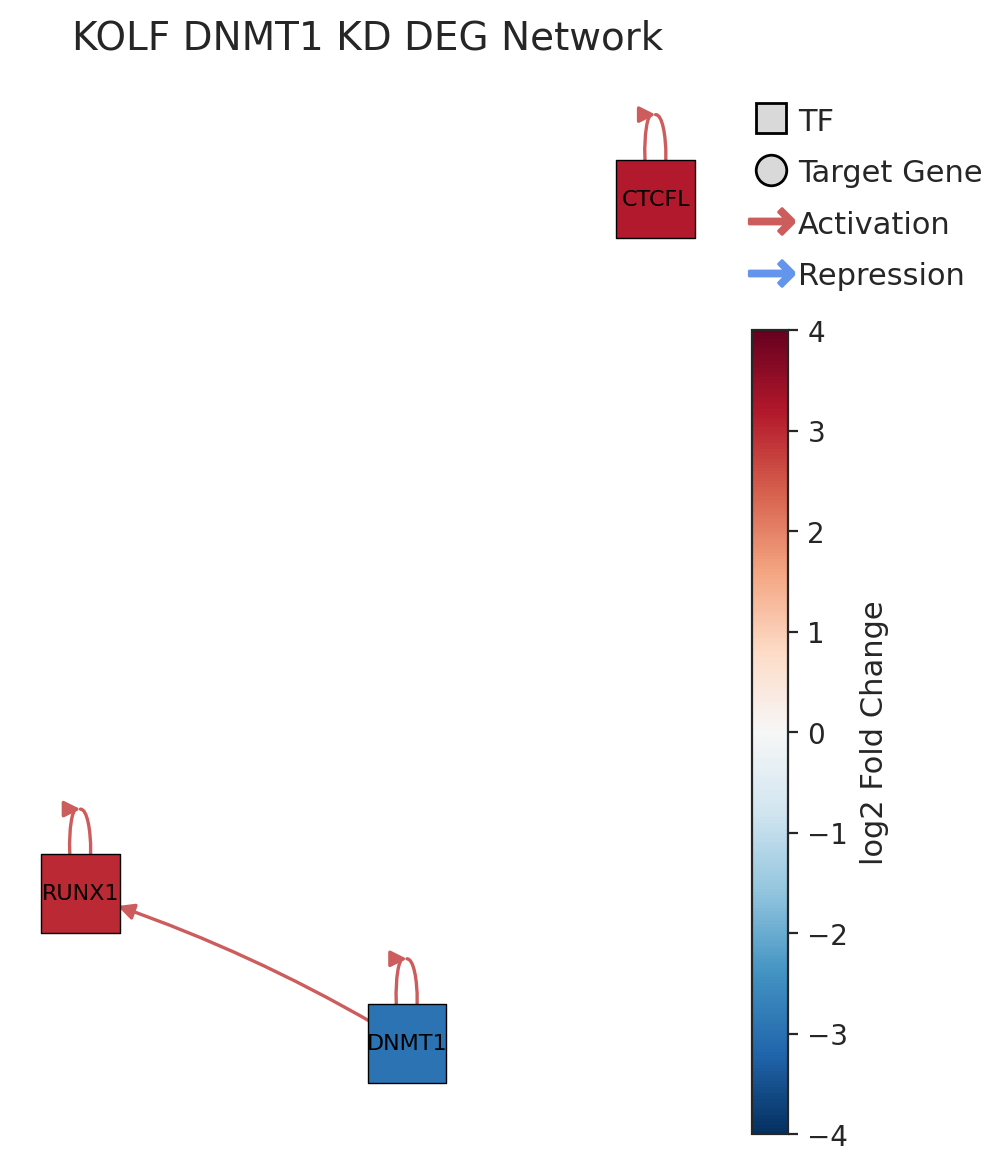

In [27]:
_ = plot_grn("DNMT1", lfc_df=kolf_deg_lfcs, grn_df=collectri, tfs=lambert_tfs, genes="connected", figsize=(6,6),
             title="KOLF DNMT1 KD DEG Network")

In [225]:
dnmt1_degs = ['DAZL', 'PIWIL2', 'RBM46', 'DPPA5', 'ZFP57',  'L3MBTL3', 'CTCFL']

In [133]:
wald_df_kds_kolf.head()

,A1BG,A1BG-AS1,A2M,A2ML1,A2ML1-AS1,A4GALT,AAAS,AACS,AACSP1,AADAT,...,ZW10,ZWILCH,ZWINT,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
ADNP2 KD,0.350846,0.135901,0.899437,1.164939,-0.114536,-0.029241,-0.103019,0.393014,0.751265,0.363970,...,0.073002,0.205148,-0.295775,-0.170168,0.164511,0.007816,0.329013,0.629439,-0.693515,0.626639
ARHGAP35 KD,-0.113876,-1.308458,0.513626,0.572286,0.036179,-0.405953,0.786770,0.213651,0.300971,1.032327,...,-0.344289,0.252292,-0.810143,-0.001644,0.252848,-0.365812,0.435693,0.055317,-0.237702,0.325619
ARID2 KD,-1.244323,0.100271,0.159441,0.487588,-0.098664,-0.356015,0.748316,-0.535548,-0.671359,0.428829,...,0.270857,0.829628,0.244466,-0.110876,0.241746,-0.558204,-0.487843,-0.202280,0.393729,0.381026
ARID3B KD,0.346103,0.781248,-0.761362,-0.159023,-0.083442,-0.114494,0.175094,-0.249381,0.083994,0.732971,...,0.732584,0.055179,0.511896,NaN,0.778878,0.788472,-0.152643,-0.674588,0.787330,-0.826363
ARNT2 KD,0.369225,0.130476,0.613247,0.176436,0.307334,0.674868,0.229567,-1.101298,0.684789,0.670464,...,-0.671867,-0.638468,-0.916288,0.584780,0.876287,-0.130629,-0.634840,-0.298972,0.065137,0.990610


In [135]:
dnmt1_degs_wald = wald_df_kds_kolf.loc[:, wald_df_kds_kolf.columns.isin(dnmt1_degs)]

In [136]:
filepath = "/home/ranwyl/output_files_tf_project/KOLF_DNMT1_KD_degs_interest_wald.csv"
dnmt1_degs_wald.to_csv(filepath)

In [211]:
def build_kd_others_wald_df(
        wald_df: pd.DataFrame,
        kd: str,
        genes: list[str] | set[str]
        ) -> pd.DataFrame:
    """
    Calculate mean Wald of a gene for the given
    KD and for all other KDs.
    """
    if "kd" in wald_df.index[0].lower():
        if not kd.lower().endswith("kd"):
            kd = f"{kd} KD"
    kd_others_df_entries = list()
    for gene in genes:
        kd_wald = wald_df[
            wald_df.index == kd][gene].mean()
        others_wald = wald_df[
            ~(wald_df.index == kd)][gene].mean()
        dataset_wald = wald_df[gene].mean()
        dataset_wald_stdev = wald_df[gene].std()
        kd_zscore = (kd_wald - dataset_wald)/dataset_wald_stdev
        n_others_expressing_gene = wald_df[
            ~(wald_df.index == kd)][gene].count()
        if kd_wald > 0:
            runner_up_wald = wald_df[~(wald_df.index == kd)][gene].max()
        else:
            runner_up_wald = wald_df[~(wald_df.index == kd)][gene].min()
        runner_up_kd = wald_df.index[np.where(wald_df[[gene]] == runner_up_wald)[0]].values[0]
        
        kd_others_df_entries.append({
            "Gene": gene,
            f"Wald in {kd}": kd_wald,
            "Mean Wald in other KDs": others_wald,
            "Dataset mean Wald": dataset_wald,
            f"{kd} z-score": kd_zscore,
            "Runner-up KD": runner_up_kd,
            "Runner-up Wald": runner_up_wald,
            "# other KDs expressing gene": f"{n_others_expressing_gene}/{len(wald_df)-1}"})
    kd_others_wald_df = pd.DataFrame(kd_others_df_entries)
    if round:
        kd_others_wald_df = kd_others_wald_df.round(
            {col: 2 for col in kd_others_wald_df if col not in {"# other KDs expressing gene", "Runner-up KD"}})
    kd_others_wald_df = kd_others_wald_df.sort_values(by=f"Wald in {kd}", ascending=False, key=abs)
    return kd_others_wald_df

In [226]:
build_kd_others_wald_df(wald_df_kds_kolf, "DNMT1", dnmt1_degs)

,Gene,Wald in DNMT1 KD,Mean Wald in other KDs,Dataset mean Wald,DNMT1 KD z-score,Runner-up KD,Runner-up Wald,# other KDs expressing gene
3,DPPA5,5.15,-0.04,-0.01,7.13,ADNP2 KD,1.36,179/179
0,DAZL,4.64,0.21,0.23,6.40,SOX4 KD,1.66,179/179
2,RBM46,3.68,-0.06,-0.04,6.36,ZFP41 KD,1.44,176/179
6,CTCFL,3.47,0.13,0.15,4.12,SETDB1 KD,3.92,179/179
1,PIWIL2,2.70,-0.04,-0.02,5.01,SETDB1 KD,1.84,176/179
4,ZFP57,2.40,-0.10,-0.08,5.70,ZNF551 KD,0.82,150/179
5,L3MBTL3,2.19,0.03,0.04,3.53,THAP12 KD,1.73,178/179


In [ ]:
import scanpy as sc

In [ ]:
adata.obs["batch"] = "ALPHA"

In [ ]:
from scipy import sparse

def replogle_normalize(adata: ad.AnnData,
                        batch_key: str="gem_group",
                        ctrl_key: str="perturbed",
                        ctrl_value: str="False",
                        UMI_count_key: str="UMI_count",
                        counts_layer: str | None = None,
                        save_pre_norm_layer: bool=False,
                        pre_norm_layer: str | None = None,
                        save_norm_layer: bool=True,
                        norm_layer: str="replogle_norm") -> None:
    """
    Normalize to median (core) NTC UMI count and relative z-normalize
    KD cells to NTC cells in the same batch.
    """
    # Save counts
    if save_pre_norm_layer:
        print(f"Saving pre-normalized data to '{pre_norm_layer}' layer")
        if pre_norm_layer in adata.layers:
            print(f"Overwriting existing '{pre_norm_layer}' layer")
        adata.layers[pre_norm_layer] = adata.X.copy()

    # Use counts layer if available, otherwise adata.X
    if counts_layer:
        if counts_layer in adata.layers:
            print(f"Setting .X to '{counts_layer}' layer")
            adata.X = adata.layers[counts_layer].copy()

    # Normalize to median NTC UMI count
    print("Normalizing to median NTC UMI count")
    median_umi_count = adata[adata.obs[ctrl_key] == ctrl_value
                             ].obs[UMI_count_key].median()
    sc.pp.normalize_total(adata, target_sum=median_umi_count)
    
    # Pull out dense X as a numpy array
    X = adata.X
    if sparse.issparse(X):
        X = X.toarray()     # now X is (n_obs, n_vars) numpy
    else:
        X = X.copy()        # be safe if adata.X is a view

    out = np.zeros_like(X)  # final z-normalized pseudobulk

    # For each batch, compute mu/std on controls and fill out
    print("Performing relative z-normalization")
    obs = adata.obs
    for batch in obs[batch_key].unique():
        mask_batch = (obs[batch_key] == batch).values
        mask_ctrl  = mask_batch & (obs[ctrl_key] == ctrl_value).values

        # get control pseudocounts and compute mean/std per gene
        ctrl_mat = X[mask_ctrl]           # shape (#ctrl_cells, n_vars)
        mu  = ctrl_mat.mean(axis=0)       # (n_vars,)
        std = ctrl_mat.std(axis=0)
        # prevent divide-by-zero error temporarily
        zero_std_mask = (std == 0)
        std[zero_std_mask] = 1.0  

        # z-normalize all cells in this batch
        # broadcasting: (n_cells_in_batch, n_vars) - (n_vars,) / (n_vars,)
        out[mask_batch] = (X[mask_batch] - mu) / std
        # set values where std = 0 to NaN
        out[mask_batch][:, zero_std_mask] = np.nan

    # Clip in-place
    np.clip(out, -10, 10, out=out)

    # Write back
    adata.X = out

    # Save to new layer
    if save_norm_layer:
        print(f"Saving normalized data to '{norm_layer}' layer")
        if norm_layer in adata.layers:
            print(f"Overwriting existing '{norm_layer}' layer")
        adata.layers[norm_layer] = adata.X.copy()
        print(f"Normalized data stored in .X and '{norm_layer}' layer")
    else:
        print(f"Normalized data stored in .X")

In [ ]:
replogle_normalize(adata, batch_key="batch", 
                   counts_layer="counts", UMI_count_key="n_UMI_counts",
                   save_norm_layer=True, norm_layer="replogle_norm")

Setting .X to 'counts' layer
Normalizing to median NTC UMI count
normalizing counts per cell
    finished (0:00:00)
Performing relative z-normalization
Saving normalized data to 'replogle_norm' layer
Normalized data stored in .X and 'replogle_norm' layer


In [ ]:
sc.pp.normalize_total(adata, target_sum=1e6)

normalizing counts per cell
    finished (0:00:00)


In [ ]:
def build_ntc_kd_gene_expression_df(adata: ad.AnnData,
                                    genes: list[str] | set[str],
                                    kd: str,
                                    gene_target_col="gene_target",
                                    ntc_label: str="NTC", 
                                    round: bool=True):
    ntc_expr_values, kd_expr_values = [], []
    for gene in genes:
        ntc_expr = adata[adata.obs[gene_target_col] == ntc_label, adata.var.index == gene].X.mean()
        ntc_expr_values.append(ntc_expr)
        kd_expr = adata[adata.obs[gene_target_col] == kd, adata.var.index == gene].X.mean()
        kd_expr_values.append(kd_expr)
    ntc_kd_expr_df = pd.DataFrame({f"NTC expression": ntc_expr_values,
                                   f"{kd} KD expression": kd_expr_values}, 
                                   index=genes)
    if round:
        ntc_kd_expr_df = ntc_kd_expr_df.round(2)
    return ntc_kd_expr_df

In [ ]:
build_ntc_kd_gene_expression_df(adata, ['DAZL', 'PIWIL2', 'RBM46', 'CTCFL', 'DPPA5'], "DNMT1")

,NTC expression,DNMT1 KD expression
DAZL,18.10,111.760002
PIWIL2,1.57,34.060001
RBM46,1.60,56.990002
CTCFL,7.81,60.529999
DPPA5,4.06,149.080002


# REST

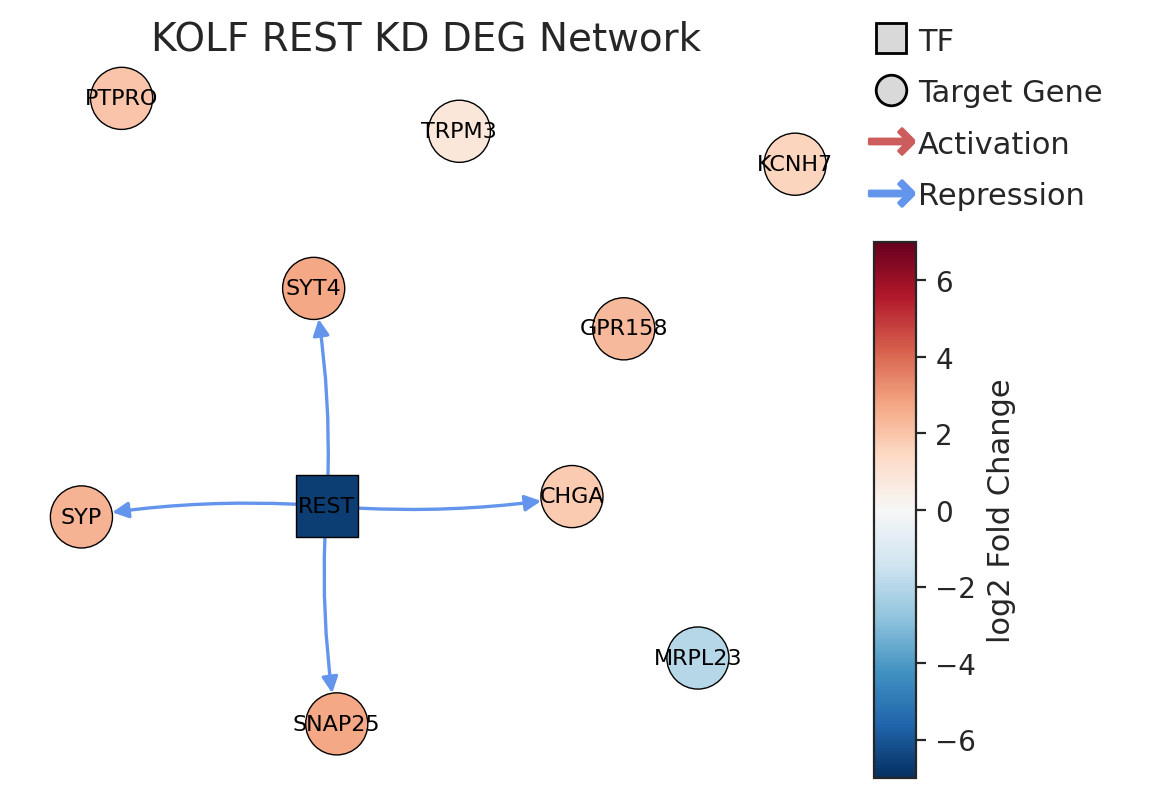

In [47]:
_ = plot_grn("REST", lfc_df=kolf_deg_lfcs, grn_df=collectri, tfs=lambert_tfs, genes="all", figsize=(7,4),
             title="KOLF REST KD DEG Network", node_size=500)

In [41]:
rest_kd_wald_df = wald_df_kds_kolf.loc[["REST KD"]].dropna(axis=1)
rest_kd_tf_acts = tf_acts_df_kds_kolf.loc[["REST KD"]].dropna(axis=1)

In [43]:
rest_kd_tf_acts

,MYC,REST
REST KD,-5.085327,-4.571989


In [42]:
print(f"TFs up: {rest_kd_tf_acts[rest_kd_tf_acts > 0].count().sum()}")
print(f"TFs down: {rest_kd_tf_acts[rest_kd_tf_acts < 0].count().sum()}")

TFs up: 0
TFs down: 2


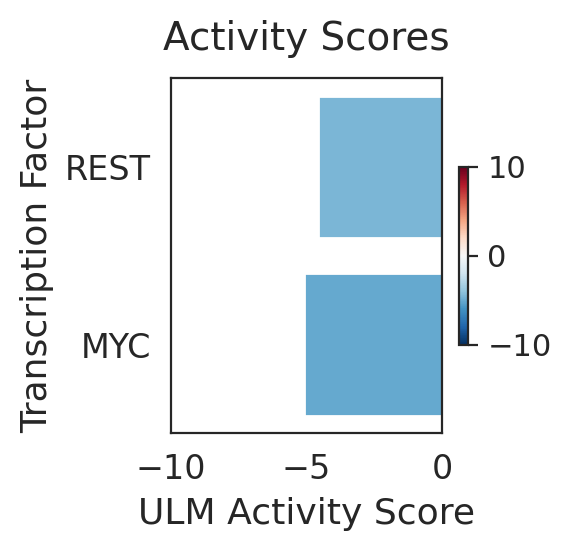

In [45]:
plot_activity_barplot(rest_kd_tf_acts, figsize=(3,3),
                      ylabel="Transcription Factor")

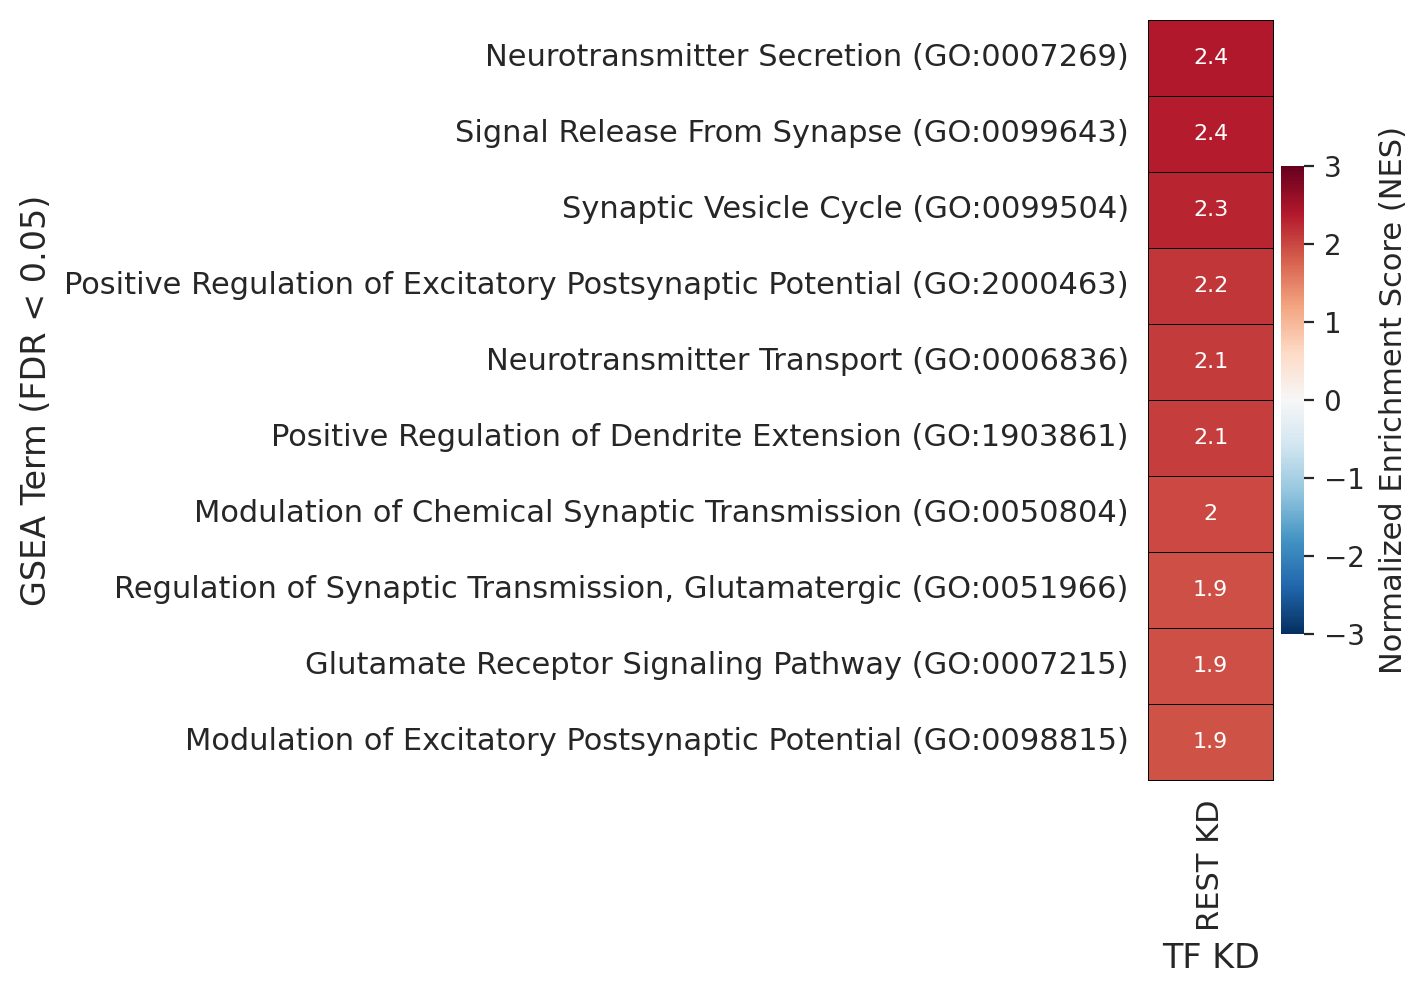

In [26]:
rest_gsea_terms = [
    'Neurotransmitter Secretion (GO:0007269)',
    'Signal Release From Synapse (GO:0099643)',
    'Synaptic Vesicle Cycle (GO:0099504)',
    'Positive Regulation of Excitatory Postsynaptic Potential (GO:2000463)',
    'Neurotransmitter Transport (GO:0006836)',
    'Positive Regulation of Dendrite Extension (GO:1903861)',
    'Modulation of Chemical Synaptic Transmission (GO:0050804)',
    'Regulation of Synaptic Transmission, Glutamatergic (GO:0051966)',
    'Glutamate Receptor Signaling Pathway (GO:0007215)',
    'Modulation of Excitatory Postsynaptic Potential (GO:0098815)']
_ = plot_gsea_heatmap(kolf_gsea_results, kds=['REST'], 
                    sort_columns=False, ylabel="GSEA Term (FDR < 0.05)",
                    terms=rest_gsea_terms, sort_rows=False,
                    kd_col="TF KD", xlabel="TF KD", cbar_size=1,
                    figsize=(1,5), cbar_label="Normalized Enrichment Score (NES)",
                    save_path="/home/ranwyl/figures_tf_project/kolf_rest_kd_gsea.png",
                    save_format="png", dpi=300)

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 7.5 mm


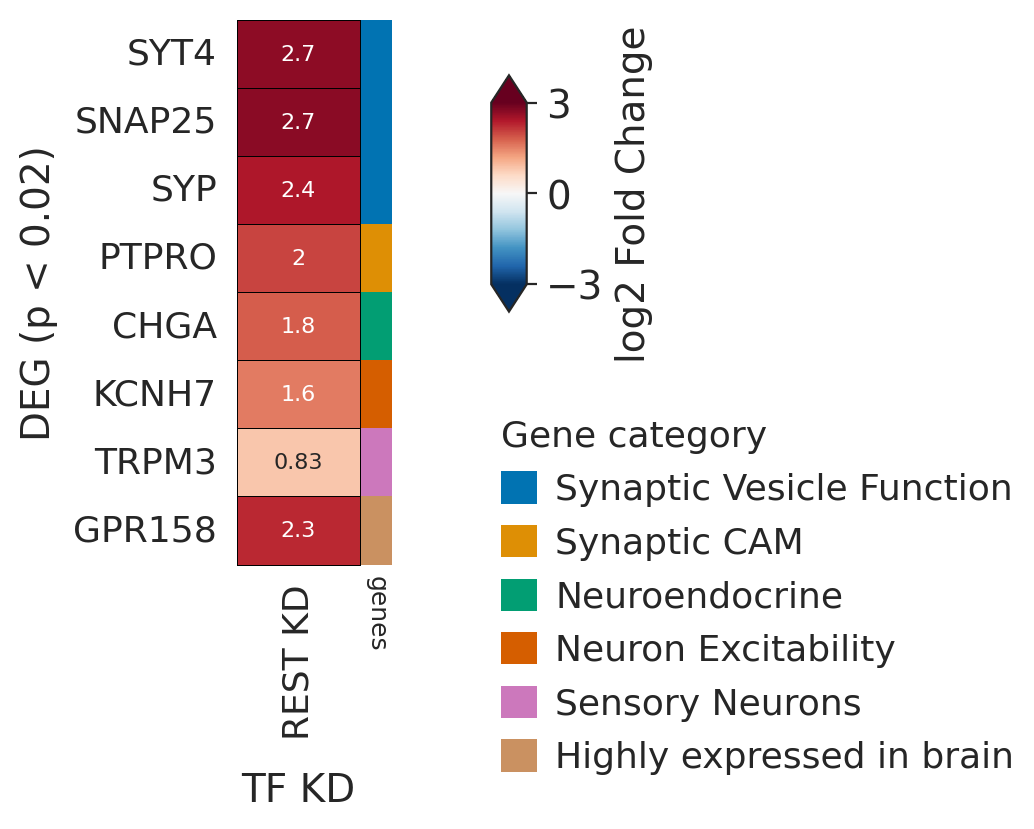

In [53]:
rest_degs = ['SYT4', 'SNAP25', 'SYP', 'PTPRO', 'CHGA', 'KCNH7', 'TRPM3', 'GPR158',]
rest_deg_annots = {'Synaptic Vesicle Function': ['SYT4', 'SNAP25', 'SYP'], 
                    'Synaptic CAM': ['PTPRO'], 'Neuroendocrine': ['CHGA'],
                    'Neuron Excitability': ['KCNH7'], 'Sensory Neurons':['TRPM3'], 
                    'Highly expressed in brain': ['GPR158']}
_ = plot_DEG_LFC_heatmap(kolf_deg_lfcs, kds=['REST'], degs=rest_degs,
                         ylabel="DEG (p < 0.02)", xlabel="TF KD",
                         annotations_for_bars=rest_deg_annots, ylabel_pad=60,
                         annot_legend_position=(2, 0.3), xlabel_pad=70,
                         sort_rows=False, figsize=(1,3),
                         save_path="/home/ranwyl/figures_tf_project/kolf_rest_kd_degs.png"
                         )

In [ ]:
nanog_degs = ['GREB1L', 'MAP2', 'PRTG', 'OTX2', 'GPC3', 'TERF1', 'ESRG']
nanog_deg_annots = {}
_ = plot_DEG_LFC_heatmap(kolf_deg_lfcs, kds=['NANOG'],
                         title="KOLF NANOG KD DEG LFCs", degs=nanog_degs,
                         ylabel="DEG (p < 0.02)", sort_columns=True,
                         sort_rows=False, figsize=(1,3), cbar_size=0.75)

# SETDB1

In [131]:
dnmt1_enriched_up = kolf_gsea_enriched[(kolf_gsea_enriched["TF KD"] == "SETDB1") & (kolf_gsea_enriched["NES"] > 1)]
dnmt1_enriched_up

,Cell line,HDBSCAN cluster,Leiden cluster,TF KD,Gene set,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,# DE lead genes,# lead genes w/ |Wald| > 1,Tag %,Gene %,Lead_genes,DE_lead_genes,Wald_lead_genes
8958,KOLF2.1J,1,10,SETDB1,Reactome_Pathways_2024,Transcriptional Regulation of Granulopoiesis,0.595823,2.093241,0.000166,0.016853,0.0190,1,6,12/38,9.31%,H2AC6;H2BC11;H2BC5;RUNX1;H2BC4;H2BC12;MYC;CDKN...,H2AC6,H2AC6;H2BC11;H2BC12;H2BC4;H2BC5;RUNX1
8959,KOLF2.1J,1,10,SETDB1,Reactome_Pathways_2024,DNA Methylation,0.631777,1.944047,0.000518,0.039165,0.1531,1,5,7/22,9.10%,H2AC6;H2BC11;H2BC5;H2BC4;H2BC12;H2BC15;H2AC7,H2AC6,H2AC6;H2BC11;H2BC12;H2BC4;H2BC5
8960,KOLF2.1J,1,10,SETDB1,Reactome_Pathways_2024,Packaging Of Telomere Ends,0.622339,1.935183,0.000000,0.036199,0.1743,1,5,9/23,13.97%,H2AC6;H2BC11;H2BC5;H2BC4;H2BC12;H2BC15;H2AC7;H...,H2AC6,H2AC6;H2BC11;H2BC12;H2BC4;H2BC5
8961,KOLF2.1J,1,10,SETDB1,Reactome_Pathways_2024,Meiotic Synapsis,0.533746,1.934350,0.000000,0.030379,0.1752,1,6,16/43,17.16%,H2AC6;H2BC11;H2BC5;H2BC4;H2BC12;SMC1A;STAG3;LM...,H2AC6,H2AC6;H2BC11;H2BC12;H2BC4;H2BC5;SMC1A
8962,KOLF2.1J,1,10,SETDB1,Reactome_Pathways_2024,Activated PKN1 Stimulates Transcription of AR ...,0.616864,1.918724,0.000170,0.032328,0.2091,1,5,7/23,9.10%,H2AC6;H2BC11;H2BC5;H2BC4;H2BC12;H2BC15;H2AC7,H2AC6,H2AC6;H2BC11;H2BC12;H2BC4;H2BC5
8963,KOLF2.1J,1,10,SETDB1,Reactome_Pathways_2024,Assembly of the ORC Complex at the Origin of R...,0.582911,1.884570,0.001532,0.043168,0.2947,1,5,5/27,0.30%,H2AC6;H2BC11;H2BC5;H2BC4;H2BC12,H2AC6,H2AC6;H2BC11;H2BC12;H2BC4;H2BC5
8964,KOLF2.1J,1,10,SETDB1,Reactome_Pathways_2024,Formation of the Beta-Catenin TCF Transactivat...,0.507880,1.851739,0.000658,0.046960,0.4043,1,6,17/46,15.69%,H2AC6;H2BC11;H2BC5;H2BC4;H2BC12;TRRAP;MYC;KAT5...,H2AC6,H2AC6;H2BC11;H2BC12;H2BC4;H2BC5;TRRAP
8965,KOLF2.1J,1,10,SETDB1,Reactome_Pathways_2024,Regulation of Endogenous Retroelements by the ...,0.570786,1.838829,0.001511,0.049822,0.4497,1,5,8/26,9.15%,H2AC6;H2BC11;H2BC5;H2BC4;H2BC12;H2BC15;H2AC7;A...,H2AC6,H2AC6;H2BC11;H2BC12;H2BC4;H2BC5
8966,KOLF2.1J,1,10,SETDB1,Reactome_Pathways_2024,ERCC6 (CSB) and EHMT2 (G9a) Positively Regulat...,0.535450,1.836343,0.000840,0.047353,0.4592,1,5,11/34,13.07%,H2AC6;H2BC11;H2BC5;H2BC4;H2BC12;CHD4;H2BC15;H2...,H2AC6,H2AC6;H2BC11;H2BC12;H2BC4;H2BC5
8967,KOLF2.1J,1,10,SETDB1,Reactome_Pathways_2024,Chromatin Modifications During the Maternal to...,0.579210,1.833892,0.002241,0.045247,0.4682,1,5,9/25,13.78%,H2AC6;H2BC11;H2BC5;H2BC4;H2BC12;H2BC15;H2AC7;H...,H2AC6,H2AC6;H2BC11;H2BC12;H2BC4;H2BC5
